# **Módulo 5: Modelo de Clasificación**

Los **modelos de clasificación** son algoritmos de aprendizaje automático que se utilizan para asignar una etiqueta o clase a cada muestra de datos de entrada. En otras palabras, estos modelos predicen categorías discretas o etiquetas de clase. Por ejemplo, en un problema de clasificación binaria, el objetivo puede ser predecir si se le entrega o no una tarjeta de credito. Para la clasificación multiclase, el modelo puede asignar una imagen a una de varias categorías, como perros, gatos o caballos.

## **Tipos de Modelos de Clasificación**

1. **Modelos Lineales**
- Utilizan una combinación lineal de las características para predecir la clase.
- **Ejemplos:**
  - **Regresión Logística**: Utiliza la función sigmoide para modelar la probabilidad de una clase binaria.
  - **Máquinas de Vectores de Soporte (SVM)** con kernel lineal: Encuentra un hiperplano que separa las clases en el espacio de características.

2. **Modelos basados en árboles**
- Construyen un árbol de decisiones donde cada nodo representa una pregunta basada en las características, y las ramas llevan a diferentes decisiones (clases).
- **Ejemplos:**
  - **Árboles de Decisión**: Separan los datos en subgrupos basados en características, de forma jerárquica.
  - **Random Forest**: Combina múltiples árboles de decisión para mejorar la precisión y reducir el sobreajuste.
  - **Gradient Boosting**: Construye árboles secuencialmente, corrigiendo los errores de los modelos anteriores.

3. **Modelos de vecinos cercanos (KNN)**
- Clasifican una muestra basándose en las etiquetas de sus vecinos más cercanos en el espacio de características.
- **K-Nearest Neighbors (KNN)**: Asigna la clase más común entre los 'k' vecinos más cercanos.

4. **Modelos Probabilísticos**
- Utilizan la teoría de probabilidad para predecir la clase más probable dada una muestra de entrada.
- **Ejemplos:**
  - **Naive Bayes**: Asume que las características son independientes entre sí, dado el valor de la clase.
  - **Gaussian Mixture Models (GMM)**: Modela la distribución de datos como una combinación de múltiples distribuciones gaussianas.

5. **Modelos Basados en Ensamble**
- Combinan múltiples modelos para mejorar la precisión de las predicciones.
- **Ejemplos:**
  - **Bagging (Bootstrap Aggregating)**: Ejemplo típico es Random Forest.
  - **Boosting**: Algoritmos como AdaBoost y XGBoost mejoran secuencialmente los errores cometidos por modelos anteriores.

6. **Redes Neuronales**
- Compuestas por capas de neuronas artificiales que transforman las entradas de manera no lineal para clasificar las muestras.
- **Ejemplos:**
  - **Redes Neuronales Artificiales (ANN)**: Pueden ser simples con pocas capas o profundas (Deep Learning) con muchas capas.
  - **Convolutional Neural Networks (CNN)**: Especialmente efectivas para clasificación de imágenes y datos con estructura espacial.
  - **Recurrent Neural Networks (RNN)**: Utilizadas para secuencias de datos, como clasificación de texto.



#### **Modelo de clasificación usando regresión logística de entrega o no de tarjetas de créditos**
<p>Los bancos comerciales reciben <em>muchas</em> solicitudes de tarjetas de crédito.
Muchas de ellas son rechazadas por muchas razones, como saldos de préstamos elevados, bajos niveles de ingresos o demasiadas consultas en el informe crediticio de una persona, por ejemplo. Analizar manualmente estas solicitudes es una tarea rutinaria, propensa a errores y requiere mucho tiempo (¡y el tiempo es dinero!). Por suerte, esta tarea puede automatizarse con el poder del aprendizaje automático y casi todos los bancos comerciales lo hacen hoy en día. En colab, construiremos un predictor automático de aprobación de tarjetas de crédito utilizando técnicas de aprendizaje automático, tal y como hacen los bancos de verdad.</p>

![tarjeta](_image/images.png) 

<p>Utilizaremos el conjunto de datos  <a href="http://archive.ics.uci.edu/ml/datasets/credit+approval">Credit Card Approval</a> del UCI Machine Learning Repository. La estructura de este cuaderno es la siguiente:</p>
<ul>

##### 1. **Importar las librerias**

In [2]:
# Importar 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

##### 2. **Lectura de los datos**

In [3]:
# Cargar el conjunto de datos
path = "_data/dataml/cc_approvals.data"
cc_apps = pd.read_csv(path, header=None)

# Inspeccionar los datos
pd.concat([cc_apps.head(5), cc_apps.tail(5)])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,00260,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,00200,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,00200,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,00280,750,-
689,b,35.00,3.375,u,g,c,h,8.29,f,f,0,t,g,00000,0,-


<p>El resultado puede parecer un poco confuso a primera vista, pero vamos a intentar averiguar las características más importantes de una solicitud de tarjeta de crédito.
Las características de este conjunto de datos se han anonimizado para proteger la privacidad, pero <a href="http://rstudio-pubs-static.s3.amazonaws.com/73039_9946de135c0a49daa7a0a9eda4a67a72.html">este blog</a> nos da una visión general bastante buena de las características probables. Las características probables de una solicitud de tarjeta de crédito típica son <code>Sexo</code>, <code>Edad</code>, <code>Deuda</code>, <code>Casado</code>, <code>Cliente bancario</code>, <code>Nivel educativo</code>, <code>Origen étnico</code>, <code>Años de empleo</code>, <code>Impago anterior</code>, <code>Empleado</code>, <code>Puntuación crediticia</code>, <code>Permiso de conducir</code>, <code>Ciudadano</code>, <code>Código postal</code>, <code>Ingresos</code> y, por último, <code>Estado de aprobación</code>. Esto nos da un punto de partida bastante bueno, y podemos mapear estas características con respecto a las columnas en la salida.   </p>

In [4]:
# nombres de las columnas
cc_apps.columns = ['Sexo', 'Edad', 'Deuda','Casado','ClienteBancario','Educacion',
                   'Etnicidad','AniosEmpleo','DeudaAnterior','Empleado','PuntajeCrediticio',
                   'LicenciaConducir','Ciudadano','CodigoPostal','Ingreso','EstadoAprobado']

cc_apps.head()

,Sexo,Edad,Deuda,Casado,ClienteBancario,Educacion,Etnicidad,AniosEmpleo,DeudaAnterior,Empleado,PuntajeCrediticio,LicenciaConducir,Ciudadano,CodigoPostal,Ingreso,EstadoAprobado
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [5]:
# imprimir información del conjunto de datos
cc_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sexo               690 non-null    object 
 1   Edad               690 non-null    object 
 2   Deuda              690 non-null    float64
 3   Casado             690 non-null    object 
 4   ClienteBancario    690 non-null    object 
 5   Educacion          690 non-null    object 
 6   Etnicidad          690 non-null    object 
 7   AniosEmpleo        690 non-null    float64
 8   DeudaAnterior      690 non-null    object 
 9   Empleado           690 non-null    object 
 10  PuntajeCrediticio  690 non-null    int64  
 11  LicenciaConducir   690 non-null    object 
 12  Ciudadano          690 non-null    object 
 13  CodigoPostal       690 non-null    object 
 14  Ingreso            690 non-null    int64  
 15  EstadoAprobado     690 non-null    object 
dtypes: float64(2), int64(2), o

##### 3. **Datos faltantes o atípicos**

In [6]:
missing_values = cc_apps.isna().sum()
total_rows = cc_apps.shape[0]

missing_vars = missing_values[missing_values > 0]

missing_info_df = pd.DataFrame({
    'Datos faltantes': missing_vars,
    'Porcentaje (%)': round((missing_vars / total_rows) * 100,2)})

missing_info_df

,Datos faltantes,Porcentaje (%)


Debemos tener con la variable `Age`, ya que es una variable numérica y nos muestra en la información que es `object`. Debemos hacer una revisión un poco más minuciosa de las variables

In [18]:
# Inspeccionar los valores en el conjunto de datos
cc_apps.Sex.unique()

array(['b', 'a', '?'], dtype=object)

* Veamos si hay mas interrogantes

In [7]:
# Esto busca textualmente el caracter '?' en cada celda del DataFrame
signos_interrogacion_por_columna = (cc_apps == '?').sum()

print("Cantidad de '?' por columna:")
print(signos_interrogacion_por_columna[signos_interrogacion_por_columna > 0])

Cantidad de '?' por columna:
Sexo               12
Edad               12
Casado              6
ClienteBancario     6
Educacion           9
Etnicidad           9
CodigoPostal       13
dtype: int64


##### **4. ETL, conjunto de entrenamiento y prueba**

Cambiemos los interrogantes por `NAN`s.

In [8]:
# Replazar los '?'s con NaN en los conjuntos de datos
cc_apps_2 = cc_apps.replace('?',np.NaN)

In [9]:
# Datos faltantes
missing_values = cc_apps_2.isna().sum()
total_rows = cc_apps_2.shape[0]

missing_vars = missing_values[missing_values > 0]

missing_info_df = pd.DataFrame({
    'Datos faltantes': missing_vars,
    'Porcentaje (%)': round((missing_vars / total_rows) * 100,2)})

missing_info_df

,Datos faltantes,Porcentaje (%)
Sexo,12,1.74
Edad,12,1.74
Casado,6,0.87
ClienteBancario,6,0.87
Educacion,9,1.30
Etnicidad,9,1.30
CodigoPostal,13,1.88


* <p>Además, variables como <code>Permiso de conducir</code> y <code>Código postal</code> no son tan importantes como las demás características del conjunto de datos para predecir las aprobaciones de tarjetas de crédito.</p>

In [10]:
# Cambiar la variable Age que esta en objeto por float
cc_apps_2['Edad'] = cc_apps_2['Edad'].astype(float)

# Eliminamos las columnas identificadas como irrelevantes o conflictivas
variables_a_eliminar = ['LicenciaConducir', 'CodigoPostal']
cc_apps_filtrado = cc_apps_2.drop(columns=variables_a_eliminar)
cc_apps_filtrado['EstadoAprobado'] = cc_apps_filtrado['EstadoAprobado'].map({'+': 1, '-': 0})

* Veamos el gráfico de barras de la variable objetivo

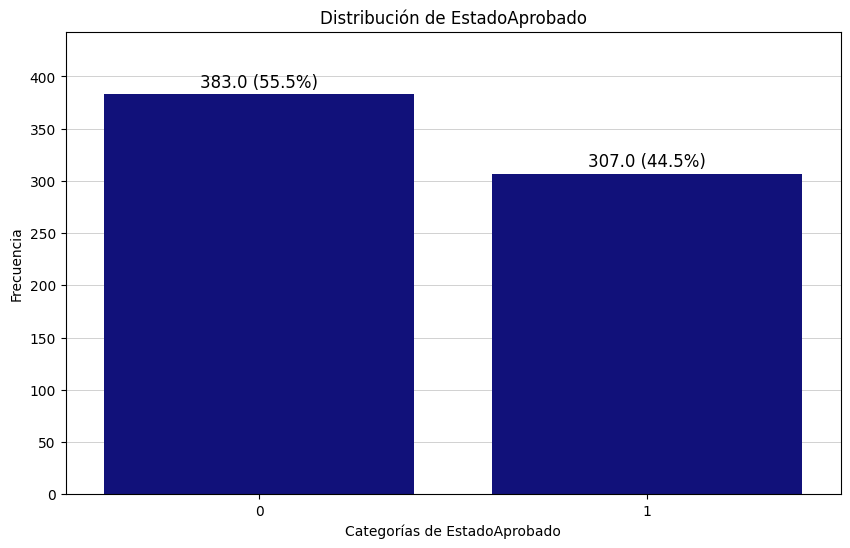

In [13]:
warnings.filterwarnings('ignore')

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='EstadoAprobado', data=cc_apps_filtrado, color='darkblue')

# Grid horizontal gris, detrás de las barras
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(axis='x', visible=False)

total = len(cc_apps_filtrado)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{count} ({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='baseline', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')

ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.title('Distribución de EstadoAprobado')
plt.xlabel('Categorías de EstadoAprobado')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

* Variables numéricas

ANÁLISIS DESCRIPTIVO COMPLETO: EDAD
  • Promedio (Media):       31.57
  • Desviación Estándar:    11.96
  • Mediana (Q2):           28.46
  • Rango Intercuartílico:  15.63  (Q1: 22.6 | Q3: 38.23)
  • Rango Absoluto:         [13.75 - 80.25]
  • Asimetría (Skew):       1.15
  • Curtosis:               1.12
Diagnóstico: Alta distribución sesgada a la derecha. El promedio (31.57) es empujado por outliers por encima de la mediana (28.46).
------------------------------------------------------------


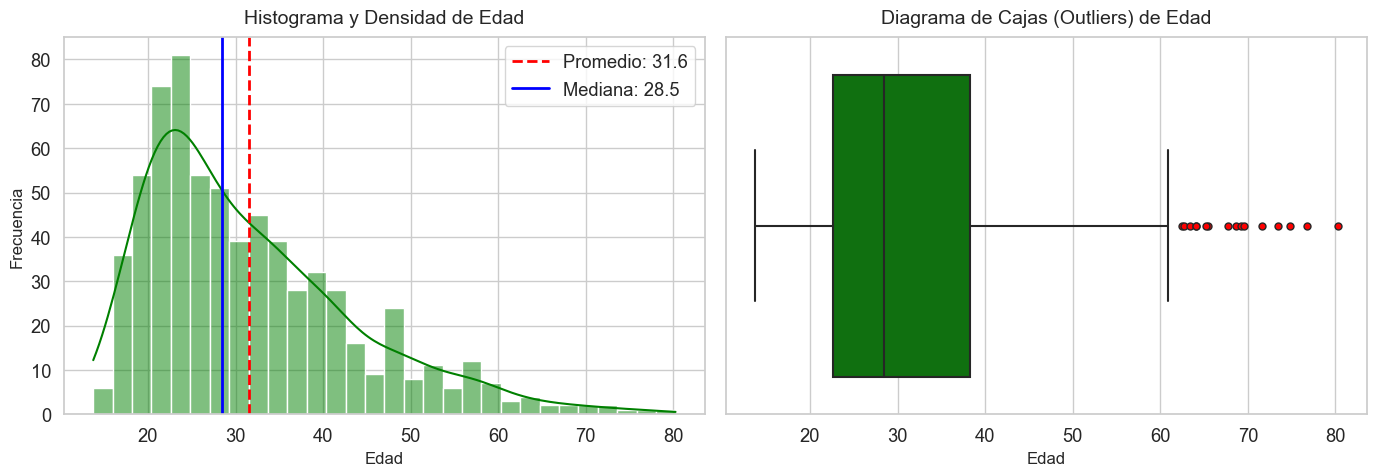

ANÁLISIS DESCRIPTIVO COMPLETO: DEUDA
  • Promedio (Media):       4.76
  • Desviación Estándar:    4.98
  • Mediana (Q2):           2.75
  • Rango Intercuartílico:  6.21  (Q1: 1.0 | Q3: 7.21)
  • Rango Absoluto:         [0.0 - 28.0]
  • Asimetría (Skew):       1.49
  • Curtosis:               2.27
Diagnóstico: Alta distribución sesgada a la derecha. El promedio (4.76) es empujado por outliers por encima de la mediana (2.75).
------------------------------------------------------------


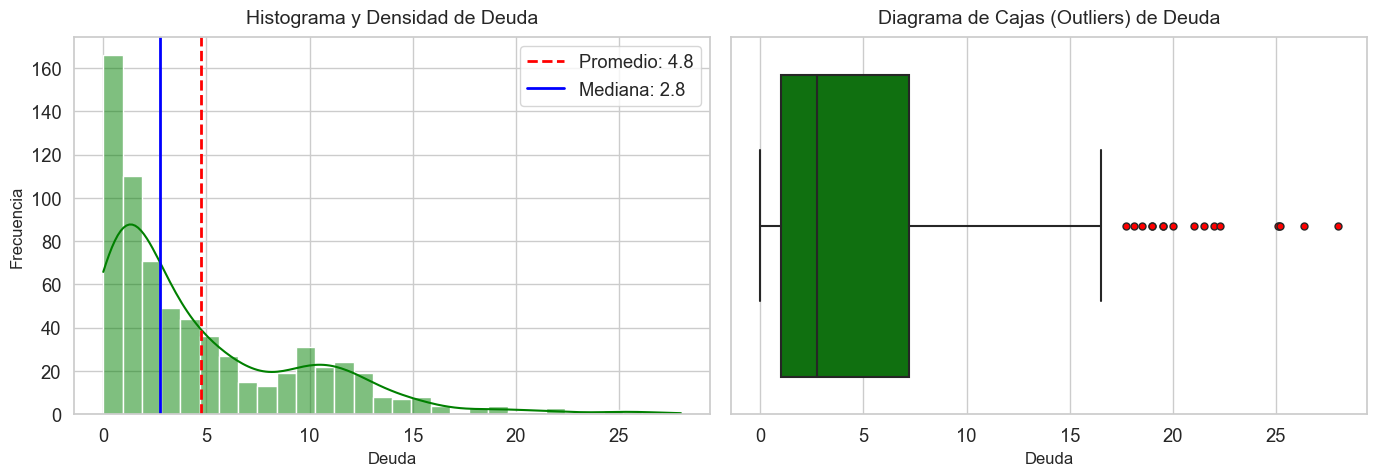

ANÁLISIS DESCRIPTIVO COMPLETO: ANIOSEMPLEO
  • Promedio (Media):       2.22
  • Desviación Estándar:    3.35
  • Mediana (Q2):           1.0
  • Rango Intercuartílico:  2.46  (Q1: 0.16 | Q3: 2.62)
  • Rango Absoluto:         [0.0 - 28.5]
  • Asimetría (Skew):       2.89
  • Curtosis:               11.2
Diagnóstico: Alta distribución sesgada a la derecha. El promedio (2.22) es empujado por outliers por encima de la mediana (1.0).
------------------------------------------------------------


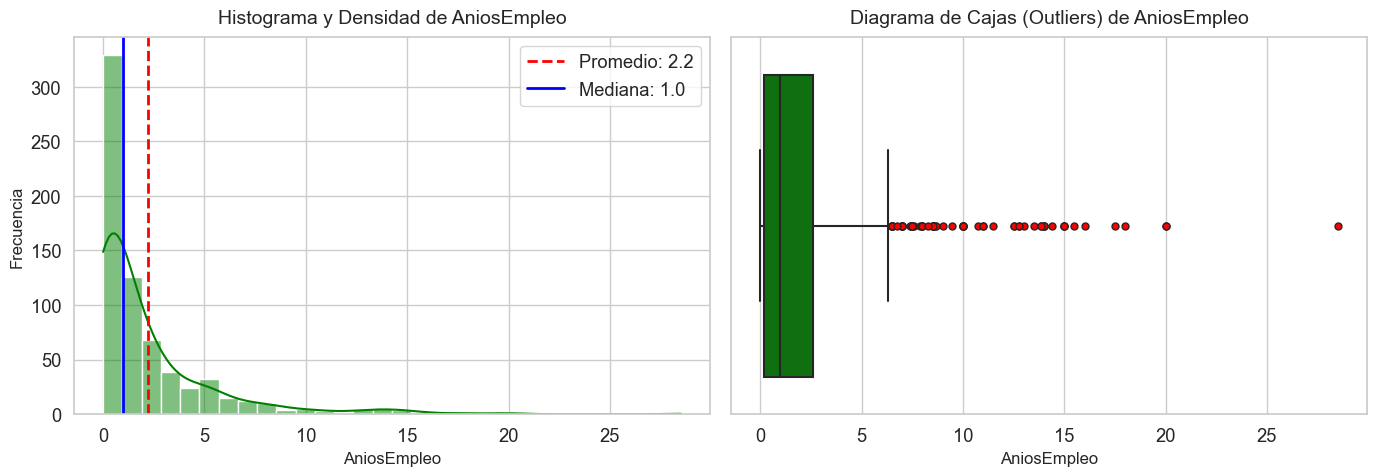

ANÁLISIS DESCRIPTIVO COMPLETO: PUNTAJECREDITICIO
  • Promedio (Media):       2.4
  • Desviación Estándar:    4.86
  • Mediana (Q2):           0.0
  • Rango Intercuartílico:  3.0  (Q1: 0.0 | Q3: 3.0)
  • Rango Absoluto:         [0 - 67]
  • Asimetría (Skew):       5.15
  • Curtosis:               50.83
Diagnóstico: Alta distribución sesgada a la derecha. El promedio (2.4) es empujado por outliers por encima de la mediana (0.0).
------------------------------------------------------------


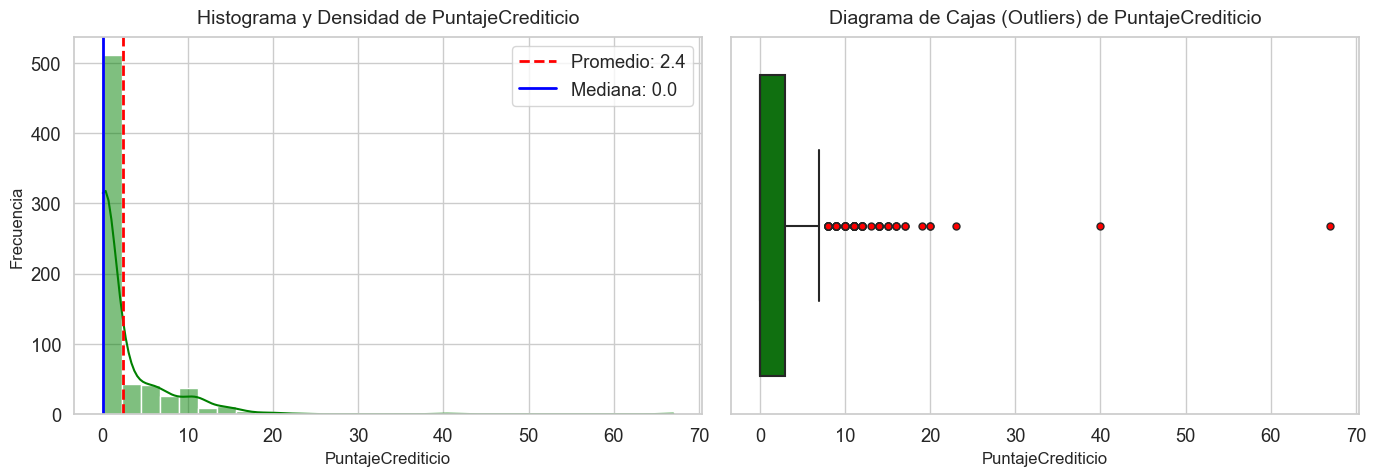

ANÁLISIS DESCRIPTIVO COMPLETO: INGRESO
  • Promedio (Media):       1017.39
  • Desviación Estándar:    5210.1
  • Mediana (Q2):           5.0
  • Rango Intercuartílico:  395.5  (Q1: 0.0 | Q3: 395.5)
  • Rango Absoluto:         [0 - 100000]
  • Asimetría (Skew):       13.14
  • Curtosis:               214.67
Diagnóstico: Alta distribución sesgada a la derecha. El promedio (1017.39) es empujado por outliers por encima de la mediana (5.0).
------------------------------------------------------------


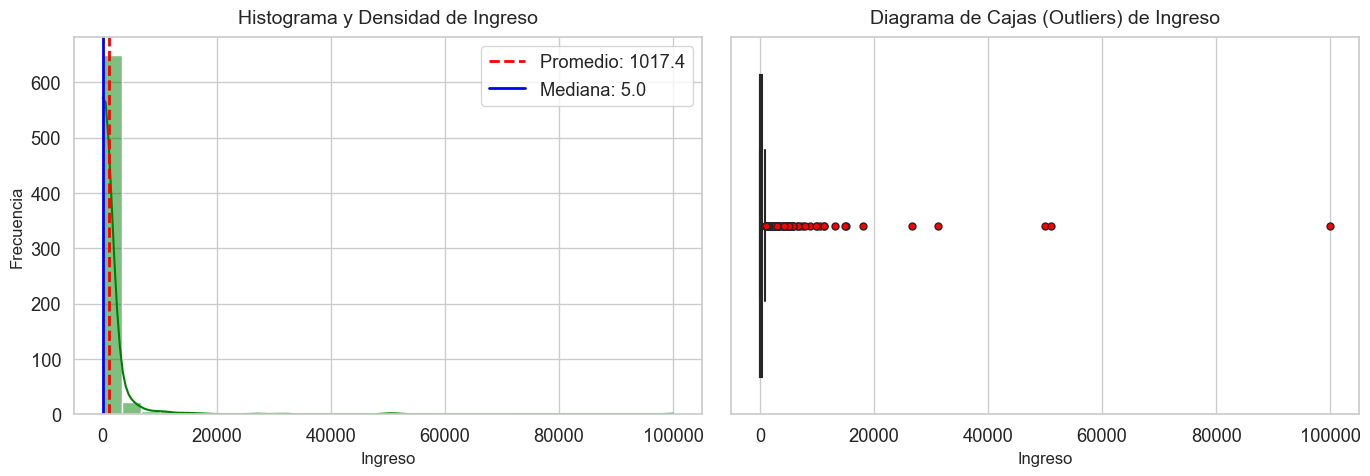

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

# 1. Ignorar advertencias de futuras versiones
warnings.filterwarnings('ignore')

# 2. Asegurar que las variables numéricas tengan el tipo de dato correcto en cc_apps_filtrado
columnas_a_graficar = ['Edad', 'Deuda', 'AniosEmpleo', 'PuntajeCrediticio', 'Ingreso']

for col in columnas_a_graficar:
    cc_apps_filtrado[col] = pd.to_numeric(cc_apps_filtrado[col], errors='coerce')

# 3. Extraer formalmente las columnas numéricas verificadas de cc_apps_filtrado
numerical_columns = cc_apps_filtrado[columnas_a_graficar].select_dtypes(include=[np.number]).columns

# 4. Ajustar el estilo de Seaborn y el color verde para los gráficos
sns.set_theme(style="whitegrid", font_scale=1.2)

# 5. Bucle para generar las métricas descriptivas y los gráficos en paralelo
for column in numerical_columns:
    # --- CÁLCULO DE MÉTRICAS ESTADÍSTICAS ---
    mean_val = cc_apps_filtrado[column].mean()
    std_val = cc_apps_filtrado[column].std()
    median_val = cc_apps_filtrado[column].median()
    min_val = cc_apps_filtrado[column].min()
    max_val = cc_apps_filtrado[column].max()
    
    # Calcular el Rango Intercuartílico (IQR)
    q1 = cc_apps_filtrado[column].quantile(0.25)
    q3 = cc_apps_filtrado[column].quantile(0.75)
    iqr_val = q3 - q1
    
    # Momentos de la distribución
    skewness = cc_apps_filtrado[column].skew()
    kurt = cc_apps_filtrado[column].kurtosis()
    
    # --- REPORTE EN CONSOLA ---
    print("=" * 60)
    print(f"ANÁLISIS DESCRIPTIVO COMPLETO: {column.upper()}")
    print("=" * 60)
    print(f"  • Promedio (Media):       {round(mean_val, 2)}")
    print(f"  • Desviación Estándar:    {round(std_val, 2)}")
    print(f"  • Mediana (Q2):           {round(median_val, 2)}")
    print(f"  • Rango Intercuartílico:  {round(iqr_val, 2)}  (Q1: {round(q1, 2)} | Q3: {round(q3, 2)})")
    print(f"  • Rango Absoluto:         [{round(min_val, 2)} - {round(max_val, 2)}]")
    print(f"  • Asimetría (Skew):       {round(skewness, 2)}")
    print(f"  • Curtosis:               {round(kurt, 2)}")
    
    # Breve diagnóstico analítico basado en las métricas
    if skewness > 1:
        print(f"Diagnóstico: Alta distribución sesgada a la derecha. El promedio ({round(mean_val, 2)}) "
              f"es empujado por outliers por encima de la mediana ({round(median_val, 2)}).")
    print("-" * 60)

    # --- GENERACIÓN DE GRÁFICOS ---
    plt.figure(figsize=(14, 5))
    
    # Subplot 1: Histograma con KDE (curva de densidad)
    plt.subplot(1, 2, 1)
    sns.histplot(cc_apps_filtrado[column], kde=True, color='green', bins=30)
    # Línea vertical para el Promedio (Rojo) y Mediana (Azul)
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Promedio: {round(mean_val, 1)}')
    plt.axvline(median_val, color='blue', linestyle='-', linewidth=2, label=f'Mediana: {round(median_val, 1)}')
    plt.title(f'Histograma y Densidad de {column}', fontsize=14, pad=10)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.legend()
    
    # Subplot 2: Diagrama de cajas (Boxplot)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=cc_apps_filtrado[column], color='green', flierprops={"markerfacecolor": "red", "marker": "o"})
    plt.title(f'Diagrama de Cajas (Outliers) de {column}', fontsize=14, pad=10)
    plt.xlabel(column, fontsize=12)
    
    # Mostrar la figura en pantalla
    plt.tight_layout()
    plt.show()

* Variables categóricas

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): SEXO
      Frecuencia Absoluta  Porcentaje (%)
Sexo                                     
b                     468           69.03
a                     210           30.97
------------------------------------------------------------


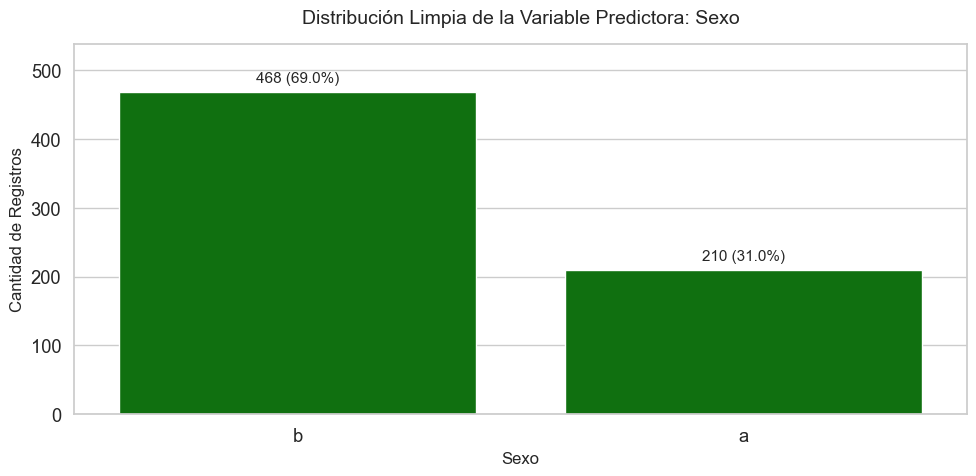

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): CASADO
        Frecuencia Absoluta  Porcentaje (%)
Casado                                     
u                       519           75.88
y                       163           23.83
l                         2            0.29
------------------------------------------------------------


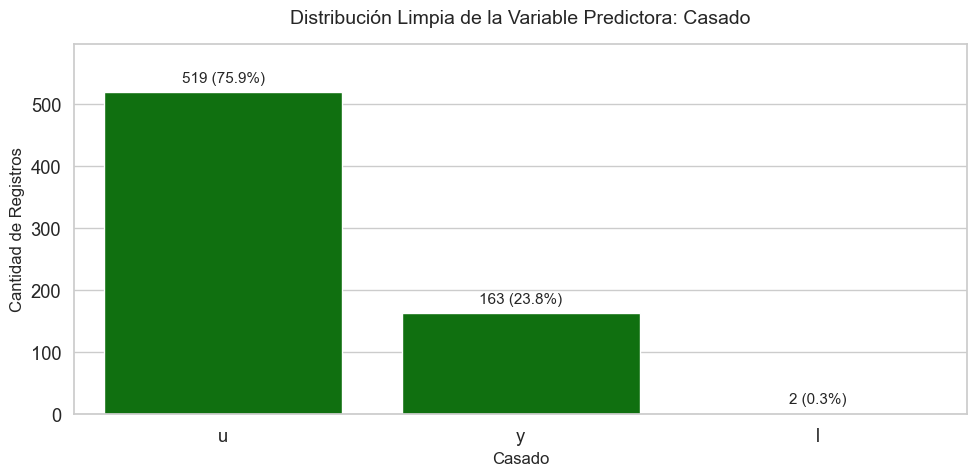

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): CLIENTEBANCARIO
                 Frecuencia Absoluta  Porcentaje (%)
ClienteBancario                                     
g                                519           75.88
p                                163           23.83
gg                                 2            0.29
------------------------------------------------------------


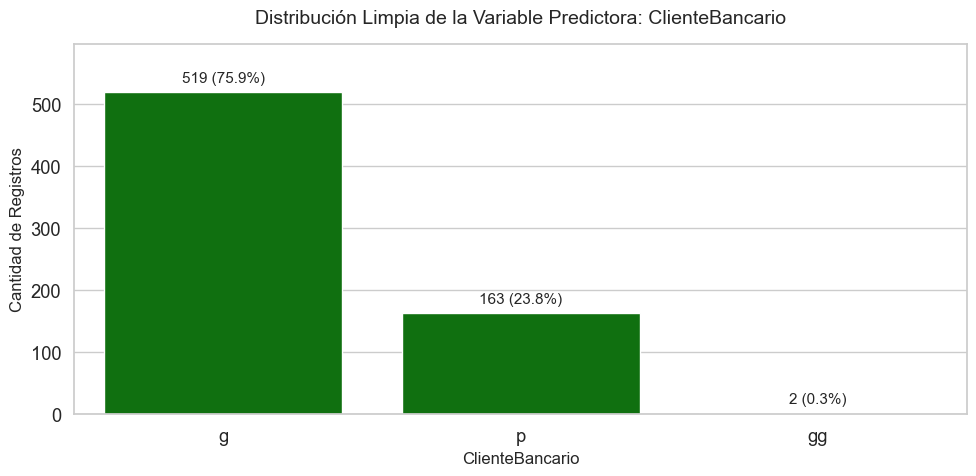

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): EDUCACION
           Frecuencia Absoluta  Porcentaje (%)
Educacion                                     
c                          137           20.12
q                           78           11.45
w                           64            9.40
i                           59            8.66
aa                          54            7.93
ff                          53            7.78
k                           51            7.49
cc                          41            6.02
m                           38            5.58
x                           38            5.58
d                           30            4.41
e                           25            3.67
j                           10            1.47
r                            3            0.44
------------------------------------------------------------


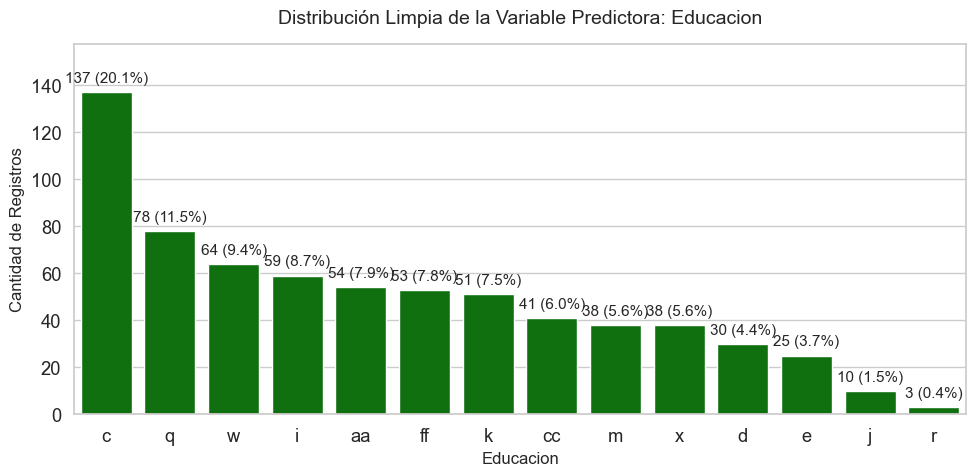

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): ETNICIDAD
           Frecuencia Absoluta  Porcentaje (%)
Etnicidad                                     
v                          399           58.59
h                          138           20.26
bb                          59            8.66
ff                          57            8.37
j                            8            1.17
z                            8            1.17
dd                           6            0.88
n                            4            0.59
o                            2            0.29
------------------------------------------------------------


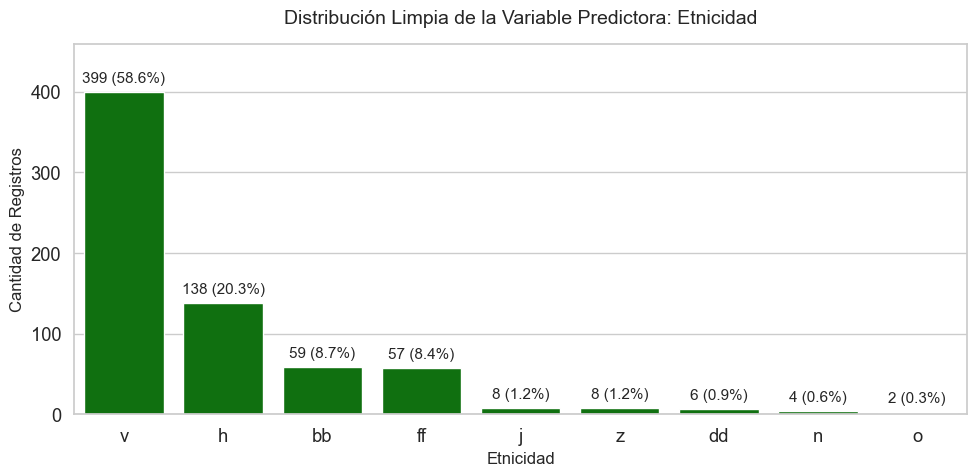

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): DEUDAANTERIOR
               Frecuencia Absoluta  Porcentaje (%)
DeudaAnterior                                     
t                              361           52.32
f                              329           47.68
------------------------------------------------------------


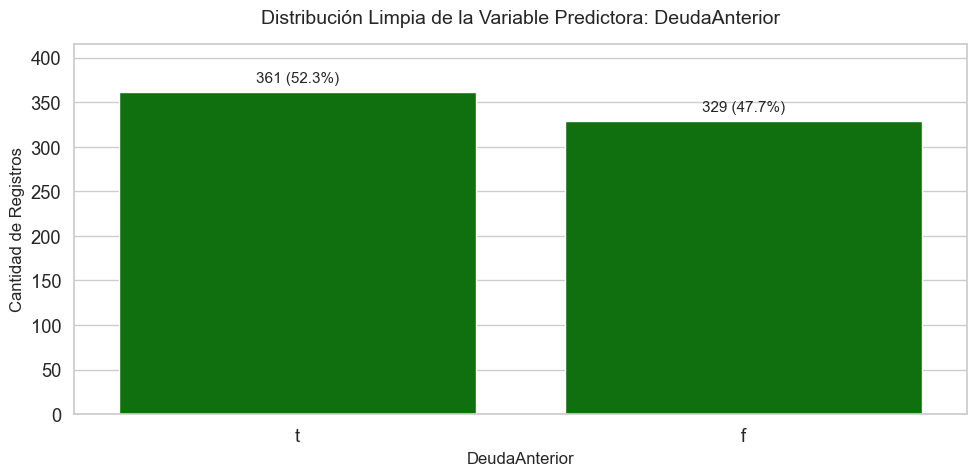

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): EMPLEADO
          Frecuencia Absoluta  Porcentaje (%)
Empleado                                     
f                         395           57.25
t                         295           42.75
------------------------------------------------------------


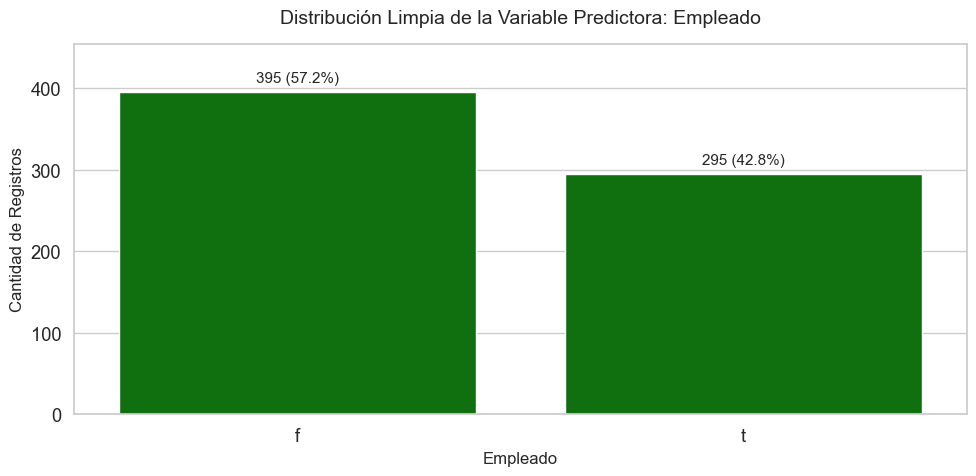

 VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): CIUDADANO
           Frecuencia Absoluta  Porcentaje (%)
Ciudadano                                     
g                          625           90.58
s                           57            8.26
p                            8            1.16
------------------------------------------------------------


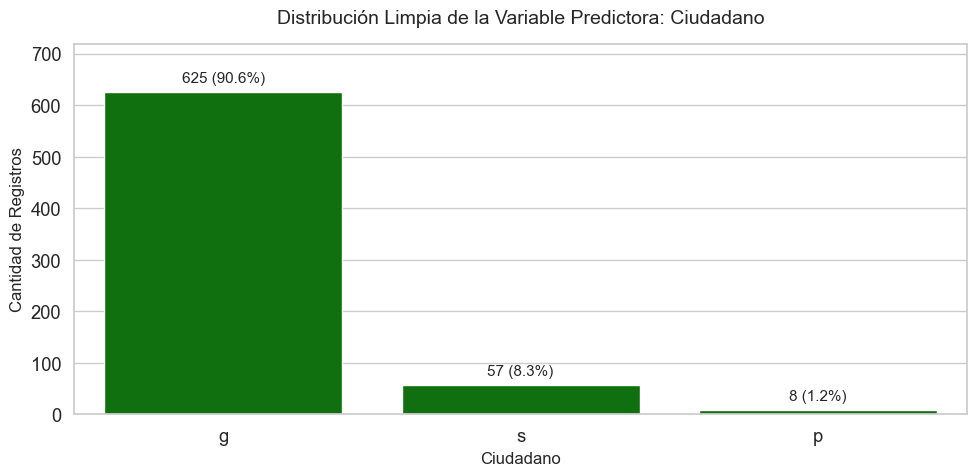

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

# 1. Ignorar advertencias de futuras versiones
warnings.filterwarnings('ignore')

# 2. Identificar automáticamente las columnas categóricas en cc_apps_filtrado
col_categoricas_todas = cc_apps_filtrado.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Filtrado explícito: Nos quedamos estrictamente con las variables independientes
variables_independientes_cat = [col for col in col_categoricas_todas if col != 'EstadoAprobado']

# 4. Ajustar el estilo de Seaborn y configurar la escala de la fuente
sns.set_theme(style="whitegrid", font_scale=1.2)

# 5. Bucle para generar las tablas y gráficos sin NaNs
for column in variables_independientes_cat:
    
    # --- FILTRADO DE DATOS (Eliminar filas con NaN en la columna actual para este análisis) ---
    df_sin_na = cc_apps_filtrado[[column]].dropna()
    
    # Si por alguna razón la columna queda vacía, saltamos a la siguiente
    if df_sin_na.empty:
        continue
        
    # --- CÁLCULO DE FRECUENCIAS (Con dropna=True explícito) ---
    conteo_absoluto = df_sin_na[column].value_counts(dropna=True)
    conteo_relativo = df_sin_na[column].value_counts(normalize=True, dropna=True) * 100
    
    # Construcción de la tabla de frecuencias descriptiva limpia
    reporte_frecuencias = pd.DataFrame({
        'Frecuencia Absoluta': conteo_absoluto,
        'Porcentaje (%)': conteo_relativo.round(2)
    })
    
    print("=" * 60)
    print(f" VARIABLE INDEPENDIENTE CATEGÓRICA (SIN NULOS): {column.upper()}")
    print("=" * 60)
    print(reporte_frecuencias)
    print("-" * 60)
    
    # --- GENERACIÓN DEL DIAGRAMA DE BARRAS LIMPIO ---
    plt.figure(figsize=(10, 5))
    
    # Graficamos usando el set de datos filtrado y ordenado de mayor a menor frecuencia
    ax = sns.countplot(
        data=df_sin_na, 
        x=column, 
        color='green', 
        order=conteo_absoluto.index
    )
    
    # Añadir las etiquetas numéricas y porcentajes arriba de cada barra sin contar los NaNs en el total
    total_filas_limpias = len(df_sin_na)
    for p in ax.patches:
        altura = p.get_height()
        if not np.isnan(altura) and altura > 0: 
            porcentaje = f'{round((altura / total_filas_limpias) * 100, 1)}%'
            ax.annotate(
                f'{int(altura)} ({porcentaje})', 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', 
                va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=11
            )
            
    plt.title(f'Distribución Limpia de la Variable Predictora: {column}', fontsize=14, pad=15)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Cantidad de Registros', fontsize=12)
    
    # Holgura en el eje Y para evitar cortes
    plt.ylim(0, conteo_absoluto.max() * 1.15) 
    
    # Desplegar gráfico
    plt.tight_layout()
    plt.show()

* Agrupemos categórias con sentido para que mejoren las variables

In [23]:
# Agrupamos la categoría ultra-minoritaria 'l' dentro de 'y'
cc_apps_2['Casado'] = cc_apps_2['Casado'].replace('l', 'y')

# Agrupamos la categoría clientebancario 'gg' dentro de 'p'
cc_apps_2['ClienteBancario'] = cc_apps_2['ClienteBancario'].replace('gg', 'p')

# Agrupamos la categoría educacion 'j' dentro de 'r'
cc_apps_2['Educacion'] = cc_apps_2['Educacion'].replace('r', 'j')

# Agrupamos la categoría etnicidad 'o' dentro de 'n'
cc_apps_2['Etnicidad'] = cc_apps_2['Etnicidad'].replace('o', 'n')

# Eliminamos las columnas identificadas como irrelevantes o conflictivas
variables_a_eliminar = ['LicenciaConducir', 'CodigoPostal']
cc_apps_filtrado = cc_apps_2.drop(columns=variables_a_eliminar)

* Separemos las variables independientes de la variable objetivo

In [24]:
# Separamos características independientes (X) y variable objetivo (y) de la data completa
X_completo = cc_apps_filtrado.drop(columns=['EstadoAprobado'])
y_completo = cc_apps_filtrado['EstadoAprobado']

* <p> Vamos a imputar los valores perdidos con una estrategia llamada imputación interactiva.</p>

In [25]:
from sklearn.impute import SimpleImputer
# Habilitamos e importamos el imputador iterativo (MICE)
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

# Identificamos las columnas numéricas y categóricas remanentes
col_numericas = X_completo.select_dtypes(include=[np.number]).columns.tolist()
col_categoricas = X_completo.select_dtypes(include=['object', 'category']).columns.tolist()

# Clonamos el dataset para no sobreescribir destructivamente el original
X_imp = X_completo.copy()

# A. Imputación Iterativa (MICE) para variables numéricas (Ajuste y transformación global)
iterative_imp = IterativeImputer(random_state=42, max_iter=10)
X_imp[col_numericas] = iterative_imp.fit_transform(X_completo[col_numericas])

# B. Imputación por Moda para variables categóricas (Ajuste y transformación global)
categorical_imp = SimpleImputer(strategy='most_frequent')
if len(col_categoricas) > 0:
    X_imp[col_categoricas] = categorical_imp.fit_transform(X_completo[col_categoricas])

print("--- CONTROL DE CALIDAD (NULOS RESTANTES) ---")
print(f"Valores nulos en todo el conjunto X después de imputar: {X_imp.isnull().sum().sum()}\n")

--- CONTROL DE CALIDAD (NULOS RESTANTES) ---
Valores nulos en todo el conjunto X después de imputar: 0



* Vamos a dicotomizar las variables categóricas

In [26]:
from sklearn.preprocessing import OneHotEncoder

if len(col_categoricas) > 0:
    # Usamos drop='first' para evitar la trampa de la variable ficticia en modelos lineales/VIF
    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    
    # Ajustamos y transformamos sobre toda la data
    X_cat_encoded = encoder.fit_transform(X_imp[col_categoricas])
    nombres_cat = encoder.get_feature_names_out(col_categoricas)
    X_cat_df = pd.DataFrame(X_cat_encoded, columns=nombres_cat, index=X_imp.index)
    
    # Unificamos numéricas imputadas con categóricas codificadas
    X_unificado_vif = pd.concat([X_imp[col_numericas], X_cat_df], axis=1)
else:
    X_unificado_vif = X_imp[col_numericas].copy()

* Miremos el factor de inflacion de la varianza

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_unificado_vif.copy()
X_vif['intercept'] = 1  # statsmodels requiere una constante para calcular el VIF de manera correcta

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Filtramos la columna 'intercept' y ordenamos los resultados de mayor a menor multicolinealidad
vif_data = vif_data[vif_data["Variable"] != 'intercept'].sort_values(by="VIF", ascending=False)

print("=== REPORTE DE MULTICOLINEALIDAD GLOBAL (VIF) ===")
print(vif_data.to_string(index=False))

=== REPORTE DE MULTICOLINEALIDAD GLOBAL (VIF) ===
         Variable       VIF
         Casado_y       inf
ClienteBancario_p       inf
     Etnicidad_ff 13.476632
     Educacion_ff 13.115553
      Etnicidad_v  4.615301
      Etnicidad_h  3.533706
      Educacion_c  3.104150
      Educacion_e  2.764233
      Educacion_j  2.743179
      Etnicidad_j  2.401384
      Educacion_i  2.388678
      Educacion_q  2.334905
      Educacion_w  2.049221
      Etnicidad_z  1.922826
      Educacion_k  1.892390
       Empleado_t  1.822978
     Educacion_cc  1.788699
      Educacion_m  1.760140
      Educacion_x  1.751843
PuntajeCrediticio  1.697117
     Etnicidad_dd  1.686168
  DeudaAnterior_t  1.568111
      Educacion_d  1.547847
      AniosEmpleo  1.481476
             Edad  1.403676
      Etnicidad_n  1.400248
          Ingreso  1.312196
            Deuda  1.249458
           Sexo_b  1.168064
      Ciudadano_s  1.163866
      Ciudadano_p  1.156594


* Aquí esta el codigo completo, eliminando cliente bancario y etnia

In [28]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
# Obligatorio para poder usar IterativeImputer
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. CARGA DE DATOS Y ASIGNACIÓN DE COLUMNAS
filename = "C:\\Documentos\\Books_CienciaDatos\\DSTripleA\\docs\\_data\\dataml\\cc_approvals.data"
cc_apps = pd.read_csv(filename, header=None)

cc_apps.columns = ['Sexo', 'Edad', 'Deuda', 'Casado', 'ClienteBancario', 'Educacion',
                   'Etnicidad', 'AniosEmpleo', 'DeudaAnterior', 'Empleado', 'PuntajeCrediticio',
                   'LicenciaConducir', 'Ciudadano', 'CodigoPostal', 'Ingreso', 'EstadoAprobado']

# Reemplazar los '?'s con NaN en los conjuntos de datos
cc_apps_2 = cc_apps.replace('?', np.NaN)

# Cambiar la variable Edad que está en objeto por float
cc_apps_2['Edad'] = cc_apps_2['Edad'].astype(float)

# =====================================================================
# INGENIERÍA DE CARACTERÍSTICAS: TUS AGRUPACIONES DE CATEGORÍAS
# =====================================================================
# Agrupamos la categoría ultra-minoritaria 'l' dentro de 'y'
cc_apps_2['Casado'] = cc_apps_2['Casado'].replace('l', 'y')

# Agrupamos la categoría clientebancario 'gg' dentro de 'p'
cc_apps_2['ClienteBancario'] = cc_apps_2['ClienteBancario'].replace('gg', 'p')

# Agrupamos la categoría educacion 'j' dentro de 'r' (Corregido el orden del replace si 'r' era minoritaria)
cc_apps_2['Educacion'] = cc_apps_2['Educacion'].replace('r', 'j')

# Agrupamos la categoría etnicidad 'o' dentro de 'n'
cc_apps_2['Etnicidad'] = cc_apps_2['Etnicidad'].replace('o', 'n')

# =====================================================================
# SELECCIÓN DEFINITIVA DE CARACTERÍSTICAS (ELIMINANDO MULTICOLINEALIDAD)
# =====================================================================
# Aunque agrupamos arriba, DEBEMOS eliminar ClienteBancario y Etnicidad.
# Su información ya quedó perfectamente representada en Casado y Educacion.
variables_a_eliminar = ['LicenciaConducir', 'CodigoPostal', 'ClienteBancario', 'Etnicidad']
cc_apps_filtrado = cc_apps_2.drop(columns=variables_a_eliminar)

# Mapear la variable objetivo a binario
cc_apps_filtrado['EstadoAprobado'] = cc_apps_filtrado['EstadoAprobado'].map({'+': 1, '-': 0})

# Separamos características independientes (X) y variable objetivo (y)
X_completo = cc_apps_filtrado.drop(columns=['EstadoAprobado'])
y_completo = cc_apps_filtrado['EstadoAprobado']

# Identificamos las columnas numéricas y categóricas remanentes
col_numericas = X_completo.select_dtypes(include=[np.number]).columns.tolist()
col_categoricas = X_completo.select_dtypes(include=['object', 'category']).columns.tolist()

# Clonamos el dataset para la imputación
X_imp = X_completo.copy()

# A. Imputación Iterativa (MICE) para variables numéricas 
iterative_imp = IterativeImputer(random_state=42, max_iter=10)
X_imp[col_numericas] = iterative_imp.fit_transform(X_completo[col_numericas])

# B. Imputación por Moda para variables categóricas 
categorical_imp = SimpleImputer(strategy='most_frequent')
if len(col_categoricas) > 0:
    X_imp[col_categoricas] = categorical_imp.fit_transform(X_completo[col_categoricas])

print("--- CONTROL DE CALIDAD (NULOS RESTANTES) ---")
print(f"Valores nulos en todo el conjunto X después de imputar: {X_imp.isnull().sum().sum()}\n")

# CODIFICACIÓN DUMMY (ONE-HOT ENCODING)
if len(col_categoricas) > 0:
    # Usamos drop='first' para evitar la trampa de la variable ficticia
    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    
    # Ajustamos y transformamos sobre toda la data
    X_cat_encoded = encoder.fit_transform(X_imp[col_categoricas])
    nombres_cat = encoder.get_feature_names_out(col_categoricas)
    X_cat_df = pd.DataFrame(X_cat_encoded, columns=nombres_cat, index=X_imp.index)
    
    # Unificamos numéricas imputadas con categóricas codificadas
    X_unificado_vif = pd.concat([X_imp[col_numericas], X_cat_df], axis=1)
else:
    X_unificado_vif = X_imp[col_numericas].copy()

# CÁLCULO DEL VIF DEFINITIVO
X_vif = X_unificado_vif.copy()
X_vif['intercept'] = 1  # statsmodels requiere una constante para calcular el VIF correctamente

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Filtrar el intercepto y ordenar los resultados de mayor a menor multicolinealidad
vif_data = vif_data[vif_data["Variable"] != 'intercept'].sort_values(by="VIF", ascending=False)

print("=== REPORTE DE MULTICOLINEALIDAD GLOBAL (VIF) ===")
print(vif_data.to_string(index=False))

--- CONTROL DE CALIDAD (NULOS RESTANTES) ---
Valores nulos en todo el conjunto X después de imputar: 0

=== REPORTE DE MULTICOLINEALIDAD GLOBAL (VIF) ===
         Variable      VIF
      Educacion_c 3.046338
      Educacion_q 2.254245
      Educacion_w 2.043203
     Educacion_ff 2.011248
      Educacion_i 1.971505
      Educacion_k 1.846553
       Empleado_t 1.819992
      Educacion_m 1.757788
     Educacion_cc 1.718007
PuntajeCrediticio 1.691560
      Educacion_x 1.656180
      Educacion_d 1.535140
  DeudaAnterior_t 1.532605
      Educacion_e 1.481861
      AniosEmpleo 1.444609
             Edad 1.352561
      Educacion_j 1.240894
            Deuda 1.230173
      Ciudadano_s 1.149077
           Sexo_b 1.145376
      Ciudadano_p 1.141602
          Ingreso 1.120583
         Casado_y 1.089369


### 5. **Preprocesamiento completo de los datos**

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# =========================================================================
# 1. CARGA DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
# =========================================================================
filename = "C:\\Documentos\\Books_CienciaDatos\\DSTripleA\\docs\\_data\\dataml\\cc_approvals.data"
cc_apps = pd.read_csv(filename, header=None)

cc_apps.columns = ['Sexo', 'Edad', 'Deuda', 'Casado', 'ClienteBancario', 'Educacion',
                   'Etnicidad', 'AniosEmpleo', 'DeudaAnterior', 'Empleado', 'PuntajeCrediticio',
                   'LicenciaConducir', 'Ciudadano', 'CodigoPostal', 'Ingreso', 'EstadoAprobado']

# Reemplazar los '?'s con NaN en los conjuntos de datos
cc_apps_2 = cc_apps.replace('?', np.NaN)

# Cambiar la variable Edad que está en objeto por float
cc_apps_2['Edad'] = cc_apps_2['Edad'].astype(float)

# --- TUS AGRUPACIONES DE INGENIERÍA DE CARACTERÍSTICAS ---
# Agrupamos categorías marginales para dar estabilidad estadística al modelo
cc_apps_2['Casado']          = cc_apps_2['Casado'].replace('l', 'y')
cc_apps_2['ClienteBancario'] = cc_apps_2['ClienteBancario'].replace('gg', 'p')
cc_apps_2['Educacion']       = cc_apps_2['Educacion'].replace('r', 'j')
cc_apps_2['Etnicidad']       = cc_apps_2['Etnicidad'].replace('o', 'n')

# --- SELECCIÓN DE CARACTERÍSTICAS (Basada en el éxito del VIF) ---
# Removemos las variables irrelevantes y las redundantes que causaban multicolinealidad
variables_a_eliminar = ['LicenciaConducir', 'CodigoPostal', 'ClienteBancario', 'Etnicidad']
cc_apps_filtrado = cc_apps_2.drop(columns=variables_a_eliminar)

# Convertimos el target 'EstadoAprobado' en una variable binaria (1 = Aprobado, 0 = Rechazado)
cc_apps_filtrado['EstadoAprobado'] = cc_apps_filtrado['EstadoAprobado'].map({'+': 1, '-': 0})

# Separamos características independientes (X) y variable objetivo (y)
X = cc_apps_filtrado.drop(columns=['EstadoAprobado'])
y = cc_apps_filtrado['EstadoAprobado']

# =========================================================================
# PASO 2: SEPARACIÓN EN ENTRENAMIENTO Y TEST (Train/Test Split)
# =========================================================================
# Hacemos la división antes de imputar o escalar para blindarnos del Data Leakage.
# Usamos 'stratify=y' porque es un problema de clasificación y queremos mantener la proporción del target.
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Características predictoras puras y optimizadas
    y,                  # Variable objetivo (Aprobación 1/0)
    test_size=0.2,      # Proporción del 20% reservada para validar el modelo final
    shuffle=True,       # Mezcla los datos aleatoriamente antes de dividir
    stratify=y,         # Crucial: Mantiene la proporción de aprobados/rechazados en train y test
    random_state=42     # Semilla fija para asegurar la reproducibilidad del pipeline
)

In [30]:
print("--- VERIFICACIÓN DEL SPLIT ESTRATIFICADO ---")
print(f"Tamaño del set de Entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del set de Prueba (X_test):       {X_test.shape}")
print(f"Distribución del Target en Train (%):   \n{y_train.value_counts(normalize=True).round(2)}")
print(f"Distribución del Target en Test (%):    \n{y_test.value_counts(normalize=True).round(2)}")

--- VERIFICACIÓN DEL SPLIT ESTRATIFICADO ---
Tamaño del set de Entrenamiento (X_train): (552, 11)
Tamaño del set de Prueba (X_test):       (138, 11)
Distribución del Target en Train (%):   
EstadoAprobado
0    0.55
1    0.45
Name: proportion, dtype: float64
Distribución del Target en Test (%):    
EstadoAprobado
0    0.56
1    0.44
Name: proportion, dtype: float64


In [31]:
# =========================================================================
# PASO 3: IMPUTACIÓN DE VALORES FALTANTES (Antes de Codificar)
# =========================================================================
# Identificamos las columnas por su tipo utilizando los conjuntos del split
col_numericas = X_train.select_dtypes(include=[np.number]).columns.tolist()
col_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Clonamos los datasets para no sobreescribir destructivamente los originales
X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

# --- A. Imputación Iterativa (MICE) para variables numéricas ---
iterative_imp = IterativeImputer(random_state=42, max_iter=10)

# Ajustamos en Train y transformamos ambos conjuntos
X_train_imp[col_numericas] = iterative_imp.fit_transform(X_train[col_numericas])
X_test_imp[col_numericas] = iterative_imp.transform(X_test[col_numericas])

# --- B. Imputación por Moda para variables categóricas ---
categorical_imp = SimpleImputer(strategy='most_frequent')

if len(col_categoricas) > 0:
    # Ajustamos en Train y transformamos ambos conjuntos
    X_train_imp[col_categoricas] = categorical_imp.fit_transform(X_train[col_categoricas])
    X_test_imp[col_categoricas] = categorical_imp.transform(X_test[col_categoricas])

In [32]:
print("--- CONTROL DE CALIDAD (NULOS RESTANTES EN IMPUTACIÓN) ---")
print(f"Valores nulos en X_train_imp después de imputar: {X_train_imp.isnull().sum().sum()}")
print(f"Valores nulos en X_test_imp después de imputar:  {X_test_imp.isnull().sum().sum()}\n")

--- CONTROL DE CALIDAD (NULOS RESTANTES EN IMPUTACIÓN) ---
Valores nulos en X_train_imp después de imputar: 0
Valores nulos en X_test_imp después de imputar:  0



In [33]:
# =========================================================================
# PASO 4: CODIFICACIÓN CATEGÓRICA CON ONEHOTENCODER
# =========================================================================
# Inicializamos el codificador con drop='first' para cuidar el VIF
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Ajustamos en el Train ya imputado y transformamos ambos conjuntos limpios
X_train_cat = encoder.fit_transform(X_train_imp[col_categoricas])
X_test_cat = encoder.transform(X_test_imp[col_categoricas])

# Extraemos los nombres de las nuevas columnas dummies
nombres_cat = encoder.get_feature_names_out(col_categoricas)

# Concatenamos manteniendo la consistencia de índices usando los DataFrames imputados
X_train_encoded = pd.concat([X_train_imp[col_numericas], pd.DataFrame(X_train_cat, columns=nombres_cat, index=X_train_imp.index)], axis=1)
X_test_encoded = pd.concat([X_test_imp[col_numericas], pd.DataFrame(X_test_cat, columns=nombres_cat, index=X_test_imp.index)], axis=1)

In [34]:
print("--- CONTROL DE CALIDAD FINAL (DATA CODIFICADA E IMPUTADA) ---")
print(f"Dimensiones finales de X_train_encoded: {X_train_encoded.shape}")
print(f"Dimensiones finales de X_test_encoded:  {X_test_encoded.shape}")

--- CONTROL DE CALIDAD FINAL (DATA CODIFICADA E IMPUTADA) ---
Dimensiones finales de X_train_encoded: (552, 23)
Dimensiones finales de X_test_encoded:  (138, 23)


In [35]:
# Ver las primeras 5 filas del conjunto de entrenamiento transformado
X_train_encoded.head()

,Edad,Deuda,AniosEmpleo,PuntajeCrediticio,Ingreso,Sexo_b,Casado_y,Educacion_c,Educacion_cc,Educacion_d,...,Educacion_j,Educacion_k,Educacion_m,Educacion_q,Educacion_w,Educacion_x,DeudaAnterior_t,Empleado_t,Ciudadano_p,Ciudadano_s
177,26.08,8.665,1.415,0.0,150.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
401,28.92,0.375,0.290,0.0,140.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
375,20.83,0.500,1.000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
299,22.17,12.125,3.335,2.0,173.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45,54.33,6.750,2.625,11.0,284.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [36]:
# Ver las primeras 5 filas del conjunto de prueba transformado
X_test_encoded.head()

,Edad,Deuda,AniosEmpleo,PuntajeCrediticio,Ingreso,Sexo_b,Casado_y,Educacion_c,Educacion_cc,Educacion_d,...,Educacion_j,Educacion_k,Educacion_m,Educacion_q,Educacion_w,Educacion_x,DeudaAnterior_t,Empleado_t,Ciudadano_p,Ciudadano_s
53,34.92,2.500,0.000,0.0,200.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
52,37.42,2.040,0.040,0.0,5800.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
407,19.58,0.665,1.000,1.0,2.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
191,42.00,0.205,5.125,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
492,39.25,9.500,6.500,14.0,4607.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [37]:
from sklearn.preprocessing import StandardScaler

# =========================================================================
# PASO 5: ESTANDARIZACIÓN FINAL (StandardScaler)
# =========================================================================
# Centra las variables a media 0 y varianza 1 para una óptima convergencia de la regresión
scaler = StandardScaler()

# Ajustamos el escalador con el Train codificado y transformamos ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Convertir de nuevo a DataFrame manteniendo las columnas y los índices originales
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns, index=X_test_encoded.index)

print("--- CONTROL DE CALIDAD: ESTANDARIZACIÓN COMPLETADA ---")
print(f"Media aproximada de las columnas en Train (debe ser ~0): {round(X_train_scaled_df.mean().mean(), 2)}")
print(f"Desviación estándar de las columnas en Train (debe ser ~1): {round(X_train_scaled_df.std().mean(), 2)}\n")

--- CONTROL DE CALIDAD: ESTANDARIZACIÓN COMPLETADA ---
Media aproximada de las columnas en Train (debe ser ~0): -0.0
Desviación estándar de las columnas en Train (debe ser ~1): 1.0



In [38]:
# Desplegar las primeras filas para inspección visual
X_train_scaled_df.head()

,Edad,Deuda,AniosEmpleo,PuntajeCrediticio,Ingreso,Sexo_b,Casado_y,Educacion_c,Educacion_cc,Educacion_d,...,Educacion_j,Educacion_k,Educacion_m,Educacion_q,Educacion_w,Educacion_x,DeudaAnterior_t,Empleado_t,Ciudadano_p,Ciudadano_s
177,-0.467062,0.761172,-0.225597,-0.492496,-0.166000,-1.511858,-0.529851,-0.524239,-0.248069,-0.198867,...,-0.142593,-0.275723,-0.252158,-0.362143,-0.312115,-0.243928,0.950499,-0.886796,-0.113332,-0.312115
401,-0.224245,-0.866412,-0.562094,-0.492496,-0.167864,0.661438,-0.529851,1.907526,-0.248069,-0.198867,...,-0.142593,-0.275723,-0.252158,-0.362143,-0.312115,-0.243928,-1.052079,-0.886796,-0.113332,-0.312115
375,-0.915932,-0.841870,-0.349727,-0.492496,-0.193961,-1.511858,1.887322,-0.524239,-0.248069,-0.198867,...,-0.142593,-0.275723,-0.252158,-0.362143,-0.312115,-0.243928,-1.052079,-0.886796,-0.113332,-0.312115
299,-0.801364,1.440477,0.348692,-0.097641,-0.161713,0.661438,-0.529851,1.907526,-0.248069,-0.198867,...,-0.142593,-0.275723,-0.252158,-0.362143,-0.312115,-0.243928,-1.052079,1.127655,-0.113332,-0.312115
45,1.948286,0.385198,0.136325,1.679206,-0.141022,0.661438,-0.529851,1.907526,-0.248069,-0.198867,...,-0.142593,-0.275723,-0.252158,-0.362143,-0.312115,-0.243928,0.950499,1.127655,-0.113332,-0.312115


##  **Modelo de regresión logística**

El **modelo de regresión logística** es un algoritmo de aprendizaje automático utilizado para resolver problemas de clasificación binaria. Se usa cuando el objetivo es predecir una de dos clases posibles, como "sí" o "no", "positivo" o "negativo". La regresión logística estima la probabilidad de pertenencia a una clase basándose en una combinación lineal de las características de entrada.

#### **Características claves**

- **Función Sigmoide**: La regresión logística utiliza la función sigmoide para transformar el resultado de una combinación lineal de las características en una probabilidad, que está acotada entre 0 y 1. La función sigmoide se define como:

$$
  \sigma(y) = \frac{1}{1 + e^{-y}},
$$

donde $y$ es el resultado de la combinación lineal de las características: $ y = b_0 + b_1x_1 + b_2x_2 + \ldots + b_nx_n$.

- **Predicción de Clase**: La salida del modelo se interpreta como la probabilidad de pertenencia a la clase positiva (por ejemplo, "1"). Si la probabilidad es mayor o igual a 0.5, el modelo predice la clase positiva; de lo contrario, predice la clase negativa (por ejemplo, "0").

- **Función de Costo**: Utiliza la **entropía cruzada** (log-loss) como función de costo para evaluar la diferencia entre las predicciones del modelo y las etiquetas reales. La función de costo se define como:

$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]
$$

donde $h_\theta(x)$ es la predicción del modelo y $y$ es el valor real.

<p>Ahora sólo nos queda un último paso de preprocesamiento, el escalado, antes de poder ajustar un modelo de aprendizaje automático a los datos. </p>
<p>Intentemos comprender qué significan estos valores escalados en el mundo real. Utilicemos la <code>puntuación crediticia</code> como ejemplo. La puntuación crediticia de una persona es su solvencia basada en su historial de crédito. Cuanto más alto sea este número, más solvente se considera a una persona. Así, la <code>puntuacion crediticia</code> de 1 es el más alto ya que estamos reescalando todos los valores al rango de 0-1.</p>

:::{admonition} **Ventajas de la regresión logística**
:class: note

- **Simplicidad**: Fácil de implementar e interpretar.
- **Eficiente para conjuntos de datos grandes**: Funciona bien en problemas de clasificación binaria con un gran número de muestras.
- **Probabilidad de predicción**: Proporciona una probabilidad asociada con cada predicción, lo cual puede ser útil para la toma de decisiones.

:::

:::{admonition} **Desventajas de la regresión logística**
:class: note

- **No linealidad**: No puede resolver problemas donde la relación entre las características y la variable objetivo no es lineal.
- **Sobreajuste**: Si hay muchas características irrelevantes, el modelo puede sobreajustarse.
- **Multicolinealidad**: La presencia de características altamente correlacionadas puede afectar la precisión del modelo.

:::

#### **Idea de la regresión logística**

Veamos una idea visual de la regresión logística

![rl_1](_image/rl1.png)

![rl_2](_image/rl2.png)

![rl_3](_image/rl3.png)

![rl_4](_image/rl4.png)

![rl_5](_image/rl5.png) 

![rl_6](_image/rl6.png)

![rl_7](_image/rl7.png)

![rl_8](_image/rl8.png)

![rl_9](_image/rl9.png) 

#### **Métricas de evaluación de un modelo**

Las **métricas de evaluación en un modelo de clasificación** son fundamentales para medir el desempeño del modelo y entender qué tan bien clasifica las instancias. Cada métrica proporciona **información diferente sobre la calidad del modelo** y es **importante seleccionar la métrica adecuada según el contexto del problema**.

##### **Matriz de confunsión**

La **matriz de confusión** organiza las predicciones del modelo en una tabla de contingencia para mostrar cuántas instancias fueron clasificadas correctamente o incorrectamente para cada clase. Es especialmente útil para problemas de clasificación binaria, pero también se puede extender a la clasificación multiclase.

1. **Fórmula Matemática**

Para un problema de clasificación binaria, la matriz de confusión tiene la siguiente estructura:

|                       | Predicción Positiva | Predicción Negativa |
|-----------------------|---------------------|---------------------|
| **Clase Positiva (Real)** | Verdaderos Positivos (TP) | Falsos Negativos (FN) |
| **Clase Negativa (Real)** | Falsos Positivos (FP)     | Verdaderos Negativos (TN) |

- **TP (True Positives)**: Instancias correctamente predichas como positivas.
- **FP (False Positives)**: Instancias incorrectamente predichas como positivas (error tipo I).
- **FN (False Negatives)**: Instancias incorrectamente predichas como negativas (error tipo II).
- **TN (True Negatives)**: Instancias correctamente predichas como negativas.

2.  **Características**

* **Muestra el Rendimiento Completo del Modelo**:
   - Permite ver en detalle cuántos errores comete el modelo y el tipo de error (falsos positivos o falsos negativos).
   
* **Utilizable para Multiclase**:
   - Para problemas con múltiples clases, la matriz de confusión puede extenderse para incluir más filas y columnas, mostrando las predicciones para cada clase.

* **Base para Calcular Otras Métricas**:
   - La matriz de confusión es la base para calcular métricas como precisión, recall, F1-score, especificidad, etc.

:::{admonition} **Ventajas de la matriz de confusión**
:class: note

1. **Análisis Detallado de Errores**:
   - Permite identificar los tipos específicos de errores cometidos por el modelo, lo que ayuda a mejorarlo.
   
2. **Aplicación en Clasificación Multiclase**:
   - Puede extenderse fácilmente para analizar modelos que predicen múltiples categorías.

3. **Cálculo de Múltiples Métricas**:
   - Facilita el cálculo de métricas como la exactitud, precisión, sensibilidad, F1-score y especificidad.

:::

:::{admonition} **Desventajas de la matriz de confusión**
:class: note

1. **Interpretación Compleja para Multiclase**:
   - Para problemas con muchas clases, la matriz de confusión puede volverse grande y difícil de interpretar.

2. **No Indica Directamente el Desempeño General**:
   - Aunque proporciona detalles sobre los errores, no da una única medida del rendimiento del modelo, por lo que puede ser necesario combinarla con otras métricas.

3. **Sensibilidad a Clases Desbalanceadas**:
   - Puede ser engañosa si las clases están desbalanceadas, ya que un alto número de verdaderos negativos podría ocultar un bajo rendimiento en la clase minoritaria.

:::

- **Ejemplo**

Supongamos un problema de clasificación donde un banco quiere decidir si aprueba o no las solicitudes de tarjetas de crédito de los clientes. El modelo clasifica si una solicitud es aprobada (positiva) o rechazada (negativa). Se tienen los siguientes resultados:

|                       | Predicción Aprobada | Predicción Rechazada |
|-----------------------|---------------------|----------------------|
| **Clase Aprobada (Real)** | 70 (TP)                 | 20 (FN)                |
| **Clase Rechazada (Real)** | 10 (FP)                 | 100 (TN)               |

En este ejemplo:
- **TP = 70**: 70 solicitudes fueron correctamente predichas como aprobadas.
- **FN = 20**: 20 solicitudes que debieron ser aprobadas fueron incorrectamente predichas como rechazadas.
- **FP = 10**: 10 solicitudes fueron incorrectamente predichas como aprobadas, aunque debieron ser rechazadas.
- **TN = 100**: 100 solicitudes fueron correctamente predichas como rechazadas.

##### **Exactitud (Accuracy)**

La **exactitud** mide la proporción de predicciones correctas (tanto aprobadas como rechazadas) en comparación con el total de predicciones realizadas. Es una métrica simple y fácil de entender que proporciona una idea general de cuán bien está funcionando el modelo.

1. Fórmula matemática

La fórmula para calcular la exactitud es:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

donde:
- **TP**: Verdaderos positivos (solicitudes correctamente aprobadas).
- **TN**: Verdaderos negativos (solicitudes correctamente rechazadas).
- **FP**: Falsos positivos (solicitudes incorrectamente aprobadas).
- **FN**: Falsos negativos (solicitudes incorrectamente rechazadas).


:::{admonition} **Ventajas del accuracy**
:class: note
- Es fácil de calcular e interpretar.
- Proporciona una visión general del rendimiento del modelo.

:::

:::{admonition} **Desventajas del accuracy**
:class: note

- Puede ser engañosa en casos de clases desbalanceadas. Por ejemplo, si la mayoría de las solicitudes son rechazadas, un modelo que siempre predice "rechazada" podría tener una alta exactitud sin ser realmente útil.

:::


- **Ejemplo**

Supongamos un problema de clasificación donde un banco quiere decidir si aprueba o no las solicitudes de tarjetas de crédito de los clientes. Se tienen los siguientes resultados en la matriz de confusión:

|                       | Predicción Aprobada | Predicción Rechazada |
|-----------------------|---------------------|----------------------|
| **Clase Aprobada (Real)** | 70 (TP)                 | 20 (FN)                |
| **Clase Rechazada (Real)** | 10 (FP)                 | 100 (TN)               |

En este caso:
- **TP = 70**: 70 solicitudes fueron correctamente predichas como aprobadas.
- **TN = 100**: 100 solicitudes fueron correctamente predichas como rechazadas.
- **FP = 10**: 10 solicitudes fueron incorrectamente predichas como aprobadas.
- **FN = 20**: 20 solicitudes que debieron ser aprobadas fueron predichas como rechazadas.

Aplicando la fórmula para calcular la exactitud:

$$
\text{Accuracy} = \frac{70 + 100}{70 + 100 + 10 + 20} = \frac{170}{200} = 0.85
$$

Por lo tanto, la exactitud es 0.85, lo que significa que el 85% de las predicciones del modelo fueron correctas.


##### **Precisión (Precision)**

La **precisión** mide la proporción de predicciones positivas correctas frente al total de predicciones positivas realizadas por el modelo. En otras palabras, evalúa cuántas de las solicitudes predichas como aprobadas realmente deberían haber sido aprobadas.

1. Fórmula matemática

La fórmula para calcular la precisión es:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

donde:
- **TP**: Verdaderos positivos (solicitudes correctamente aprobadas).
- **FP**: Falsos positivos (solicitudes incorrectamente aprobadas).

:::{admonition} **Ventajas de la precisión**
:class: note

- Es útil cuando el objetivo es minimizar los falsos positivos. Por ejemplo, en el contexto de aprobación de tarjetas de crédito, podría ser importante evitar aprobar solicitudes incorrectamente.
- Es una métrica clave cuando el costo de un falso positivo es alto.

:::

:::{admonition} **Desventajas de la precisión**
:class: note

- No considera los falsos negativos. Por lo tanto, si hay muchos casos en los que el modelo no aprueba solicitudes que deberían haber sido aprobadas (falsos negativos), la precisión no reflejará este problema.

:::

- **Ejemplo**

Supongamos un problema de clasificación donde un banco quiere decidir si aprueba o no las solicitudes de tarjetas de crédito de los clientes. Se tienen los siguientes resultados en la matriz de confusión:

|                       | Predicción Aprobada | Predicción Rechazada |
|-----------------------|---------------------|----------------------|
| **Clase Aprobada (Real)** | 70 (TP)                 | 20 (FN)                |
| **Clase Rechazada (Real)** | 10 (FP)                 | 100 (TN)               |

En este caso:
- **TP = 70**: 70 solicitudes fueron correctamente predichas como aprobadas.
- **FP = 10**: 10 solicitudes fueron incorrectamente predichas como aprobadas.

Aplicando la fórmula para calcular la precisión:

$$
\text{Precision} = \frac{70}{70 + 10} = \frac{70}{80} = 0.875
$$

Por lo tanto, la precisión es 0.875, lo que significa que el 87.5% de las solicitudes predichas como aprobadas realmente eran aprobables.

##### **Recall (Sensibilidad)**

El **recall**, o sensibilidad, mide la proporción de instancias positivas que fueron correctamente identificadas por el modelo. En otras palabras, indica cuántas de las solicitudes que realmente debían ser aprobadas fueron efectivamente aprobadas por el modelo.

1. Fórmula matemática

La fórmula para calcular el recall es:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

donde:
- **TP**: Verdaderos positivos (solicitudes correctamente aprobadas).
- **FN**: Falsos negativos (solicitudes que debían ser aprobadas pero fueron rechazadas).

:::{admonition} **Ventajas del recall**
:class: note

- Es útil cuando el objetivo es minimizar los falsos negativos. Por ejemplo, en el contexto de aprobación de tarjetas de crédito, es importante identificar todas las solicitudes que deberían ser aprobadas.
- Es clave en problemas donde las consecuencias de no detectar un caso positivo son severas (como en diagnósticos médicos).

:::

:::{admonition} **Desventajas del recall**
:class: note

- Puede dar lugar a un mayor número de falsos positivos si se prioriza el recall sobre la precisión.
- No proporciona información sobre la cantidad de predicciones incorrectas hechas en la clase positiva (falsos positivos).

:::

- **Ejemplo**

Supongamos un problema de clasificación donde un banco quiere decidir si aprueba o no las solicitudes de tarjetas de crédito de los clientes. Se tienen los siguientes resultados en la matriz de confusión:

|                       | Predicción Aprobada | Predicción Rechazada |
|-----------------------|---------------------|----------------------|
| **Clase Aprobada (Real)** | 70 (TP)                 | 20 (FN)                |
| **Clase Rechazada (Real)** | 10 (FP)                 | 100 (TN)               |

En este caso:
- **TP = 70**: 70 solicitudes fueron correctamente predichas como aprobadas.
- **FN = 20**: 20 solicitudes que debían ser aprobadas fueron incorrectamente predichas como rechazadas.

Aplicando la fórmula para calcular el recall:

$$
\text{Recall} = \frac{70}{70 + 20} = \frac{70}{90} \approx 0.777
$$

Por lo tanto, el recall es 0.777, lo que significa que el 77.7% de las solicitudes que debían ser aprobadas fueron correctamente identificadas como aprobadas por el modelo.

##### **Especificidad (Specificity)**

La **especificidad** mide la proporción de instancias negativas que fueron correctamente identificadas por el modelo. En otras palabras, indica cuántas de las solicitudes que realmente debían ser rechazadas fueron efectivamente rechazadas por el modelo.

1. Fórmula matemática

La fórmula para calcular la especificidad es:

$$
\text{Specificity} = \frac{TN}{TN + FP}
$$

donde:
- **TN**: Verdaderos negativos (solicitudes correctamente rechazadas).
- **FP**: Falsos positivos (solicitudes que debían ser rechazadas pero fueron aprobadas).

:::{admonition} **Ventajas de la especificidad**
:class: note 

- Es útil cuando el objetivo es minimizar los falsos positivos. Por ejemplo, en la aprobación de tarjetas de crédito, puede ser importante evitar aprobar solicitudes que deberían ser rechazadas.
- Complementa el recall, proporcionando una visión completa del rendimiento del modelo en ambas clases (positiva y negativa).

:::

:::{admonition} **Desventajas de la especificidad**
:class: note 

- No proporciona información sobre el rendimiento del modelo para identificar correctamente las instancias positivas (verdaderos positivos).
- Puede ser menos relevante en problemas donde la prioridad es detectar todos los casos positivos, como en el diagnóstico de enfermedades graves.

:::

- **Ejemplo**

Supongamos un problema de clasificación donde un banco quiere decidir si aprueba o no las solicitudes de tarjetas de crédito de los clientes. Se tienen los siguientes resultados en la matriz de confusión:

|                       | Predicción Aprobada | Predicción Rechazada |
|-----------------------|---------------------|----------------------|
| **Clase Aprobada (Real)** | 70 (TP)                 | 20 (FN)                |
| **Clase Rechazada (Real)** | 10 (FP)                 | 100 (TN)               |

En este caso:
- **TN = 100**: 100 solicitudes fueron correctamente predichas como rechazadas.
- **FP = 10**: 10 solicitudes que debían ser rechazadas fueron incorrectamente predichas como aprobadas.

Aplicando la fórmula para calcular la especificidad:

$$
\text{Specificity} = \frac{100}{100 + 10} = \frac{100}{110} \approx 0.909
$$

Por lo tanto, la especificidad es 0.909, lo que significa que el 90.9% de las solicitudes que debían ser rechazadas fueron correctamente identificadas como rechazadas por el modelo.

##### **F1-Score**

El **F1-Score** es la media armónica de la precisión y el recall. Proporciona una medida del equilibrio entre estos dos aspectos, siendo especialmente útil cuando existe un desbalance entre los falsos positivos y los falsos negativos. El F1-Score es alto cuando tanto la precisión como el recall son altos.

1 Fórmula matemática

La fórmula para calcular el F1-Score es:

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

donde:
- **Precision**: Proporción de verdaderos positivos respecto al total de predicciones positivas.
- **Recall**: Proporción de verdaderos positivos respecto al total de instancias que son realmente positivas.

:::{admonition} **Ventajas de F1-Score**
:class: note 

- Es útil cuando se necesita un equilibrio entre la precisión y el recall.
- Es especialmente valioso en problemas con clases desbalanceadas, ya que evita que un alto número de verdaderos negativos influya en la métrica.

:::

:::{admonition} **Desventajas de F1-Score**
:class: note 

- Puede ser difícil de interpretar en comparación con métricas individuales como la precisión o el recall.
- No considera la proporción de verdaderos negativos, lo que puede ser una limitación en algunos problemas específicos.

:::

- **Ejemplo**

Supongamos un problema de clasificación donde un banco quiere decidir si aprueba o no las solicitudes de tarjetas de crédito de los clientes. Se tienen los siguientes resultados en la matriz de confusión:

|                       | Predicción Aprobada | Predicción Rechazada |
|-----------------------|---------------------|----------------------|
| **Clase Aprobada (Real)** | 70 (TP)                 | 20 (FN)                |
| **Clase Rechazada (Real)** | 10 (FP)                 | 100 (TN)               |

Ya calculamos anteriormente:
- **Precisión (Precision)**:
$$
\text{Precision} = \frac{TP}{TP + FP} = \frac{70}{70 + 10} = 0.875
$$

- **Recall (Sensibilidad)**:
$$
\text{Recall} = \frac{TP}{TP + FN} = \frac{70}{70 + 20} \approx 0.777
$$

Aplicando la fórmula para calcular el F1-Score:

$$
F1 = 2 \cdot \frac{0.875 \cdot 0.777}{0.875 + 0.777} \approx 2 \cdot \frac{0.680}{1.652} \approx 0.823
$$

Por lo tanto, el F1-Score es aproximadamente 0.823, lo que significa que el equilibrio entre la precisión y el recall del modelo es del 82.3%.

##### **Curva ROC y AUC-ROC**

La **curva ROC (Receiver Operating Characteristic)** es un gráfico que muestra la relación entre la tasa de verdaderos positivos (recall) y la tasa de falsos positivos para diferentes umbrales de decisión. El **AUC-ROC (Área Bajo la Curva)** mide el área total bajo la curva ROC, proporcionando una métrica que resume la capacidad del modelo para discriminar entre clases positivas y negativas.

1. Definiciones y sus formulas matemáticas

* **Tasa de Verdaderos Positivos (TPR o Sensibilidad)**:
   $$
   \text{TPR} = \frac{TP}{TP + FN}
   $$
   Mide la proporción de instancias positivas correctamente identificadas por el modelo.

* **Tasa de Falsos Positivos (FPR)**:
   $$
   \text{FPR} = \frac{FP}{FP + TN}
   $$
   Mide la proporción de instancias negativas que fueron incorrectamente clasificadas como positivas.

2. Curva ROC

La curva ROC se genera trazando la TPR (eje Y) frente a la FPR (eje X) para diferentes umbrales de decisión del modelo. Cada punto en la curva representa un par de valores (TPR, FPR) correspondientes a un umbral específico.

3. AUC-ROC

El **AUC (Área Bajo la Curva)** mide el área total debajo de la curva ROC. El valor del AUC oscila entre 0 y 1:
- **AUC = 1**: El modelo tiene una capacidad perfecta para discriminar entre clases.
- **AUC = 0.5**: El modelo no es mejor que adivinar al azar.
- **AUC < 0.5**: El modelo tiene un rendimiento peor que el azar (es poco común y normalmente indica que el modelo necesita ajustes).

:::{admonition} **Ventajas de ROC**
:class: note 

- El AUC-ROC es útil para evaluar la capacidad del modelo para clasificar correctamente tanto las clases positivas como negativas, sin depender de un umbral específico.
- Es una métrica estándar para comparar diferentes modelos de clasificación.
- Es aplicable incluso en problemas con clases desbalanceadas, ya que se basa en la tasa de verdaderos y falsos positivos.

:::

:::{admonition} **Desventajas de ROC**
:class: note 

- En algunos casos, el AUC-ROC puede no ser adecuado si las probabilidades predichas están concentradas en valores extremos (cercanos a 0 o 1).
- La curva ROC puede ser menos informativa cuando se tienen muchos umbrales similares o cuando se buscan métricas específicas para un solo umbral.

:::

- **Ejemplo**

Supongamos que un banco utiliza un modelo para decidir si aprueba o no las solicitudes de tarjetas de crédito. El modelo genera una probabilidad para cada solicitud, y al variar el umbral de decisión, podemos observar cómo cambian la TPR y la FPR.

Consideremos algunos valores para diferentes umbrales:

| Umbral | TPR (Recall) | FPR |
|--------|--------------|-----|
| 0.1    | 0.95         | 0.70|
| 0.3    | 0.85         | 0.40|
| 0.5    | 0.78         | 0.20|
| 0.7    | 0.65         | 0.10|
| 0.9    | 0.40         | 0.05|

Al graficar estos puntos en un gráfico ROC (con FPR en el eje X y TPR en el eje Y), obtendremos la curva ROC. El AUC se calcula como el área bajo esta curva. En este ejemplo, si el área es 0.85, significa que el modelo tiene un buen rendimiento para discriminar entre las clases (un AUC más cercano a 1 indica un mejor rendimiento).

#### **Construcción del modelo de regresión logística**

Para tener los mejores parámetros en regresión logística hay que tener cuenta los hiperparámtros:

`Hiperparámetros de la Regresión Logística`:

- **`C`**: Inversa de la fuerza de regularización. Un valor pequeño de `C` aumenta la regularización, lo que ayuda a reducir el sobreajuste.

- **`penalty`**: Tipo de regularización utilizada, que puede ser:
  - `'l2'`: Regularización de Tikhonov o Ridge.
  - `'l1'`: Regularización Lasso, que permite la selección de características al reducir algunos coeficientes a cero.
  - `'elasticnet'`: Combinación de `'l1'` y `'l2'`.
  - `'none'`: No aplica regularización.

- **`solver`**: Algoritmo de optimización utilizado para ajustar el modelo. Algunos de los más comunes son:
  - `'lbfgs'`: Bueno para problemas de multiclase y comúnmente utilizado con `'l2'`.
  - `'liblinear'`: Útil para problemas pequeños y funciona con `l1` y `l2`.
  - `'saga'`: Adecuado para problemas grandes y admite `l1`, `l2` y `elasticnet`.

- **`max_iter`**: Número máximo de iteraciones para la convergencia del modelo.

- **`tol`**: Tolerancia para la condición de parada. Determina cuándo detener el entrenamiento si no hay mejoras en las pérdidas.

- **`fit_intercept`**: Indica si se debe incluir el término independiente en el modelo.

- **`class_weight`**: Manejo del desbalance en clases. Puede ser `None` o `'balanced'`, ajustando los pesos inversamente proporcionales a las frecuencias de las clases.

- **`multi_class`**: Estrategia de clasificación multiclase. Puede ser `'ovr'` (One-vs-Rest) o `'multinomial'` para tratar todas las clases simultáneamente.

- **`warm_start`**: Si es `True`, reutiliza la solución anterior como punto de partida para la nueva llamada a `fit`.

En python

```python
# Diccionario de hiperparámetros para regresión logística
parametros = {
    'C': [0.01, 0.1, 1, 10, 100],  # Inversa de la regularización
    'penalty': ['l2', 'l1', 'elasticnet', 'none'],  # Tipo de regularización
    'solver': ['lbfgs', 'liblinear', 'saga'],  # Algoritmo de optimización
    'max_iter': [100, 200, 300, 500],  # Número máximo de iteraciones
    'tol': [1e-4, 1e-3, 1e-2],  # Tolerancia para la condición de parada
    'fit_intercept': [True, False],  # Si se debe incluir el intercepto
    'class_weight': [None, 'balanced'],  # Manejo del desbalance en clases
    'multi_class': ['ovr', 'multinomial'],  # Estrategia de clasificación multiclase
    'warm_start': [True, False]  # Si se debe reutilizar la solución anterior
}
```


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np
import pandas as pd

# =========================================================================
# 1. DEFINICIÓN DEL MODELO Y MALLA DE HIPERPARÁMETROS LIMPIA
# =========================================================================
modelo_base = LogisticRegression(random_state=42, max_iter=2000)

# Diccionario corregido sin prefijos de pipeline y con combinaciones viables
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],  # Estos solvers soportan tanto l1 como l2 nativamente
    'class_weight': [None, 'balanced']
}

# =========================================================================
# 2. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
# Buscamos la combinación que maximice el ROC AUC usando 5 pliegues
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Entrenamos la rejilla con los datos de entrenamiento escalados
grid_search.fit(X_train_scaled, y_train)

# Extraemos el mejor modelo entrenado con la mejor combinación de parámetros
mejor_modelo_lr = grid_search.best_estimator_

# Extraemos la desviación estándar del mejor modelo usando su índice ganador
indice_ganador = grid_search.best_index_
desv_estandar_cv = grid_search.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 3. PREDICCIONES PARA TRAIN Y TEST (UMBRAL POR DEFECTO 0.50)
# =========================================================================
# Generamos predicciones binarias y probabilidades para el conjunto de ENTRENAMIENTO
y_pred_train = mejor_modelo_lr.predict(X_train_scaled)
y_pred_proba_train = mejor_modelo_lr.predict_proba(X_train_scaled)[:, 1]

# Generamos predicciones binarias y probabilidades para el conjunto de PRUEBA
y_pred_test = mejor_modelo_lr.predict(X_test_scaled)
y_pred_proba_test = mejor_modelo_lr.predict_proba(X_test_scaled)[:, 1]

# Cálculo de métricas para el conjunto de ENTRENAMIENTO
accuracy_train = accuracy_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_pred_proba_train)

# Cálculo de métricas para el conjunto de PRUEBA
accuracy_test = accuracy_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)

# =========================================================================
# 4. REPORTE COMPLETO DE RENDIMIENTO SANEADO
# =========================================================================
print("\n" + "="*65)
print("=== REPORTE DE OPTIMIZACIÓN DE HIPERPARÁMETROS ===")
print("="*65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search.best_params_}\n")
print(f"ROC AUC Promedio en CV (Mejor Modelo):  {grid_search.best_score_:.4f}")
print(f"Desviación Estándar ROC AUC en CV:      {desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Conjunto de Entrenamiento):    {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Entrenamiento):  {accuracy_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Conjunto de Prueba):     {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(classification_report(y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']))

Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== REPORTE DE OPTIMIZACIÓN DE HIPERPARÁMETROS ===
Mejores Hiperparámetros encontrados:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}

ROC AUC Promedio en CV (Mejor Modelo):  0.9192
Desviación Estándar ROC AUC en CV:      0.0224

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Conjunto de Entrenamiento):    0.9347
Exactitud (Accuracy en Entrenamiento):  86.96%

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)
-----------------------------------------------------------------
ROC AUC Final (Conjunto de Prueba):     0.9581
Exactitud Final (Accuracy en Test):     86.96%

--- MATRIZ DE CONFUSIÓN (TRAIN) ---
[[257  49]
 [ 23 223]]

--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---
[[67 10]

* Gráfica de la curva de ROC para el conjunto de train y test

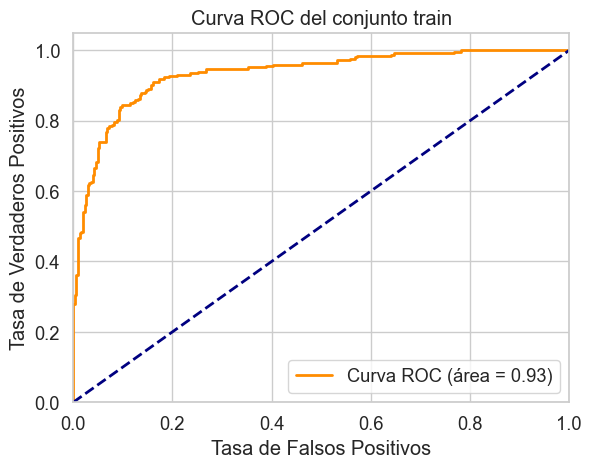

In [40]:
# Graficar la curva ROC para el train
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_train)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto train')
plt.legend(loc="lower right")
plt.show()

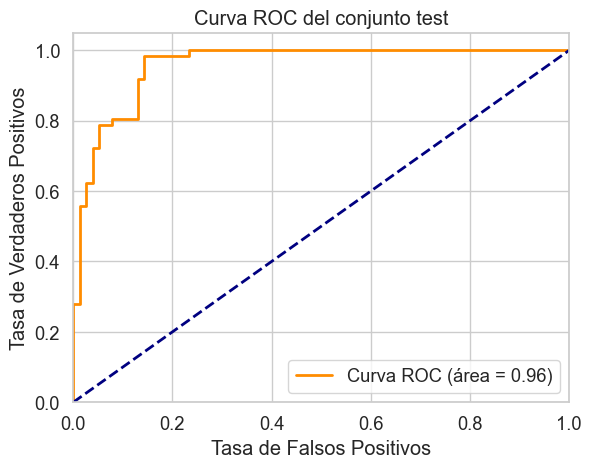

In [41]:
# Graficar la curva ROC para el test
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto test')
plt.legend(loc="lower right")
plt.show()

* El pipeline para la regresión logistica

In [42]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =========================================================================
# 1. CARGA DE DATA E INGENIERÍA DE CARACTERÍSTICAS
# =========================================================================
filename = "C:\\Documentos\\Books_CienciaDatos\\DSTripleA\\docs\\_data\\dataml\\cc_approvals.data"
cc_apps = pd.read_csv(filename, header=None)

cc_apps.columns = [
    'Sexo',
    'Edad',
    'Deuda',
    'Casado',
    'ClienteBancario',
    'Educacion',
    'Etnicidad',
    'AniosEmpleo',
    'DeudaAnterior',
    'Empleado',
    'PuntajeCrediticio',
    'LicenciaConducir',
    'Ciudadano',
    'CodigoPostal',
    'Ingreso',
    'EstadoAprobado',
]

# Reemplazar los '?'s con NaN en los conjuntos de datos
cc_apps_2 = cc_apps.replace('?', np.NaN)

# Cambiar la variable Edad que está en objeto por float
cc_apps_2['Edad'] = cc_apps_2['Edad'].astype(float)

# --- TUS AGRUPACIONES DE INGENIERÍA DE CARACTERÍSTICAS ---
cc_apps_2['Casado'] = cc_apps_2['Casado'].replace('l', 'y')
cc_apps_2['ClienteBancario'] = cc_apps_2['ClienteBancario'].replace('gg', 'p')
cc_apps_2['Educacion'] = cc_apps_2['Educacion'].replace('r', 'j')
cc_apps_2['Etnicidad'] = cc_apps_2['Etnicidad'].replace('o', 'n')

# --- SELECCIÓN DE CARACTERÍSTICAS (Basada en el éxito del VIF) ---
variables_a_eliminar = [
    'LicenciaConducir',
    'CodigoPostal',
    'ClienteBancario',
    'Etnicidad',
]
cc_apps_filtrado = cc_apps_2.drop(columns=variables_a_eliminar)

# Convertimos el target a binario
cc_apps_filtrado['EstadoAprobado'] = cc_apps_filtrado['EstadoAprobado'].map(
    {'+': 1, '-': 0}
)

# Separamos características independientes (X) y variable objetivo (y)
X = cc_apps_filtrado.drop(columns=['EstadoAprobado'])
y = cc_apps_filtrado['EstadoAprobado']

# Dividimos en Train y Test usando estratificación para mantener la proporción del target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)

# Identificamos las columnas por su tipo para alimentar el preprocesador del pipeline
col_categoricas = (
    X_train.select_dtypes(include=['object', 'category']).columns.tolist()
)
col_numericas = X_train.select_dtypes(include=[np.number]).columns.tolist()

# =========================================================================
# 2. CONSTRUCCIÓN DEL PIPELINE COMPLETO MEDIANTE MAKE_PIPELINE
# =========================================================================

# Diseñamos el preprocesador: imputamos nulos categóricos por la Moda y aplicamos One-Hot Encoding
# Nota: Como las categóricas tienen nulos, metemos un mini-pipeline interno para ellas
preprocesador_cat = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
)

preprocesador_global = ColumnTransformer(
    transformers=[('cat', preprocesador_cat, col_categoricas)],
    remainder='passthrough',  # Mantiene las columnas numéricas con sus nulos intactos para el IterativeImputer
)

# Creamos el pipeline unificado con los pasos secuenciales e inicializamos el modelo base
pipeline_lr = make_pipeline(
    preprocesador_global,
    IterativeImputer(
        random_state=42, max_iter=10
    ),  # Imputación MICE sobre la matriz unificada resultante
    StandardScaler(),  # Estandarización final (media 0, varianza 1)
    LogisticRegression(
        random_state=42, max_iter=2000
    ),  # Nuestro clasificador final de riesgo
)

# Malla de hiperparámetros adaptada con el prefijo correcto generado por make_pipeline
param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['liblinear', 'saga'],
    'logisticregression__class_weight': [None, 'balanced'],
}

# =========================================================================
# 3. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
# Evaluamos de forma segura la estabilidad y rendimiento usando el Pipeline en Grid Search
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos la rejilla directamente pasando los conjuntos de datos originales crudos
grid_search_lr.fit(X_train, y_train)

# Extraemos el mejor pipeline ganador completo
mejor_pipeline = grid_search_lr.best_estimator_

# Extraemos la desviación estándar del proceso de CV usando el índice ganador
indice_ganador = grid_search_lr.best_index_
desv_estandar_cv = grid_search_lr.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 4. EVALUACIÓN UTILIZANDO EL PIPELINE EN TRAIN Y TEST (UMBRAL 0.50)
# =========================================================================

# --- Evaluación en el conjunto de Entrenamiento (Train) ---
y_pred_train = mejor_pipeline.predict(X_train)
y_pred_proba_train = mejor_pipeline.predict_proba(X_train)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_pred_proba_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# --- Evaluación en el conjunto de Prueba (Test) ---
y_pred_test = mejor_pipeline.predict(X_test)
y_pred_proba_test = mejor_pipeline.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# =========================================================================
# 5. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n" + "=" * 65)
print("=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN ===")
print("=" * 65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search_lr.best_params_}\n")
print(
    f"ROC AUC Promedio (Validación Cruzada):  {grid_search_lr.best_score_:.4f}"
)
print(f"Desviación ROC AUC (Validación Cruzada): ±{desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Train):                        {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Train):          {accuracy_train * 100:.2f}%")
print(f"Recall (Sensibilidad en Train):         {recall_train * 100:.2f}%")
print(f"F1-Score (Métrica F1 en Train):          {f1_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Test):                   {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%")
print(f"Recall Final (Sensibilidad en Test):    {recall_test * 100:.2f}%")
print(f"F1-Score Final (Métrica F1 en Test):     {f1_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(
    classification_report(
        y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']
    )
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN ===
Mejores Hiperparámetros encontrados:
{'logisticregression__C': 1, 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'saga'}

ROC AUC Promedio (Validación Cruzada):  0.9191
Desviación ROC AUC (Validación Cruzada): ±0.0228

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Train):                        0.9347
Exactitud (Accuracy en Train):          87.14%
Recall (Sensibilidad en Train):         91.06%
F1-Score (Métrica F1 en Train):          86.32%

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)
-----------------------------------------------------------------
ROC AUC Final (Test):                   0.958

## **Modelo de clasificación de KNN**

**K-Nearest Neighbors (KNN)** es un algoritmo de aprendizaje supervisado utilizado tanto para clasificación como para regresión. En la clasificación, asigna una clase a una nueva instancia basada en las clases de sus **k** vecinos más cercanos en el espacio de características. La proximidad o cercanía se mide usando diversas métricas de distancia, como la **distancia euclidiana**, **Manhattan**, o **Minkowski**.

#### **Características**:
1. **Simple y fácil de implementar**: El algoritmo es intuitivo, ya que se basa en medir distancias entre puntos para clasificar las instancias.
2. **Aprendizaje perezoso**: No "aprende" un modelo explícitamente, sino que almacena los datos de entrenamiento y hace las predicciones calculando distancias en el momento de la clasificación.
3. **Sensibilidad a la escala de los datos**: Las características con escalas diferentes pueden dominar el cálculo de distancias. Es común normalizar o estandarizar los datos antes de aplicar KNN.
4. **Parámetro k**: El número de vecinos a considerar (k) es un hiperparámetro clave que debe ajustarse adecuadamente. Un valor bajo puede ser sensible al ruido, mientras que un valor alto puede hacer el modelo demasiado general.
5. **Necesita almacenar todos los datos de entrenamiento**: Requiere mantener todos los ejemplos en memoria para calcular las distancias durante la predicción.

:::{admonition} **Ventajas del KNN**
:class: note 

- **Fácil de entender e implementar**: Es un algoritmo intuitivo y no requiere parámetros complejos.
- **No asume distribuciones específicas**: Es un método no paramétrico, lo que significa que no necesita suposiciones sobre la distribución subyacente de los datos.
- **Puede funcionar bien en conjuntos de datos pequeños**: Es efectivo para datasets pequeños o con pocas características.

:::

:::{admonition} **Desventajas del KNN**
:class: note 

1. **Computacionalmente costoso**: La clasificación de una nueva instancia implica calcular la distancia a todos los puntos del conjunto de datos, lo cual puede ser ineficiente para grandes volúmenes de datos.
2. **Sensibilidad al ruido**: Puede verse afectado negativamente si el conjunto de datos contiene ruido o está desbalanceado.
3. **Maldición de la dimensionalidad**: A medida que aumenta el número de dimensiones, la distancia entre los puntos se vuelve menos significativa, lo que afecta el rendimiento del algoritmo.
4. **Requiere un buen valor de k**: La elección del valor de **k** es crítica y puede requerir experimentación.

:::

#### **Métricas de distancia**

1. **Distancia Euclidiana**:  
   La distancia euclidiana mide la "distancia recta" entre dos puntos en un espacio euclidiano. Para dos puntos $x = (x_1, x_2, \ldots, x_n)$ y $y = (y_1, y_2, \ldots, y_n)$, se calcula como:

   $$
   d_{\text{euclidiana}}(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
   $$

   Es una medida común cuando la diferencia cuadrática es significativa.

2. **Distancia Manhattan**:  
   La distancia Manhattan (o distancia $L_1$) mide la distancia a lo largo de los ejes. Se define como:

   $$
   d_{\text{manhattan}}(x, y) = \sum_{i=1}^{n} |x_i - y_i|
   $$

   Es útil en problemas donde la diferencia absoluta en cada característica es importante.

3. **Distancia de Minkowski**:  
   Es una generalización de las distancias Euclidiana y Manhattan. Está dada por:

   $$
   d_{\text{minkowski}}(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}
   $$

   Donde:
   - $ p $ es un parámetro que determina la forma de la distancia. Cuando $ p=2 $, se convierte en la distancia Euclidiana; y cuando $ p=1 $, se convierte en la distancia Manhattan.

4. **Distancia Chebyshev**:  
   La distancia Chebyshev mide la mayor diferencia absoluta entre las coordenadas de dos puntos:

   $$
   d_{\text{chebyshev}}(x, y) = \max_{i} |x_i - y_i|
   $$

   Es útil en aplicaciones donde el movimiento es limitado a lo largo de un solo eje.

Estas métricas ayudan a determinar qué tan cerca están dos puntos en el espacio de características y son fundamentales para que el algoritmo KNN determine los vecinos más cercanos. La elección de la métrica depende del tipo de datos y la naturaleza del problema.

#### **Idea del KNN**

La idea visual de KNN es la siguiente:

![knn_1](_image/knn1.png)

* **¿Como lo hace?**
    1. Elegir el **número K** de vecinos.
    2. Tomar los **K** vecinos más cercanos del nuevo dato, según la distancia escogida.
    3. Entre esos $K$ vecinos, contar el **número de puntos que pertenecen a cada categoría**
    4. Asignar el **nuevo dato a la categoría con más vecinos en ella.


![knn_4](_image/knn4.png)

![knn_5](_image/knn5.png)

![knn_6](_image/knn6.png)

![knn_7](_image/knn7.png)

![knn_8](_image/knn8.png)

#### **Construcción del modelo de KNN con sus métricas**

Los hiperparámetros para KNN para Clasificación son:

- **`n_neighbors`**: Número de vecinos a considerar. Es un parámetro crítico que afecta la clasificación.

- **`weights`**: Función que asigna pesos a los vecinos. Puede ser:
  - `'uniform'`: Todos los vecinos tienen el mismo peso.
  - `'distance'`: Los vecinos más cercanos tienen más peso.

- **`algorithm`**: Algoritmo utilizado para calcular los vecinos más cercanos. Puede ser:
  - `'auto'`: Elige el mejor algoritmo basado en los datos.
  - `'ball_tree'`: Utiliza el árbol de bolas.
  - `'kd_tree'`: Utiliza el árbol K-D.
  - `'brute'`: Búsqueda por fuerza bruta.

- **`metric`**: Métrica utilizada para calcular la distancia entre puntos. Puede ser:
  - `'euclidean'`: Distancia euclidiana.
  - `'manhattan'`: Distancia de Manhattan.
  - `'chebyshev'`: Distancia de Chebyshev.
  - `'minkowski'`: Distancia de Minkowski (por defecto).
  - Otras métricas personalizadas.

- **`p`**: Potencia de la distancia utilizada para la métrica Minkowski. Cuando `p=1`, se utiliza la distancia de Manhattan, y cuando `p=2`, se utiliza la distancia euclidiana.

- **`leaf_size`**: Tamaño de la hoja para el árbol K-D o árbol de bolas. Afecta la velocidad de la consulta y la memoria utilizada.

- **`metric_params`**: Parámetros adicionales para la métrica, que pueden ser utilizados según la métrica seleccionada.

- **`n_jobs`**: Número de trabajos a ejecutar en paralelo. `-1` utiliza todos los núcleos disponibles.

```python
# Diccionario de hiperparámetros para KNN
parametros = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Número de vecinos a considerar
    'weights': ['uniform', 'distance'],  # Asignación de pesos a los vecinos
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Algoritmo para calcular vecinos
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],  # Métrica de distancia
    'p': [1, 2],  # Potencia de la distancia para Minkowski
    'leaf_size': [30, 40, 50, 60],  # Tamaño de la hoja para árboles
    'metric_params': [None],  # Parámetros adicionales para la métrica
    'n_jobs': [-1, 1]  # Número de trabajos a ejecutar en paralelo
}
```



In [44]:
from sklearn.neighbors import KNeighborsClassifier

# Creamos el pipeline unificado con KNeighborsClassifier final
# Nota: Para KNN, el StandardScaler es un paso de vida o muerte, ya que se basa en distancias métricas.
pipeline_knn = make_pipeline(
    preprocesador_global,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    KNeighborsClassifier()
)

# Malla de hiperparámetros oficial para KNN usando make_pipeline
param_grid = {
    'kneighborsclassifier__n_neighbors': range(1, 25),
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan', 'minkowski'],
    'kneighborsclassifier__leaf_size': [30, 40, 50, 60]
}

# =========================================================================
# 3. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
grid_search_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Entrenamos la rejilla con la data cruda
grid_search_knn.fit(X_train, y_train)

# Extraemos el mejor pipeline ganador completo
mejor_pipeline_knn = grid_search_knn.best_estimator_

# Extraemos la desviación estándar del proceso de CV usando el índice ganador
indice_ganador = grid_search_knn.best_index_
desv_estandar_cv = grid_search_knn.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 4. EVALUACIÓN UTILIZANDO EL PIPELINE EN TRAIN Y TEST (UMBRAL 0.50)
# =========================================================================

# --- Evaluación en el conjunto de Entrenamiento (Train) ---
y_pred_train = mejor_pipeline_knn.predict(X_train)
y_pred_proba_train = mejor_pipeline_knn.predict_proba(X_train)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_pred_proba_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# --- Evaluación en el conjunto de Prueba (Test) ---
y_pred_test = mejor_pipeline_knn.predict(X_test)
y_pred_proba_test = mejor_pipeline_knn.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# =========================================================================
# 5. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n" + "=" * 65)
print("=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (KNN) ===")
print("=" * 65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search_knn.best_params_}\n")
print(f"ROC AUC Promedio (Validación Cruzada):  {grid_search_knn.best_score_:.4f}")
print(f"Desviación ROC AUC (Validación Cruzada): ±{desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Train):                        {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Train):          {accuracy_train * 100:.2f}%")
print(f"Recall (Sensibilidad en Train):         {recall_train * 100:.2f}%")
print(f"F1-Score (Métrica F1 en Train):          {f1_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Test):                   {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%")
print(f"Recall Final (Sensibilidad en Test):    {recall_test * 100:.2f}%")
print(f"F1-Score Final (Métrica F1 en Test):     {f1_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(classification_report(y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']))

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (KNN) ===
Mejores Hiperparámetros encontrados:
{'kneighborsclassifier__leaf_size': 30, 'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 23, 'kneighborsclassifier__weights': 'distance'}

ROC AUC Promedio (Validación Cruzada):  0.9032
Desviación ROC AUC (Validación Cruzada): ±0.0318

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Train):                        1.0000
Exactitud (Accuracy en Train):          100.00%
Recall (Sensibilidad en Train):         100.00%
F1-Score (Métrica F1 en Train):          100.00%

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)
-----------------------------------------------------------------
ROC AUC Final (

* La curva de ROC para el conjunto de train y test

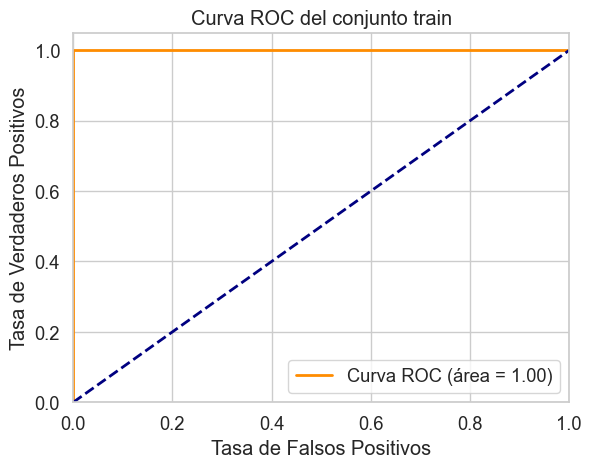

In [45]:
# Graficar la curva ROC para el train
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_train)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto train')
plt.legend(loc="lower right")
plt.show()

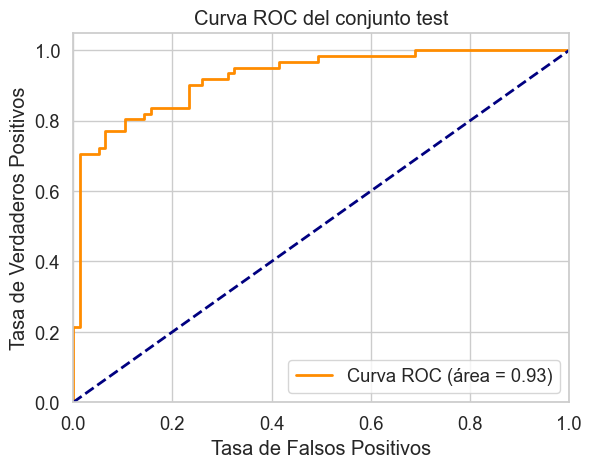

In [46]:
# Graficar la curva ROC para el test
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto test')
plt.legend(loc="lower right")
plt.show()

## **Modelo de Máquina de Soporte Vectorial**

Las **Máquinas de Soporte Vectorial** (SVM, por sus siglas en inglés) son un conjunto de métodos de aprendizaje supervisado utilizados para clasificación y regresión. La idea principal detrás de SVM es encontrar el "hiperplano" que mejor separa las clases en un espacio multidimensional. Este hiperplano se elige de manera que maximice el margen entre las clases, es decir, la distancia entre el hiperplano y los puntos de datos más cercanos de cada clase, llamados vectores de soporte. En el caso de clasificación binaria, SVM trata de maximizar la distancia (o margen) entre el hiperplano de separación y los puntos de datos más cercanos de cada clase, conocidos como **vectores de soporte**. Esto hace que el modelo sea robusto y tenga un buen rendimiento en casos donde las clases están bien separadas.

### **Características de los Modelos SVM**

- **Hiperplano**: La superficie que separa diferentes clases en el espacio de características.
- **Vectores de soporte**: Son los puntos de datos que están más cerca del hiperplano y que, si se eliminaran, cambiarían la posición del hiperplano.
- **Margen**: La distancia máxima entre los vectores de soporte de diferentes clases y el hiperplano.
- **Kernel**: Funciones que permiten transformar los datos a un espacio de mayor dimensión para que sean linealmente separables. Existen diferentes tipos de kernels como:
  - **Lineal**: Utiliza un hiperplano lineal.
  - **Polinómico**: Utiliza un polinomio de un grado específico.
  - **Radial Basis Function (RBF)**: Un kernel basado en la distancia que puede manejar relaciones no lineales.
  - **Sigmoide**: Basado en la función sigmoide.

:::{admonition} **Ventajas del KNN**
:class: note 

- **Eficacia en Espacios Altamente Dimensionales**: SVM es efectivo en problemas de alta dimensionalidad y cuando el número de dimensiones es mayor que el número de muestras.
- **Versatilidad**: Se puede utilizar tanto para clasificación como para regresión.
- **Manejo de No Linealidad**: Gracias al uso de kernels, SVM puede manejar problemas no lineales.

:::

:::{admonition} **Desventajas del KNN**
:class: note 

- **Requiere Ajuste de Hiperparámetros**: El rendimiento de SVM puede depender significativamente de la elección de parámetros como el tipo de kernel y su configuración.
- **Costoso en Cómputo**: Para conjuntos de datos grandes, SVM puede ser ineficiente en términos de memoria y tiempo de entrenamiento.
- **Difícil Interpretación**: Los resultados de SVM no son tan fáciles de interpretar como los de modelos lineales.

:::

#### **Idea de maquina de soporte vectorial**

* ¿Comó separamos estos puntos?

![svc_1](_image/svc1.png)

* Podriamos crear una linea horizontal o vertical o diagonal

![svc_2](_image/svc2.png)

![svc_3](_image/svc3.png)

![svc_6](_image/svc6.png)


* La linea que buscamos es:

![svc_7](_image/svc7.png)

* Estos dos puntos son los **vectores de soporte**

![svc_8](_image/svc8.png)

* El hiperplano es:

![svc_9](_image/svc9.png)

#### **Idea del kernel de maquina de soporte vectorial**

* No siempre debemos usar un kernel lineal, ya que no siempre funciona

![svc_11](_image/svc11.png)

* Ahora, hagamos transformación a una dimensión superior para separar. Usando una sola dimensión

![svc_12](_image/svc12.png)

![svc_13](_image/svc13.png)

* Ahora, usando dos dimensiones

![svc_10](_image/svc10.png)

![svc_14](_image/svc14.png)

![svc_15](_image/svc15.png)

#### **Construcción del modelo de SVM con sus métricas**

Aquí tenemos los principales hiperparámetros que puedes ajustar en un modelo SVM para la clasificación.

- **`C`**: Parámetro de regularización. Controla el trade-off entre maximizar el margen y minimizar el error de clasificación. Un valor más pequeño implica un margen más amplio, pero puede aumentar el error de clasificación.

- **`kernel`**: Tipo de kernel a utilizar. Puede ser:
  - `'linear'`: Hiperplano lineal.
  - `'poly'`: Kernel polinómico.
  - `'rbf'`: Kernel de función de base radial.
  - `'sigmoid'`: Kernel sigmoide.

- **`degree`**: (Solo para kernel polinómico) Grado del polinomio.

- **`gamma`**: Parámetro del kernel. Controla la influencia de un solo ejemplo de entrenamiento. Un valor pequeño implica una influencia amplia, mientras que un valor grande implica una influencia reducida.

- **`coef0`**: Término independiente para kernels polinómicos y sigmoides. Influye en la relación entre los términos de mayor y menor grado.

- **`shrinking`**: Si es `True`, utiliza la heurística de reducción para acelerar la optimización.

- **`probability`**: Si se establece en `True`, habilita el modo de probabilidad, lo que permite obtener probabilidades de predicción.

- **`class_weight`**: Puede ser `None`, `'balanced'` o un diccionario que asigna pesos a las clases para manejar el desbalance en el conjunto de datos.

- **`max_iter`**: Número máximo de iteraciones para el optimizador.

En python

```python
parameters = {
    'C': [0.1, 1, 10, 100],  # Parámetro de regularización
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Tipo de kernel
    'degree': [2, 3, 4],  # Grado del polinomio, solo relevante para kernel 'poly'
    'gamma': ['scale', 'auto'] + [0.01, 0.1, 1, 10],  # Parámetro de gamma
    'coef0': [0.0, 0.1, 0.5, 1.0],  # Término independiente en el kernel polinómico y sigmoide
    'shrinking': [True, False],  # Habilitar la heurística de reducción
    'probability': [True, False],  # Activar la estimación de probabilidad
    'tol': [1e-4, 1e-3, 1e-2],  # Tolerancia para criterios de parada
    'max_iter': [-1, 100, 1000],  # Número máximo de iteraciones
}
```

* Hallemos los mejores hiperparámetros con `kernel='linear'`:

In [47]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

# =========================================================================
# 2. CONSTRUCCIÓN DEL PIPELINE COMPLETO MEDIANTE MAKE_PIPELINE (SVM LINEAL)
# =========================================================================
# Nota: Para SVM, el StandardScaler es obligatorio ya que el algoritmo busca
# maximizar el margen basándose en distancias geométricas.
pipeline_svc = make_pipeline(
    preprocesador_global,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    LinearSVC(
        dual='auto',       # Optimización matemática automática para la convergencia del solver
        random_state=42,
        max_iter=10000
    )
)

# Malla de hiperparámetros adaptada con el prefijo oficial 'linearsvc__'
param_grid = {
    'linearsvc__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'linearsvc__class_weight': [None, 'balanced'],
}

# =========================================================================
# 3. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
grid_search_kl = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos la rejilla con la data cruda que ya está en memoria
grid_search_kl.fit(X_train, y_train)

# Extraemos el mejor pipeline ganador completo
mejor_pipeline_svc = grid_search_kl.best_estimator_

# Extraemos la desviación estándar del proceso de CV usando el índice ganador
indice_ganador = grid_search_kl.best_index_
desv_estandar_cv = grid_search_kl.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 4. EVALUACIÓN UTILIZANDO EL PIPELINE EN TRAIN Y TEST (UMBRAL 0.50)
# =========================================================================

# --- Evaluación en el conjunto de Entrenamiento (Train) ---
y_pred_train = mejor_pipeline_svc.predict(X_train)
# CORRECCIÓN: LinearSVC requiere usar decision_function en lugar de predict_proba
y_scores_train = mejor_pipeline_svc.decision_function(X_train)

roc_auc_train = roc_auc_score(y_train, y_scores_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# --- Evaluación en el conjunto de Prueba (Test) ---
y_pred_test = mejor_pipeline_svc.predict(X_test)
# CORRECCIÓN: Aplicamos lo mismo para el set de prueba
y_scores_test = mejor_pipeline_svc.decision_function(X_test)

roc_auc_test = roc_auc_score(y_test, y_scores_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# =========================================================================
# 5. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n" + "=" * 65)
print("=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (SVM LINEAL) ===")
print("=" * 65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search_kl.best_params_}\n")
print(
    f"ROC AUC Promedio (Validación Cruzada):  {grid_search_kl.best_score_:.4f}"
)
print(f"Desviación ROC AUC (Validación Cruzada): ±{desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Train):                        {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Train):          {accuracy_train * 100:.2f}%")
print(f"Recall (Sensibilidad en Train):         {recall_train * 100:.2f}%")
print(f"F1-Score (Métrica F1 en Train):          {f1_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Test):                   {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%")
print(f"Recall Final (Sensibilidad en Test):    {recall_test * 100:.2f}%")
print(f"F1-Score Final (Métrica F1 en Test):     {f1_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(
    classification_report(
        y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']
    )
)

Fitting 5 folds for each of 14 candidates, totalling 70 fits

=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (SVM LINEAL) ===
Mejores Hiperparámetros encontrados:
{'linearsvc__C': 0.1, 'linearsvc__class_weight': None}

ROC AUC Promedio (Validación Cruzada):  0.9191
Desviación ROC AUC (Validación Cruzada): ±0.0228

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Train):                        0.9344
Exactitud (Accuracy en Train):          87.14%
Recall (Sensibilidad en Train):         89.43%
F1-Score (Métrica F1 en Train):          86.11%

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)
-----------------------------------------------------------------
ROC AUC Final (Test):                   0.9578
Exactitud Final (Accuracy en Test):     87.68%
Recall Final (Sensibilidad en Test):

* Hagamos la curva de ROC de `SVC` con el kernel lineal para el train y el test

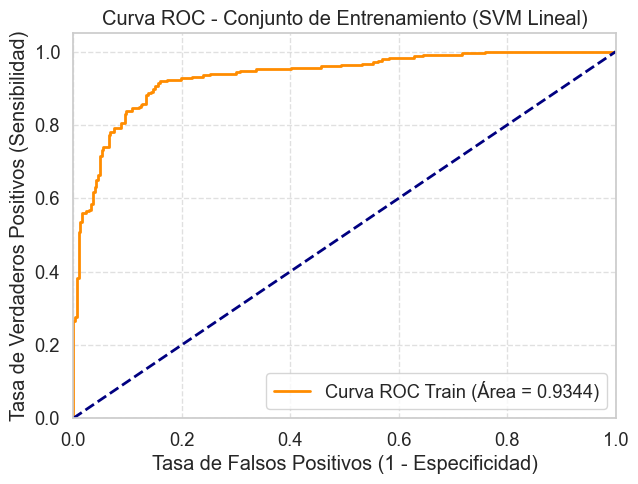

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

# =========================================================================
# GRAFICAR LA CURVA ROC PARA EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
# =========================================================================
# CORRECCIÓN CRUCIAL: Usamos y_scores_train (distancias del hiperplano) en lugar de las predicciones binarias
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_scores_train)
roc_auc_train_curve = auc(fpr_train, tpr_train)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr_train,
    tpr_train,
    color='darkorange',
    lw=2,
    label='Curva ROC Train (Área = %0.4f)' % roc_auc_train_curve,
)
plt.plot(
    [0, 1], [0, 1], color='navy', lw=2, linestyle='--'
)  # Línea de predicción aleatoria

# Configuración estética del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Conjunto de Entrenamiento (SVM Lineal)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

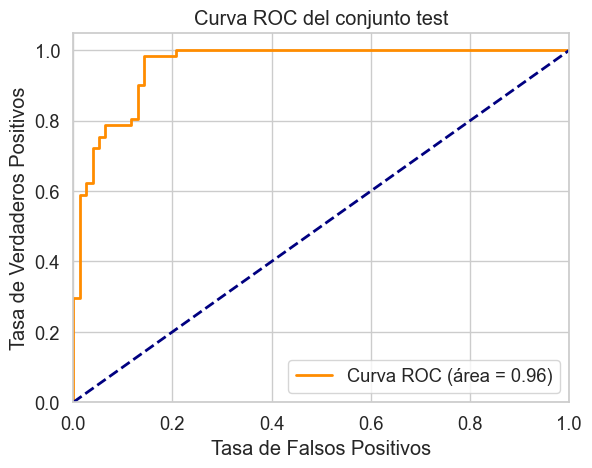

In [49]:
# Graficar la curva ROC para el test
fpr, tpr, thresholds = roc_curve(y_test, y_scores_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto test')
plt.legend(loc="lower right")
plt.show()

:::{admonition} **Ejercicios**
:class: tip

Ya realizaste el modelo de `SVC` con kernel lineal. Ahora encuentra el modelo con **kernel polinomial, radial y sigmoide** con los mejores parámetros. También, halla sus métricas y gráfica la curva de `ROC`.

:::

## **Modelo de Naives-Bayes**

El **Clasificador Naive Bayes** es un modelo de aprendizaje supervisado basado en la **Regla de Bayes**, que se utiliza para problemas de clasificación. Este clasificador asume que las características son independientes entre sí dado el valor de la clase, lo que simplifica el cálculo de las probabilidades. Aunque esta suposición de independencia rara vez se cumple completamente en la práctica, el modelo es efectivo y eficiente para problemas de clasificación, especialmente en el análisis de texto y problemas multiclase.

###  **Definición de la Regla de Bayes**

La **Regla de Bayes** es un principio fundamental en probabilidad y estadística que permite calcular la probabilidad de que un evento ocurra dado que otro evento ya ha ocurrido. Esta regla es clave para la inferencia estadística y es la base de varios modelos probabilísticos, como el clasificador Naive Bayes. La Regla de Bayes se puede expresar como:

$$
P(A | B) = \frac{P(B | A) \cdot P(A)}{P(B)}
$$

donde:

- $P(A | B)$: Probabilidad de $A$ dado $B$.
- $P(B | A)$: Probabilidad de $B$ dado $A$.
- $P(A)$: Probabilidad a priori de $A$.
- $P(B)$: Probabilidad a priori de $B$.


#### **Ejemplo de la regla de Bayes** 

Supongamos que un banco quiere evaluar la probabilidad de que un cliente esté en alto riesgo de incumplimiento de pago de un préstamo (es decir, que no lo pague) dado que tiene un historial crediticio bajo. Usaremos la **Regla de Bayes** para calcular esta probabilidad.

1. **Definimos los eventos:**
   - $A$: El cliente está en alto riesgo de incumplimiento.
   - $B$: El cliente tiene un historial crediticio bajo.

2. **Datos disponibles:**
   - $P(A)$: Probabilidad de que cualquier cliente esté en alto riesgo de incumplimiento (por ejemplo, un 10%, o $P(A) = 0.1$).
   - $P(B | A)$: Probabilidad de que un cliente tenga un historial crediticio bajo si está en alto riesgo de incumplimiento (por ejemplo, un 80%, o $P(B | A) = 0.8$).
   - $P(B)$: Probabilidad de que un cliente tenga un historial crediticio bajo (por ejemplo, un 20%, o $P(B) = 0.2$).

3. **Aplicamos la Regla de Bayes:**

   Usamos la fórmula de Bayes para calcular $P(A | B)$, la probabilidad de que un cliente esté en alto riesgo de incumplimiento dado que tiene un historial crediticio bajo:

   $$
   P(A | B) = \frac{P(B | A) \cdot P(A)}{P(B)}
   $$

   Sustituimos los valores:

   $$
   P(A | B) = \frac{0.8 \cdot 0.1}{0.2} = \frac{0.08}{0.2} = 0.4
   $$

4. **Interpretación del resultado:**

   La probabilidad de que un cliente esté en alto riesgo de incumplimiento dado que tiene un historial crediticio bajo es del 40%. Este resultado puede ayudar al banco a tomar decisiones informadas sobre la aprobación de préstamos y a gestionar mejor el riesgo.

Este ejemplo muestra cómo la Regla de Bayes permite al banco actualizar las probabilidades de riesgo en función de la información disponible sobre el historial crediticio del cliente.

### **Clasificador Naive Bayes**

El **Clasificador Naive Bayes** es un modelo de aprendizaje supervisado basado en la **Regla de Bayes**. Se utiliza para problemas de clasificación, asumiendo que las características de cada instancia son independientes entre sí dado el valor de la clase. Aunque esta suposición rara vez es completamente cierta, el modelo es efectivo y eficiente para muchas aplicaciones prácticas, especialmente en el análisis de texto y problemas multiclase.

1. **Fórmula Matemática del Clasificador Naive Bayes**

Para un conjunto de datos con una instancia $x = (x_1, x_2, \dots, x_n)$ y una clase $C_k$, la probabilidad de que la instancia pertenezca a la clase $C_k$ se expresa como:

$$
P(C_k | x) \propto P(C_k) \prod_{i=1}^{n} P(x_i | C_k)
$$

donde:
- $P(C_k | x)$: Probabilidad posterior de la clase $C_k$ dado el conjunto de características $x$.
- $P(C_k)$: Probabilidad a priori de la clase $C_k$.
- $P(x_i | C_k)$: Probabilidad condicional de la característica $x_i$ dado que la clase es $C_k$.

El clasificador calcula la probabilidad de cada clase y selecciona la clase con la mayor probabilidad como la predicción.

2. **Características del Clasificador Naive Bayes**

* **Suposición de independencia**: Se asume que las características son independientes entre sí dado el valor de la clase, lo que simplifica el cálculo de probabilidades.
* **Modelo probabilístico**: Calcula la probabilidad de que una instancia pertenezca a una clase en particular utilizando las probabilidades condicionales de cada característica.
* **Multiclase**: Puede ser utilizado para problemas con múltiples clases de salida.

:::{admonition} **Ventajas del Clasificador Naive Bayes**
:class: note

1. **Eficiencia**: Es rápido y eficiente, ideal para grandes conjuntos de datos, ya que requiere menos datos para entrenarse y clasificar.
2. **Rendimiento en problemas de texto**: Funciona bien en la clasificación de texto y filtrado de spam, donde la suposición de independencia es razonable.
3. **Manejo de datos faltantes**: Puede manejar datos faltantes ignorando las características que no están presentes.
4. **Escalable**: Funciona bien con muchos tipos de datos y es escalable a problemas de clasificación multiclase.

:::

:::{admonition} **Desventajas del Clasificador Naive Bayes**
:class: note

1. **Suposición de independencia**: La suposición de independencia rara vez se cumple en la práctica, lo que limita su precisión en algunos contextos.
2. **Sensibilidad a datos de entrenamiento**: Su rendimiento puede ser afectado por la cantidad y calidad de los datos de entrenamiento.
3. **No apto para datos continuos sin discretización**: Para manejar datos continuos, se suele requerir discretización o asumir una distribución, como la distribución normal, lo cual puede no siempre ser adecuado.

:::


El clasificador Naive Bayes es una herramienta poderosa y sencilla para tareas de clasificación rápida y efectiva, siempre que las características sean aproximadamente independientes.

#### **Modelos de Naive Bayes para clasificación**

1. **Gaussian Naive Bayes (`GaussianNB`)**
- **Uso**: Adecuado para problemas de clasificación donde las características son continuas y se asume que siguen una distribución normal (gaussiana).
- **Ejemplo de aplicación**: 
  - Clasificación de textos.
  - Detección de fraudes.
  - Problemas donde las características numéricas pueden considerarse distribuciones normales.

2. **Multinomial Naive Bayes (`MultinomialNB`)**
- **Uso**: Ideal para clasificar datos discretos, especialmente con características que representan recuentos o frecuencias, como el texto en procesamiento de lenguaje natural.
- **Ejemplo de aplicación**:
  - Clasificación de documentos.
  - Análisis de sentimientos.
  - Detección de spam.
  - Tareas donde las características se pueden contar (frecuencia de palabras en un texto).

3. **Bernoulli Naive Bayes (`BernoulliNB`)**
- **Uso**: Similar a `MultinomialNB`, pero se utiliza para características binarias (0 o 1). Asume que las características son variables binarias.
- **Ejemplo de aplicación**:
  - Clasificación de textos donde la presencia o ausencia de una palabra es más importante que la frecuencia (si una palabra está presente o no en un documento).

En resumen de cuándo usar cada modelo
- **GaussianNB**: Usa cuando tus datos son continuos y se distribuyen normalmente.
- **MultinomialNB**: Usa para datos discretos y en tareas de clasificación de texto donde las características representan recuentos o frecuencias.
- **BernoulliNB**: Usa para datos binarios donde la presencia o ausencia de características es relevante.


#### **Construcción del modelo de Naive Bayes**

Aquí, tenemos los principales hiperparámetros del modelo de Gaussian Naive Bayes `GaussianNB`.

* `priors`
    - **Descripción**: Lista de probabilidades a priori de las clases. Si se establece, las probabilidades a priori son normalizadas de acuerdo a estas.
    - **Tipo**: `array-like`, forma (n_classes,)

* `var_smoothing`
    - **Descripción**: Valor de suavizado para evitar que la varianza sea cero. Se agrega a la varianza de cada característica antes de realizar la predicción.
    - **Tipo**: `float`
    - **Valor por defecto**: `1e-9`

```python
# Hiperparámetros de Gaussian Naive Bayes
hyperparameters = {
    'priors': [
        None,               # No se establecen probabilidades a priori
        [0.5, 0.5],        # Probabilidades a priori iguales
        [0.6, 0.4],        # Probabilidades a priori
        [0.7, 0.3],        # Probabilidades a priori
    ],
    'var_smoothing': [
        1e-9,              # Valor de suavizado bajo
        1e-8,              # Valor de suavizado ligeramente mayor
        1e-7,              # Valor de suavizado medio
        1e-6,              # Valor de suavizado alto
        1e-5               # Valor de suavizado aún más alto
    ]
}
```

In [51]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
import numpy as np

# =========================================================================
# 2. CONSTRUCCIÓN DEL PIPELINE COMPLETO MEDIANTE MAKE_PIPELINE (NAIVE BAYES)
# =========================================================================
# Nota: GaussianNB no requiere StandardScaler estrictamente (no es sensible
# a la escala como SVM), pero se mantiene para conservar consistencia con
# el resto de los modelos comparados y porque no perjudica el desempeño.
pipeline_nb = make_pipeline(
    preprocesador_global,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    GaussianNB()
)

# Malla de hiperparámetros adaptada con el prefijo oficial 'gaussiannb__'
# var_smoothing controla la estabilidad numérica (equivalente al "suavizado"
# de la varianza); no existe 'class_weight' en GaussianNB, por lo que se
# usa 'priors' si se quiere forzar el balance de clases manualmente.
param_grid = {
    'gaussiannb__var_smoothing': np.logspace(0, -9, num=50),
}

# =========================================================================
# 3. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
grid_search_nb = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos la rejilla con la data cruda que ya está en memoria
grid_search_nb.fit(X_train, y_train)

# Extraemos el mejor pipeline ganador completo
mejor_pipeline_nb = grid_search_nb.best_estimator_

# Extraemos la desviación estándar del proceso de CV usando el índice ganador
indice_ganador = grid_search_nb.best_index_
desv_estandar_cv = grid_search_nb.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 4. EVALUACIÓN UTILIZANDO EL PIPELINE EN TRAIN Y TEST (UMBRAL 0.50)
# =========================================================================

# --- Evaluación en el conjunto de Entrenamiento (Train) ---
y_pred_train = mejor_pipeline_nb.predict(X_train)
# GaussianNB sí soporta predict_proba, a diferencia de LinearSVC
y_scores_train = mejor_pipeline_nb.predict_proba(X_train)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_scores_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# --- Evaluación en el conjunto de Prueba (Test) ---
y_pred_test = mejor_pipeline_nb.predict(X_test)
y_scores_test = mejor_pipeline_nb.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_scores_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# =========================================================================
# 5. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n" + "=" * 65)
print("=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (NAIVE BAYES) ===")
print("=" * 65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search_nb.best_params_}\n")
print(
    f"ROC AUC Promedio (Validación Cruzada):  {grid_search_nb.best_score_:.4f}"
)
print(f"Desviación ROC AUC (Validación Cruzada): ±{desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Train):                        {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Train):          {accuracy_train * 100:.2f}%")
print(f"Recall (Sensibilidad en Train):         {recall_train * 100:.2f}%")
print(f"F1-Score (Métrica F1 en Train):          {f1_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Test):                   {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%")
print(f"Recall Final (Sensibilidad en Test):    {recall_test * 100:.2f}%")
print(f"F1-Score Final (Métrica F1 en Test):     {f1_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(
    classification_report(
        y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']
    )
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (NAIVE BAYES) ===
Mejores Hiperparámetros encontrados:
{'gaussiannb__var_smoothing': 1.0}

ROC AUC Promedio (Validación Cruzada):  0.8859
Desviación ROC AUC (Validación Cruzada): ±0.0376

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Train):                        0.9020
Exactitud (Accuracy en Train):          83.15%
Recall (Sensibilidad en Train):         71.54%
F1-Score (Métrica F1 en Train):          79.10%

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)
-----------------------------------------------------------------
ROC AUC Final (Test):                   0.9331
Exactitud Final (Accuracy en Test):     80.43%
Recall Final (Sensibilidad en Test):    57.38%
F1-Scor

* Hagamos la curva de ROC de `Naive-Bayes` para el train y el test

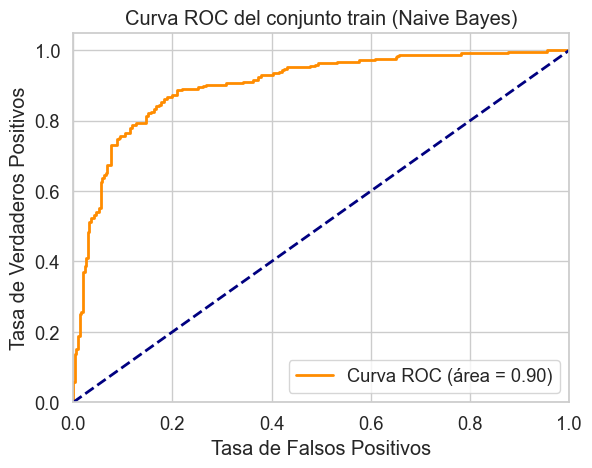

In [52]:
from sklearn.metrics import roc_curve, auc

# Graficar la curva ROC para el train (usando el pipeline de Naive Bayes)
fpr, tpr, thresholds = roc_curve(y_train, y_scores_train)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto train (Naive Bayes)')
plt.legend(loc="lower right")
plt.show()

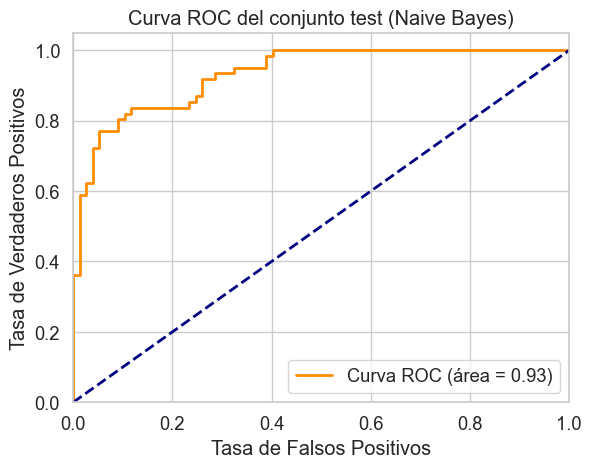

In [53]:
# Graficar la curva ROC para el test (usando el pipeline de Naive Bayes)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto test (Naive Bayes)')
plt.legend(loc="lower right")
plt.show()

## **Modelo de arbol de decisión**

Los **árboles de decisión** son modelos predictivos que utilizan reglas binarias (sí/no) para segmentar las observaciones en función de sus atributos, permitiendo predecir el valor de la variable objetivo. Este tipo de modelo es ideal para problemas con múltiples predictores que interactúan de manera compleja y no lineal, ya que divide el espacio de predictores en regiones simples donde resulta más fácil gestionar estas interacciones.

Muchos métodos predictivos construyen modelos globales, donde una única ecuación representa el comportamiento de todo el espacio de datos. Sin embargo, en casos con interacciones complejas entre predictores, resulta difícil encontrar un modelo global que capture adecuadamente las relaciones entre las variables. Los métodos estadísticos y de machine learning basados en árboles son **técnicas supervisadas no paramétricas** que segmentan el espacio de los predictores, dividiéndolo en subespacios más manejables. Esta característica de segmentación es una de las principales razones por las que estos modelos son tan efectivos.

Gracias a su capacidad para capturar relaciones complejas, los métodos basados en árboles se han consolidado como una herramienta fundamental en el ámbito predictivo, proporcionando buenos resultados en una variedad de problemas. Este documento explora en detalle cómo se construyen y aplican los árboles de decisión para tareas de **clasificación y regresión**, y presenta cómo estos modelos forman la base de técnicas más avanzadas como **Random Forest** y **Gradient Boosting Machine**.

### **Componentes de un árbol de decisión**

1. **Nodo raíz**: 
   - Es el primer nodo del árbol y representa la característica inicial que divide el conjunto de datos en dos o más subconjuntos. La selección de esta característica se realiza en base a la que aporta la mejor pureza en la partición de datos.

2. **Nodos internos**:
   - Son los nodos intermedios donde se toman decisiones adicionales en base a características específicas. Cada nodo interno representa una división adicional del conjunto de datos, con el objetivo de aumentar la homogeneidad de los subconjuntos en función de la métrica seleccionada (como el índice de Gini o la entropía).

3. **Hojas (o nodos terminales)**:
   - Son los nodos finales que representan el resultado del modelo. En árboles de clasificación, cada hoja asigna una clase, mientras que en árboles de regresión, asigna un valor específico. Las hojas no se dividen más, ya que cumplen con un criterio de parada o porque los datos dentro del nodo son suficientemente homogéneos.

4. **Ramas**:
   - Las conexiones entre los nodos representan las condiciones de decisión en cada nivel del árbol. Cada rama conecta un nodo con sus nodos hijos y representa un camino de decisiones basado en el valor de una característica.

Un árbol de decisión puede visualizarse como una estructura jerárquica de decisiones, donde cada nivel del árbol divide los datos en subconjuntos más homogéneos en función de las características seleccionadas en cada nodo.


#### **Construcción del modelo de arbol**

Para construir un árbol de clasificación, se utiliza el mismo método de **recursive binary splitting** que se emplea en árboles de regresión. Sin embargo, cuando la variable de respuesta es cualitativa, no se puede utilizar el **RSS** (Residual Sum of Squares) como criterio de selección de divisiones óptimas. Existen varias alternativas, cuyo objetivo es encontrar nodos lo más puros y homogéneos posible. Las métricas más comunes son:

1. Tasa de error de clasificación (Classification Error Rate)

    La tasa de error de clasificación se define como la proporción de observaciones que no pertenecen a la clase mayoritaria del nodo. Se calcula con la fórmula:

    $$
    E_m = 1 - \max_k(\hat{p}_{mk})
    $$

    donde $\hat{p}_{mk}$ representa la proporción de observaciones en el nodo $m$ que pertenecen a la clase $k$. Aunque esta métrica es sencilla de entender, no es lo suficientemente sensible para construir árboles de alta calidad; por esta razón, en la práctica no suele utilizarse como métrica principal.

2. El **Índice de Gini** es una métrica que mide la pureza de un nodo en un árbol de decisión. Cuantifica la varianza total de las $K$ clases presentes en el nodo $m$. Se calcula con la siguiente fórmula:

   $$
   G_m = \sum_{k=1}^{K} \hat{p}_{mk} \cdot (1 - \hat{p}_{mk})
   $$

   donde $\hat{p}_{mk}$ es la proporción de observaciones en el nodo $m$ que pertenecen a la clase $k$. Si $\hat{p}_{mk}$ está cerca de 0 o 1 (es decir, el nodo contiene principalmente observaciones de una sola clase), el producto $\hat{p}_{mk} \cdot (1 - \hat{p}_{mk})$ será pequeño. Por lo tanto, un nodo es más puro cuanto menor es su valor de Gini.

   El algoritmo **CART** (*Classification and Regression Trees*) utiliza el índice de Gini como criterio de división para maximizar la homogeneidad de los nodos.

   * **Ejemplo de índice de Gini**

      Supongamos que tenemos un nodo con 100 observaciones distribuidas en tres clases: A, B y C.

      <div align="center">


      | Clase | Cantidad de observaciones | Proporción ($\hat{p}_{mk}$) |
      |-------|----------------------------|----------------------------------|
      | A     | 50                         | 0.5                              |
      | B     | 30                         | 0.3                              |
      | C     | 20                         | 0.2                              |

      </div>

      Para calcular el índice de Gini en este nodo, utilizamos la fórmula:

      $$
      G_m = \sum_{k=1}^{K} \hat{p}_{mk} \cdot (1 - \hat{p}_{mk})
      $$

      1. Para la clase A:
   
      $$
      \hat{p}_{A} = 0.5, \quad 0.5 \cdot (1 - 0.5) = 0.5 \cdot 0.5 = 0.25
      $$

      2. Para la clase B:
   
      $$
      \hat{p}_{B} = 0.3, \quad 0.3 \cdot (1 - 0.3) = 0.3 \cdot 0.7 = 0.21
      $$

      3. Para la clase C:
      
      $$
      \hat{p}_{C} = 0.2, \quad 0.2 \cdot (1 - 0.2) = 0.2 \cdot 0.8 = 0.16
      $$

      Sumamos los valores obtenidos para cada clase para obtener el índice de Gini total del nodo:

      $$
      G_m = 0.25 + 0.21 + 0.16 = 0.62
      $$

      Por lo tanto, el índice de Gini para este nodo es **0.62**. Esto indica que el nodo tiene un grado moderado de impureza; el valor de Gini será menor a medida que el nodo contenga una mayor proporción de observaciones en una sola clase.

3. **Ganancia de Información: Entropía Cruzada**

   La **entropía** es otra métrica que mide el nivel de desorden o impureza en un nodo. En un nodo completamente puro (que contiene observaciones de una sola clase), la entropía es cero. Por el contrario, cuando las observaciones están repartidas equitativamente entre todas las clases, la entropía alcanza su valor máximo de 1. La fórmula para calcular la entropía es:

   $$
   D = - \sum_{k=1}^{K} \hat{p}_{mk} \cdot \log(\hat{p}_{mk})
   $$

   donde $\hat{p}_{mk}$ es la proporción de observaciones en el nodo $m$ que pertenecen a la clase $k$. La entropía se utiliza en los algoritmos **C4.5** y **C5.0** para calcular la **ganancia de información** (*information gain*), que determina la mejor división al maximizar la reducción del desorden en los nodos.

   La **ganancia de información** permite segmentar el espacio de características de manera más eficiente, creando nodos que son lo más homogéneos posible en términos de su clase.

   * **Ejemplo de entropía**

      Supongamos que tenemos un nodo con 100 observaciones distribuidas en tres clases: A, B y C.

      <div align="center">

      | Clase | Cantidad de observaciones | Proporción (\( \hat{p}_{mk} \)) |
      |-------|----------------------------|----------------------------------|
      | A     | 50                         | 0.5                              |
      | B     | 30                         | 0.3                              |
      | C     | 20                         | 0.2                              |

      </div>

      Para calcular la entropía en este nodo, utilizamos la fórmula:

      $$
      D = - \sum_{k=1}^{K} \hat{p}_{mk} \cdot \log_2(\hat{p}_{mk})
      $$

      1. Para la clase A:
      $$
      \hat{p}_{A} = 0.5, \quad -0.5 \cdot \log_2(0.5) = -0.5 \cdot (-1) = 0.5
      $$

      2. Para la clase B:
      $$
      \hat{p}_{B} = 0.3, \quad -0.3 \cdot \log_2(0.3) \approx -0.3 \cdot (-1.737) \approx 0.521
      $$

      3. Para la clase C:
      $$
      \hat{p}_{C} = 0.2, \quad -0.2 \cdot \log_2(0.2) \approx -0.2 \cdot (-2.322) \approx 0.464
      $$

      Sumamos los valores obtenidos para cada clase para obtener la entropía total del nodo:

      $$
      D = 0.5 + 0.521 + 0.464 = 1.485
      $$

      Por lo tanto, la entropía para este nodo es aproximadamente **1.485**. Este valor indica un grado moderado de impureza en el nodo; cuanto mayor es la entropía, mayor es la mezcla de clases dentro del nodo.

:::{admonition} **Ventajas del arbol de decisión**
:class: note

- Los árboles son fáciles de interpretar incluso cuando las relaciones entre los predictores son complejas.
- Los modelos basados en un solo árbol (a diferencia de Random Forest o Boosting) pueden representarse gráficamente, incluso cuando el número de predictores es mayor de 3.
- Pueden manejar tanto predictores numéricos como categóricos sin la necesidad de crear variables dummy o aplicar one-hot encoding. Sin embargo, esto depende de la implementación específica del algoritmo en cada biblioteca.
- Al ser métodos no paramétricos, no requieren que los datos sigan ninguna distribución específica.
- Requieren mucho menos preprocesamiento y limpieza de datos en comparación con otros métodos de aprendizaje estadístico (por ejemplo, no necesitan estandarización).
- No se ven muy influenciados por outliers.
- En el caso de valores faltantes en un predictor, se puede hacer una predicción utilizando todas las observaciones del último nodo alcanzado, aunque con menor precisión.
- Son muy útiles en la exploración de datos, permitiendo identificar rápida y eficientemente las variables más importantes.
- Seleccionan predictores de forma automática.
- Son aplicables tanto a problemas de regresión como de clasificación.

:::

:::{admonition} **Desventajas del arbol de decisión**
:class: note

- La capacidad predictiva de los modelos basados en un solo árbol es inferior a la de otros modelos, debido a su tendencia al overfitting y su alta varianza. Técnicas como el bagging, Random Forest y Boosting, que combinan múltiples árboles, ayudan a mejorar estos problemas.
- Son sensibles a datos de entrenamiento desbalanceados, donde una clase puede dominar sobre las demás.
- Pierden parte de la información al tratar predictores continuos, ya que los categorizan durante la división de los nodos.
- La creación de las ramificaciones de los árboles se basa en el algoritmo de *recursive binary splitting*, que evalúa las divisiones de cada predictor usando una métrica específica (RSS, Gini, entropía). Los predictores continuos tienen más probabilidades de contener un punto de corte óptimo, lo cual los favorece en la creación del árbol.
- No pueden extrapolar fuera del rango de valores de los predictores observado en los datos de entrenamiento.

:::

#### **Idea del arbol de decisión**

* Miremos dos variables independientes en el siguiente gráfico

![arb decision 1](_image/ab1.png)

* Primer split

![arb decision 2](_image/ab2.png)

* Nuestra primera ramificación nos queda

![arb decision 3](_image/ab3.png)

* Segundo split

![arb decision 4](_image/ab4.png)

* Segunda ramificación

![arb decision 5](_image/ab5.png)

* Tercer split

![arb decision 6](_image/ab6.png)  

* Tercera ramificación

![arb decision 7](_image/ab7.png)

* Cuarto split

![arb decision 8](_image/ab8.png)  

* Ultima ramificación

![arb decision 9](_image/ab9.png)

En un arbol de decisión, podemos tener un conjunto de entrenamiento con muchas características, esto hace que tengamos más splits y las ramificaciones sean más masivas.

#### **Construcción del modelo de arbol de decisión con sus métricas**

Los hiperparámetros de Decision Tree Classifier (`DecisionTreeClassifier`)

* `criterion`
    - **Descripción**: Función que mide la calidad de una división.
    - **Tipo**: `str`
    - **Valores posibles**:
        - `'gini'` (por defecto): usa el índice de Gini.
        - `'entropy'`: usa la entropía de la información.

* `splitter`
    - **Descripción**: Estrategia para dividir cada nodo.
    - **Tipo**: `str`
    - **Valores posibles**:
        - `'best'` (por defecto): selecciona la mejor división.
        - `'random'`: selecciona una división al azar.

* `max_depth`
    - **Descripción**: Profundidad máxima del árbol. Controla el sobreajuste.
    - **Tipo**: `int` o `None`
    - **Valor por defecto**: `None` (el árbol crece hasta que todas las hojas son puras o contienen menos muestras que `min_samples_split`).

* `min_samples_split`
    - **Descripción**: Número mínimo de muestras necesarias para dividir un nodo.
    - **Tipo**: `int` o `float`
    - **Valor por defecto**: `2`

* `min_samples_leaf`
    - **Descripción**: Número mínimo de muestras requeridas para formar una hoja.
    - **Tipo**: `int` o `float`
    - **Valor por defecto**: `1`

* `min_weight_fraction_leaf`
    - **Descripción**: Fracción mínima de peso de muestras requerido en una hoja.
    - **Tipo**: `float`
    - **Valor por defecto**: `0.0`

* `max_features`
    - **Descripción**: Número de características a considerar para encontrar la mejor división.
    - **Tipo**: `int`, `float`, `str` o `None`
    - **Valores posibles**:
        - `None` (por defecto): usa todas las características.
        - `int`: selecciona una cantidad específica de características.
        - `float`: selecciona un porcentaje de características.
        - `'auto'`, `'sqrt'`, `'log2'`.

* `max_leaf_nodes`
    - **Descripción**: Número máximo de nodos hoja.
    - **Tipo**: `int` o `None`
    - **Valor por defecto**: `None`

* `min_impurity_decrease`
    - **Descripción**: Umbral mínimo de reducción de impureza.
    - **Tipo**: `float`
    - **Valor por defecto**: `0.0`

* `ccp_alpha`
    - **Descripción**: Parámetro de complejidad de poda (post-poda).
    - **Tipo**: `float`
    - **Valor por defecto**: `0.0`

```python
# Diccionario de hiperparámetros para DecisionTreeClassifier
param_grid = {
    'criterion': ['gini', 'entropy'],  # Medida de calidad de la división
    'splitter': ['best', 'random'],  # Estrategia de división
    'max_depth': [None, 10, 20, 30, 40, 50],  # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10, 20],  # Muestras mínimas para dividir un nodo
    'min_samples_leaf': [1, 2, 5, 10],  # Muestras mínimas para formar una hoja
    'min_weight_fraction_leaf': [0.0, 0.1, 0.2],  # Fracción mínima de peso de muestras en una hoja
    'max_features': [None, 'auto', 'sqrt', 'log2'],  # Características a considerar para la mejor división
    'max_leaf_nodes': [None, 10, 20, 30, 40],  # Número máximo de nodos hoja
    'min_impurity_decrease': [0.0, 0.01, 0.1],  # Umbral de reducción mínima de impureza
    'ccp_alpha': [0.0, 0.01, 0.1, 0.2]  # Parámetro de complejidad de poda
}
```


* Encontremos los mejores parámetros

In [54]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

# =========================================================================
# 2. CONSTRUCCIÓN DEL PIPELINE COMPLETO MEDIANTE MAKE_PIPELINE (ÁRBOL DE DECISIÓN)
# =========================================================================
# Nota: A diferencia de SVM, el árbol de decisión no requiere StandardScaler,
# ya que las divisiones se basan en umbrales por variable y no en distancias
# geométricas. Se mantiene en el pipeline solo por consistencia comparativa.
pipeline_dt = make_pipeline(
    preprocesador_global,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    DecisionTreeClassifier(random_state=42)
)

# Malla de hiperparámetros adaptada con el prefijo oficial 'decisiontreeclassifier__'
param_grid = {
    'decisiontreeclassifier__criterion': ['gini', 'entropy'],
    'decisiontreeclassifier__splitter': ['best', 'random'],
    'decisiontreeclassifier__max_depth': [None, 10, 20, 30, 40, 50],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10, 20],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 5, 10],
    'decisiontreeclassifier__max_features': [None, 'sqrt', 'log2'],
    'decisiontreeclassifier__min_impurity_decrease': [0.0, 0.01, 0.1],
    'decisiontreeclassifier__ccp_alpha': [0.0, 0.01, 0.1, 0.2]
}

# =========================================================================
# 3. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
grid_search_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos la rejilla con la data cruda que ya está en memoria
grid_search_dt.fit(X_train, y_train)

# Extraemos el mejor pipeline ganador completo
mejor_pipeline_dt = grid_search_dt.best_estimator_

# Extraemos la desviación estándar del proceso de CV usando el índice ganador
indice_ganador = grid_search_dt.best_index_
desv_estandar_cv = grid_search_dt.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 4. EVALUACIÓN UTILIZANDO EL PIPELINE EN TRAIN Y TEST (UMBRAL 0.50)
# =========================================================================

# --- Evaluación en el conjunto de Entrenamiento (Train) ---
y_pred_train = mejor_pipeline_dt.predict(X_train)
# El árbol de decisión sí soporta predict_proba, a diferencia de LinearSVC
y_scores_train = mejor_pipeline_dt.predict_proba(X_train)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_scores_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# --- Evaluación en el conjunto de Prueba (Test) ---
y_pred_test = mejor_pipeline_dt.predict(X_test)
y_scores_test = mejor_pipeline_dt.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_scores_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# =========================================================================
# 5. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n" + "=" * 65)
print("=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (ÁRBOL DE DECISIÓN) ===")
print("=" * 65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search_dt.best_params_}\n")
print(
    f"ROC AUC Promedio (Validación Cruzada):  {grid_search_dt.best_score_:.4f}"
)
print(f"Desviación ROC AUC (Validación Cruzada): ±{desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Train):                        {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Train):          {accuracy_train * 100:.2f}%")
print(f"Recall (Sensibilidad en Train):         {recall_train * 100:.2f}%")
print(f"F1-Score (Métrica F1 en Train):          {f1_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Test):                   {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%")
print(f"Recall Final (Sensibilidad en Test):    {recall_test * 100:.2f}%")
print(f"F1-Score Final (Métrica F1 en Test):     {f1_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(
    classification_report(
        y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']
    )
)

Fitting 5 folds for each of 13824 candidates, totalling 69120 fits

=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (ÁRBOL DE DECISIÓN) ===
Mejores Hiperparámetros encontrados:
{'decisiontreeclassifier__ccp_alpha': 0.0, 'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_depth': None, 'decisiontreeclassifier__max_features': None, 'decisiontreeclassifier__min_impurity_decrease': 0.01, 'decisiontreeclassifier__min_samples_leaf': 10, 'decisiontreeclassifier__min_samples_split': 2, 'decisiontreeclassifier__splitter': 'best'}

ROC AUC Promedio (Validación Cruzada):  0.9182
Desviación ROC AUC (Validación Cruzada): ±0.0238

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Train):                        0.9319
Exactitud (Accuracy en Train):          85.69%
Recall (Sensibilidad en Train):         75.61%
F1-Score (Métrica F1 e

* Hagamos la curva de ROC de `arbol de decisión` para el train y el test

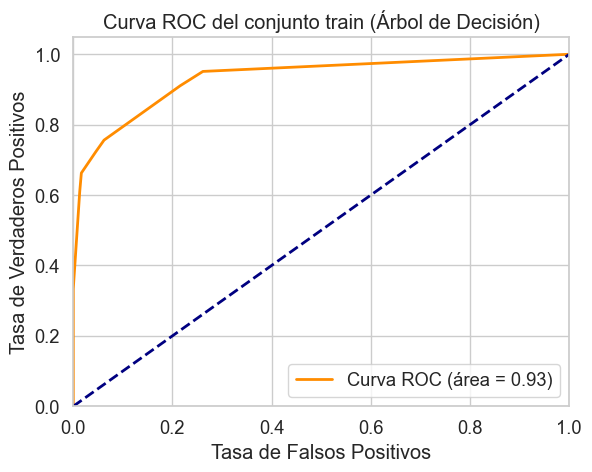

In [55]:
# Graficar la curva ROC para el train (usando el pipeline de árbol de decisión)
fpr, tpr, thresholds = roc_curve(y_train, y_scores_train)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto train (Árbol de Decisión)')
plt.legend(loc="lower right")
plt.show()

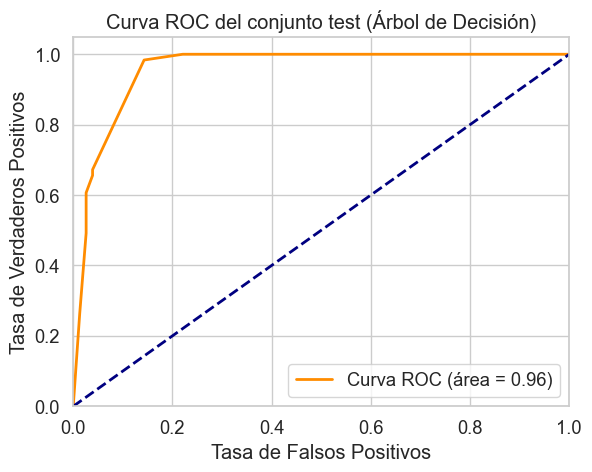

In [56]:
# Graficar la curva ROC para el test (usando el pipeline de árbol de decisión)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto test (Árbol de Decisión)')
plt.legend(loc="lower right")
plt.show()

## **Modelo Random Forest**

**Random Forest** es un algoritmo de aprendizaje supervisado, ampliamente utilizado tanto en problemas de clasificación como de regresión. Fue desarrollado como una extensión de los árboles de decisión para mejorar su precisión y evitar problemas de sobreajuste, mediante la creación de múltiples árboles de decisión y la combinación de sus resultados.

Random Forest es un conjunto (o bosque) de árboles de decisión que, al combinar sus resultados, proporciona una predicción más precisa y estable que un solo árbol. La técnica detrás de Random Forest utiliza el método de “bagging” (Bootstrap Aggregating), donde se entrenan múltiples árboles independientes usando diferentes subconjuntos aleatorios de datos, y sus predicciones se promedian (regresión) o se eligen por voto mayoritario (clasificación).

### **Características del modelo**
* **Modelo de Ensemble:** Utiliza múltiples árboles de decisión que colaboran para la predicción.
* **Aleatorización:** Realiza selección aleatoria tanto de muestras (bootstrap) como de características en cada nodo, lo que contribuye a la reducción del sobreajuste.
* **No requiere normalización de datos:** Puede manejar datos de diferentes escalas sin necesidad de estandarización.
* **Resistencia al sobreajuste:** El uso de múltiples árboles reduce el riesgo de sobreajuste, aunque un número muy alto de árboles puede incrementar el tiempo de cálculo.
* **Adaptable a datos de alta dimensionalidad:** Funciona bien con datos que tienen muchas variables, pero el costo computacional aumenta con el tamaño del bosque.

:::{admonition} **Ventajas de random forest**
:class: note

* **Precisión elevada:** La combinación de predicciones tiende a mejorar la precisión respecto a un único árbol de decisión.
* **Reducción del sobreajuste:** La aleatorización ayuda a que el modelo sea menos sensible al ruido.
* **Adaptabilidad:** Puede usarse tanto para clasificación como para regresión.
* **Robustez frente a valores atípicos y características irrelevantes:** Dado que se considera un subconjunto de características en cada nodo, los efectos de las variables irrelevantes se reducen.
* **Buen rendimiento en datos grandes y complejos:** Su estructura permite manejar eficientemente grandes volúmenes de datos y variables.

:::

:::{admonition} **Desventajas de random forest**
:class: note

* **Tiempo de cálculo elevado:** Entrenar múltiples árboles requiere más recursos computacionales y tiempo que un modelo individual.
* **Complejidad de interpretación:** La interpretabilidad de Random Forest es menor que la de un árbol de decisión único, ya que se combinan múltiples modelos.
* **Propenso a sobreajuste en datasets pequeños:** Aunque en general reduce el sobreajuste, en conjuntos de datos pequeños o muy ruidosos podría sobreajustarse si se configura con muchos árboles.
* **Altos requerimientos de almacenamiento:** La necesidad de guardar múltiples árboles hace que el modelo ocupe más espacio en memoria.

:::

#### **Construcción del modelo de Random Forest**

Los hiperparámetros para **Random Forest** son:

* `n_estimators`
    - **Descripción**: Número de árboles en el bosque.
    - **Tipo**: `int`
    - **Valores posibles**: Valores como `10`, `50`, `100`, `200`, `500` (por defecto es `100`).

* `criterion`
    - **Descripción**: Función para medir la calidad de la división.
    - **Tipo**: `str`
    - **Valores posibles**:
        - `'gini'` (por defecto): usa el índice de Gini.
        - `'entropy'`: usa la entropía de la información.
        - `'log_loss'`: usa la pérdida logarítmica para optimización.

* `max_depth`
    - **Descripción**: Profundidad máxima de cada árbol en el bosque.
    - **Tipo**: `int` o `None`
    - **Valor por defecto**: `None` (crece hasta que todas las hojas son puras o contienen menos muestras que `min_samples_split`).

* `min_samples_split`
    - **Descripción**: Número mínimo de muestras necesarias para dividir un nodo.
    - **Tipo**: `int` o `float`
    - **Valores posibles**: `2` (por defecto) o un porcentaje de muestras si es un `float`.

* `min_samples_leaf`
    - **Descripción**: Número mínimo de muestras requeridas para formar una hoja.
    - **Tipo**: `int` o `float`
    - **Valor por defecto**: `1`

* `min_weight_fraction_leaf`
    - **Descripción**: Fracción mínima de peso de muestras requerida en una hoja.
    - **Tipo**: `float`
    - **Valor por defecto**: `0.0`

* `max_features`
    - **Descripción**: Número de características a considerar al buscar la mejor división.
    - **Tipo**: `int`, `float`, `str` o `None`
    - **Valores posibles**:
        - `None` (por defecto): usa todas las características.
        - `'auto'` o `'sqrt'`: usa la raíz cuadrada del número de características.
        - `'log2'`: usa el logaritmo en base 2 del número de características.

* `max_leaf_nodes`
    - **Descripción**: Número máximo de nodos hoja por árbol.
    - **Tipo**: `int` o `None`
    - **Valor por defecto**: `None`

* `min_impurity_decrease`
    - **Descripción**: Umbral mínimo de reducción de impureza para permitir una división.
    - **Tipo**: `float`
    - **Valor por defecto**: `0.0`

* `bootstrap`
    - **Descripción**: Si usar muestreo con reemplazo.
    - **Tipo**: `bool`
    - **Valor por defecto**: `True`

* `class_weight`
    - **Descripción**: Ponderación de clases.
    - **Tipo**: `dict`, `list of dict` o `str`
    - **Valores posibles**:
        - `None` (por defecto): sin ponderación.
        - `'balanced'`: ajusta automáticamente el peso de las clases.
        - `'balanced_subsample'`: ajusta el peso de cada clase según la frecuencia de clases en cada bootstrap.

* `ccp_alpha`
    - **Descripción**: Parámetro de complejidad para la poda de post-entrenamiento.
    - **Tipo**: `float`
    - **Valor por defecto**: `0.0`

* `max_samples`
    - **Descripción**: Número o fracción máxima de muestras usadas para entrenar cada árbol individual.
    - **Tipo**: `int` o `float`
    - **Valores posibles**: Si `float`, representa un porcentaje del total; si `int`, un número absoluto.


```python
# Diccionario de los parámetros de random forest
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],  # Número de árboles en el bosque
    'criterion': ['gini', 'entropy', 'log_loss'],  # Función para medir la calidad de la división
    'max_depth': [None, 10, 20, 30, 40, 50],  # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5, 10, 20],  # Mínimo número de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4, 10],  # Mínimo número de muestras en una hoja
    'max_features': ['auto', 'sqrt', 'log2', None],  # Características consideradas al buscar la mejor división
    'max_leaf_nodes': [None, 10, 20, 30, 40],  # Número máximo de nodos hoja
    'min_impurity_decrease': [0.0, 0.01, 0.1],  # Umbral para reducir la impureza en una división
    'bootstrap': [True, False],  # Si se usa muestreo con reemplazo
    'class_weight': [None, 'balanced', 'balanced_subsample'],  # Peso de las clases
    'ccp_alpha': [0.0, 0.01, 0.1, 0.2]  # Parámetro de complejidad para la poda
}

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

# =========================================================================
# 2. CONSTRUCCIÓN DEL PIPELINE COMPLETO MEDIANTE MAKE_PIPELINE (RANDOM FOREST)
# =========================================================================
# Nota: Aunque Random Forest no es sensible a las escalas de las variables,
# mantenemos el StandardScaler para asegurar la compatibilidad con el preprocesador global
# y por si deseas comparar modelos bajo el mismo pipeline unificado.
pipeline_rf = make_pipeline(
    preprocesador_global,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    RandomForestClassifier(random_state=42, n_jobs=-1),
)

# Malla de hiperparámetros oficial para Random Forest usando make_pipeline
param_grid = {
    'randomforestclassifier__n_estimators': [100, 200, 500],
    'randomforestclassifier__max_depth': [3, 5, 7, 9],
    'randomforestclassifier__min_samples_split': [2, 5, 8],
    'randomforestclassifier__min_samples_leaf': [1, 4, 7],
    'randomforestclassifier__max_features': ['sqrt', 'log2', None],
    'randomforestclassifier__bootstrap': [True, False],
}

# =========================================================================
# 3. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos la rejilla con la data cruda que ya está en memoria
grid_search_rf.fit(X_train, y_train)

# Extraemos el mejor pipeline ganador completo
mejor_pipeline_rf = grid_search_rf.best_estimator_

# Extraemos la desviación estándar del proceso de CV usando el índice ganador
indice_ganador = grid_search_rf.best_index_
desv_estandar_cv = grid_search_rf.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 4. EVALUACIÓN UTILIZANDO EL PIPELINE EN TRAIN Y TEST (UMBRAL 0.50)
# =========================================================================

# --- Evaluación en el conjunto de Entrenamiento (Train) ---
y_pred_train = mejor_pipeline_rf.predict(X_train)
y_pred_proba_train = mejor_pipeline_rf.predict_proba(X_train)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_pred_proba_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# --- Evaluación en el conjunto de Prueba (Test) ---
y_pred_test = mejor_pipeline_rf.predict(X_test)
y_pred_proba_test = mejor_pipeline_rf.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# =========================================================================
# 5. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n" + "=" * 65)
print(
    "=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (RANDOM FOREST) ==="
)
print("=" * 65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search_rf.best_params_}\n")
print(f"ROC AUC Promedio (Validación Cruzada):  {grid_search_rf.best_score_:.4f}")
print(f"Desviación ROC AUC (Validación Cruzada): ±{desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Train):                        {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Train):          {accuracy_train * 100:.2f}%")
print(f"Recall (Sensibilidad en Train):         {recall_train * 100:.2f}%")
print(f"F1-Score (Métrica F1 en Train):          {f1_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Test):                   {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%")
print(f"Recall Final (Sensibilidad en Test):    {recall_test * 100:.2f}%")
print(f"F1-Score Final (Métrica F1 en Test):     {f1_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(
    classification_report(
        y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']
    )
)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits

=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (RANDOM FOREST) ===
Mejores Hiperparámetros encontrados:
{'randomforestclassifier__bootstrap': False, 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 500}

ROC AUC Promedio (Validación Cruzada):  0.9317
Desviación ROC AUC (Validación Cruzada): ±0.0181

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Train):                        0.9660
Exactitud (Accuracy en Train):          89.67%
Recall (Sensibilidad en Train):         84.15%
F1-Score (Métrica F1 en Train):          87.90%

-----------------------------------------------------------------
RENDIMIENTO EN E

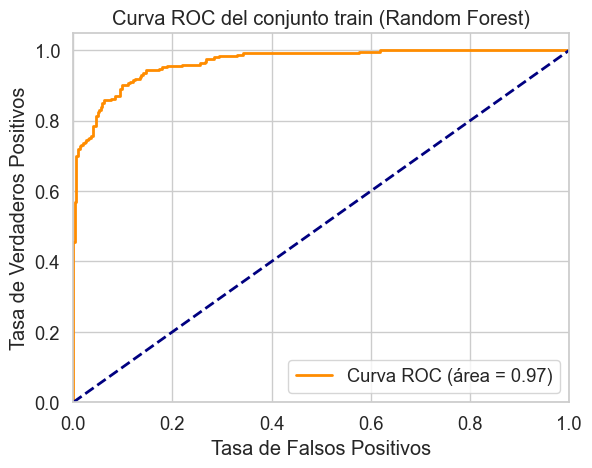

In [58]:
# Graficar la curva ROC para el train (usando el pipeline de Random Forest)
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_train)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto train (Random Forest)')
plt.legend(loc="lower right")
plt.show()

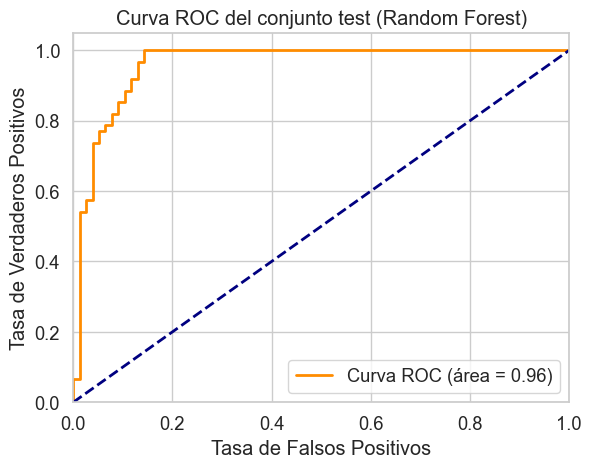

In [59]:
# Graficar la curva ROC para el test (usando el pipeline de Random Forest)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto test (Random Forest)')
plt.legend(loc="lower right")
plt.show()

* Ahora, miremo la importancia de las variables predictoras

In [60]:
# =========================================================================
# EXTRACCIÓN DE IMPORTANCIA DE LAS CARACTERÍSTICAS (FEATURE IMPORTANCE)
# =========================================================================

# 1. Extraer el modelo RandomForest del pipeline ganador
# Usamos 'mejor_pipeline_rf' que fue el objeto que guardó el GridSearchCV
modelo_entrenado = mejor_pipeline_rf.named_steps['randomforestclassifier']

# 2. Extraer los nombres reales de las columnas después del preprocesamiento
# Recuperamos los nombres del ColumnTransformer para que coincidan con el modelo
preprocesador_global_fit = mejor_pipeline_rf.named_steps['columntransformer']
nombres_caracteristicas = preprocesador_global_fit.get_feature_names_out()

# 3. Limpiar los nombres de las columnas para remover los prefijos 'cat__' y 'remainder__'
# Esto hace que el reporte final impreso sea mucho más legible para el negocio
nombres_limpios = [
    nombre.replace('cat__', '').replace('remainder__', '')
    for nombre in nombres_caracteristicas
]

# 4. Construir el DataFrame con la importancia de los predictores
importancia_predictores = pd.DataFrame(
    {'predictor': nombres_limpios, 'importancia': modelo_entrenado.feature_importances_}
).sort_values('importancia', ascending=False)

# 5. Imprimir el reporte comparativo en la consola
print("Importancia de los predictores en el modelo (Random Forest)")
print("-----------------------------------------------------------")
print(importancia_predictores.to_string(index=False))

Importancia de los predictores en el modelo (Random Forest)
-----------------------------------------------------------
        predictor  importancia
  DeudaAnterior_t     0.362749
PuntajeCrediticio     0.155177
       Empleado_t     0.117617
      AniosEmpleo     0.106795
          Ingreso     0.101555
            Deuda     0.055182
             Edad     0.025833
     Educacion_ff     0.017319
      Educacion_x     0.013370
         Casado_y     0.010088
     Educacion_cc     0.006266
      Educacion_q     0.004798
      Ciudadano_p     0.004778
      Educacion_i     0.003398
      Ciudadano_s     0.003262
           Sexo_b     0.003213
      Educacion_k     0.002814
      Educacion_c     0.001915
      Educacion_w     0.001196
      Educacion_d     0.001051
      Educacion_e     0.000674
      Educacion_m     0.000554
      Educacion_j     0.000397


* Miremos la influencia que tiene cada predictor sobre una determinada métrica de evaluación del modelo (estimada por out-of-bag error o validación cruzada) y su gráfica

In [61]:
from sklearn.inspection import permutation_importance
from joblib import cpu_count

# Importancia de los predictores basada en permutación (Random Forest)
# ==============================================================================
importancia = permutation_importance(
                estimator    = mejor_pipeline_rf,
                X            = X_train,
                y            = y_train,
                n_repeats    = 5,
                scoring      = 'roc_auc',
                n_jobs       = cpu_count() - 1,
                random_state = 42
             )

# Se almacenan los resultados (media y desviación) en un dataframe
df_importancia = pd.DataFrame(
                    {k: importancia[k] for k in ['importances_mean', 'importances_std']}
                 )
df_importancia['feature'] = X_train.columns
df_importancia.sort_values('importances_mean', ascending=False)

,importances_mean,importances_std,feature
6,0.157120,0.011872,DeudaAnterior
5,0.015314,0.002526,AniosEmpleo
4,0.014408,0.001059,Educacion
10,0.013183,0.001212,Ingreso
2,0.012939,0.001800,Deuda
8,0.006932,0.001493,PuntajeCrediticio
7,0.006315,0.002549,Empleado
1,0.005162,0.000534,Edad
3,0.003098,0.000256,Casado
9,0.001998,0.000542,Ciudadano


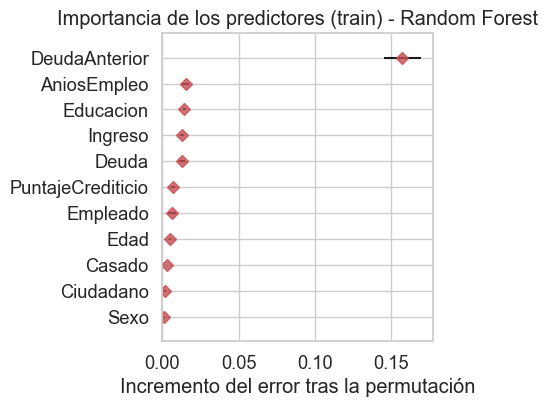

In [62]:
# Gráfico
# ==============================================================================
fig, ax = plt.subplots(figsize=(3.5, 4))
df_importancia = df_importancia.sort_values('importances_mean', ascending=True)
ax.barh(
    df_importancia['feature'],
    df_importancia['importances_mean'],
    xerr=df_importancia['importances_std'],
    align='center',
    alpha=0
)
ax.plot(
    df_importancia['importances_mean'],
    df_importancia['feature'],
    marker="D",
    linestyle="",
    alpha=0.8,
    color="r"
)
ax.set_title('Importancia de los predictores (train) - Random Forest')
ax.set_xlabel('Incremento del error tras la permutación');

La gráfica muestra la importancia de los predictores en un modelo entrenado, medida a través del incremento en el error tras la permutación de cada predictor. Este método evalúa cuánto afecta el desempeño del modelo la aleatorización de cada variable, indicando que los predictores más importantes causan mayores aumentos en el error.

- El predictor **"PriorDefault"** es el único que parece tener un efecto considerable en el error, ya que su barra es notablemente más larga en comparación con el resto.
- Esto sugiere que el modelo depende principalmente de **"PriorDefault"** para hacer predicciones, mientras que las otras variables tienen una importancia mínima o nula en el rendimiento del modelo.
- La concentración de importancia en un solo predictor podría indicar que **"PriorDefault"** es un factor altamente determinante en el contexto de este modelo.

## **Modelo de XGBoost**

**XGBoost (Extreme Gradient Boosting)** es un algoritmo de aprendizaje supervisado basado en árboles de decisión, diseñado para mejorar el rendimiento y la velocidad de los modelos de boosting. Su característica principal es el uso de gradiente boosting optimizado, lo cual permite crear modelos altamente eficientes y precisos, especialmente adecuado para grandes conjuntos de datos.

### **Definición de XGboost**
XGBoost es un algoritmo de boosting basado en el principio de **Gradient Boosting**, donde múltiples árboles se entrenan secuencialmente, y cada nuevo árbol corrige los errores de los árboles anteriores. XGBoost introduce optimizaciones para aumentar la velocidad, reducir el uso de memoria y mejorar la precisión en comparación con otros algoritmos de boosting.

### **Fórmula matemática**
XGBoost minimiza una función de pérdida usando un enfoque de optimización basado en el gradiente. Para cada paso $t$ en el modelo, se ajusta un nuevo árbol $f_t$ para reducir los errores residuales de la predicción anterior. La predicción se actualiza como:

$$
\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i),
$$

donde:
- $\hat{y}_i^{(t)}$ es la predicción para el paso $t$.
- $f_t(x_i)$ es la corrección que el árbol $t$ realiza en la predicción del paso anterior.

La función de pérdida se minimiza mediante la optimización de gradiente, y cada árbol nuevo se entrena para corregir los errores de predicción acumulados de los árboles anteriores.

### **Características del modelo**
* **Boosting por gradiente**: Se enfoca en corregir los errores de los árboles previos, agregando árboles secuencialmente.
* **Regularización**: Incluye términos de regularización $L_1$ y $L_2$ para reducir el sobreajuste.
* **Control de crecimiento de árbol**: Permite el ajuste de parámetros como la profundidad del árbol, número de árboles y tasa de aprendizaje para optimizar el modelo.
* **Computación en paralelo**: Optimizado para ejecutar operaciones en paralelo, mejorando la velocidad de entrenamiento.
* **Manejo eficiente de valores faltantes**: XGBoost puede manejar datos con valores nulos sin necesidad de imputación adicional.

:::{admonition} **Ventajas del XGboost**
:class: note

* **Alta precisión**: La combinación de boosting y regularización produce modelos precisos y efectivos.
* **Reducción de sobreajuste**: El término de regularización ayuda a evitar el sobreajuste, un problema común en otros modelos de boosting.
* **Escalabilidad**: Optimizado para trabajar con grandes volúmenes de datos y con múltiples núcleos, acelerando significativamente el proceso de entrenamiento.
* **Flexibilidad**: Soporta tanto clasificación como regresión, con varias funciones de pérdida ajustables.
* **Capacidad de manejo de datos faltantes**: XGBoost puede hacer inferencias sobre datos faltantes sin pasos adicionales de preprocesamiento.

:::

:::{admonition} **Desventajas del XGboost**
:class: note

* **Requiere ajuste de hiperparámetros**: XGBoost tiene muchos hiperparámetros, y encontrar la configuración óptima puede ser complejo y requerir tiempo.
* **Costoso en términos computacionales**: Aunque está optimizado para velocidad, aún es un modelo computacionalmente costoso, especialmente en comparación con algoritmos como Random Forest.
* **Complejidad de interpretación**: Los modelos de boosting son menos interpretables que los árboles de decisión individuales.
* **Riesgo de sobreajuste en datasets pequeños**: En conjuntos de datos pequeños, la alta capacidad de ajuste puede llevar a un sobreajuste si no se regulan adecuadamente los parámetros.

:::

#### **Construcción del modelo XGboost con sus métricas**

Los hiperparámetros para `XGBoost` son:

* `n_estimators`
    - **Descripción**: Número de árboles de refuerzo en el modelo. Cada árbol se ajusta secuencialmente.
    - **Tipo**: `int`
    - **Valores comunes**: `[50, 100, 200, 500]`

*  `learning_rate`
    - **Descripción**: Tasa de aprendizaje, controla cuánto contribuye cada árbol al modelo final.
    - **Tipo**: `float`
    - **Valores comunes**: `[0.01, 0.05, 0.1, 0.2, 0.3]`

* `max_depth`
    - **Descripción**: Profundidad máxima de cada árbol individual. Controla el sobreajuste.
    - **Tipo**: `int`
    - **Valores comunes**: `[3, 5, 7, 10, 15]`

* `min_child_weight`
    - **Descripción**: Peso mínimo de la suma de instancias en un nodo. Un valor mayor reduce el sobreajuste.
    - **Tipo**: `int`
    - **Valores comunes**: `[1, 3, 5, 10]`

* `subsample`
    - **Descripción**: Fracción de muestras utilizadas para entrenar cada árbol. Valores más bajos reducen el sobreajuste.
    - **Tipo**: `float`
    - **Valores comunes**: `[0.5, 0.7, 0.8, 1.0]`

* `colsample_bytree`
    - **Descripción**: Fracción de características utilizadas para construir cada árbol.
    - **Tipo**: `float`
    - **Valores comunes**: `[0.5, 0.7, 0.8, 1.0]`

* `gamma`
    - **Descripción**: Reducción mínima de pérdida necesaria para realizar una partición en un nodo del árbol.
    - **Tipo**: `float`
    - **Valores comunes**: `[0, 0.1, 0.2, 0.3]`

* `reg_alpha`
    - **Descripción**: Término de regularización L1, que ayuda a hacer la selección de características.
    - **Tipo**: `float`
    - **Valores comunes**: `[0, 0.01, 0.1, 1]`

* `reg_lambda`
    - **Descripción**: Término de regularización L2, ayuda a evitar el sobreajuste.
    - **Tipo**: `float`
    - **Valores comunes**: `[0, 0.01, 0.1, 1]`

* `scale_pos_weight`
    - **Descripción**: Balancea las clases en problemas de clasificación desequilibrados.
    - **Tipo**: `float`
    - **Valores comunes**: `[1, 10, 50, 100]`

* `objective`
    - **Descripción**: Función objetivo a optimizar.
    - **Tipo**: `str`
    - **Valores posibles**:
        - `'binary:logistic'` (por defecto para clasificación binaria)
        - `'multi:softmax'` (para clasificación multiclase)
        - `'multi:softprob'` (para probabilidades multiclase)

```python
# Diccionario de los parámetros de xgboost
param_grid_xgb = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 10, 15],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.5, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0, 0.01, 0.1, 1],
    'scale_pos_weight': [1, 10, 50, 100],
    'objective': ['binary:logistic', 'multi:softmax', 'multi:softprob']
}

```


In [63]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

# =========================================================================
# 2. CONSTRUCCIÓN DEL PIPELINE COMPLETO MEDIANTE MAKE_PIPELINE (XGBOOST)
# =========================================================================
pipeline_xgb = make_pipeline(
    preprocesador_global,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    # Inicializamos XGBClassifier configurando la semilla aleatoria
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
)

# Malla de hiperparámetros oficial para XGBoost usando make_pipeline
param_grid = {
    'xgbclassifier__n_estimators': [100, 300, 500],
    'xgbclassifier__max_depth': [3, 6, 9],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0],
    'xgbclassifier__min_child_weight': [1, 5],
}

# =========================================================================
# 3. BÚSQUEDA EN REJILLA CON VALIDACIÓN CRUZADA (GRID SEARCH CV)
# =========================================================================
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos la rejilla con la data cruda que ya está en memoria
grid_search_xgb.fit(X_train, y_train)

# Extraemos el mejor pipeline ganador completo
mejor_pipeline_xgb = grid_search_xgb.best_estimator_

# Extraemos la desviación estándar del proceso de CV usando el índice ganador
indice_ganador = grid_search_xgb.best_index_
desv_estandar_cv = grid_search_xgb.cv_results_['std_test_score'][indice_ganador]

# =========================================================================
# 4. EVALUACIÓN UTILIZANDO EL PIPELINE EN TRAIN Y TEST (UMBRAL 0.50)
# =========================================================================

# --- Evaluación en el conjunto de Entrenamiento (Train) ---
y_pred_train = mejor_pipeline_xgb.predict(X_train)
y_pred_proba_train = mejor_pipeline_xgb.predict_proba(X_train)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_pred_proba_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# --- Evaluación en el conjunto de Prueba (Test) ---
y_pred_test = mejor_pipeline_xgb.predict(X_test)
y_pred_proba_test = mejor_pipeline_xgb.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# =========================================================================
# 5. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n" + "=" * 65)
print("=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (XGBOOST) ===")
print("=" * 65)
print(f"Mejores Hiperparámetros encontrados:\n{grid_search_xgb.best_params_}\n")
print(f"ROC AUC Promedio (Validación Cruzada):  {grid_search_xgb.best_score_:.4f}")
print(f"Desviación ROC AUC (Validación Cruzada): ±{desv_estandar_cv:.4f}\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("-" * 65)
print(f"ROC AUC (Train):                        {roc_auc_train:.4f}")
print(f"Exactitud (Accuracy en Train):          {accuracy_train * 100:.2f}%")
print(f"Recall (Sensibilidad en Train):         {recall_train * 100:.2f}%")
print(f"F1-Score (Métrica F1 en Train):          {f1_train * 100:.2f}%\n")

print("-" * 65)
print("RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)")
print("-" * 65)
print(f"ROC AUC Final (Test):                   {roc_auc_test:.4f}")
print(f"Exactitud Final (Accuracy en Test):     {accuracy_test * 100:.2f}%")
print(f"Recall Final (Sensibilidad en Test):    {recall_test * 100:.2f}%")
print(f"F1-Score Final (Métrica F1 en Test):     {f1_test * 100:.2f}%\n")

print("--- MATRIZ DE CONFUSIÓN (TRAIN) ---")
print(confusion_matrix(y_train, y_pred_train))

print("\n--- MATRIZ DE CONFUSIÓN DE REFERENCIA (TEST - UMBRAL 0.50) ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ---")
print(
    classification_report(
        y_test, y_pred_test, target_names=['Rechazado (-)', 'Aprobado (+)']
    )
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

=== REPORTE DEL PIPELINE COMPLETO DE CLASIFICACIÓN (XGBOOST) ===
Mejores Hiperparámetros encontrados:
{'xgbclassifier__colsample_bytree': 1.0, 'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__min_child_weight': 5, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__subsample': 0.8}

ROC AUC Promedio (Validación Cruzada):  0.9338
Desviación ROC AUC (Validación Cruzada): ±0.0241

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE ENTRENAMIENTO (TRAIN)
-----------------------------------------------------------------
ROC AUC (Train):                        0.9563
Exactitud (Accuracy en Train):          88.04%
Recall (Sensibilidad en Train):         84.96%
F1-Score (Métrica F1 en Train):          86.36%

-----------------------------------------------------------------
RENDIMIENTO EN EL CONJUNTO DE PRUEBA (TEST)
----------------------------------

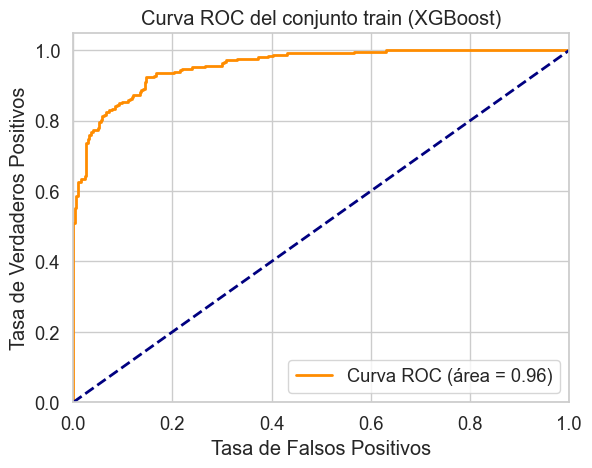

In [64]:
# Graficar la curva ROC para el train (usando el pipeline de XGBoost)
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_train)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto train (XGBoost)')
plt.legend(loc="lower right")
plt.show()

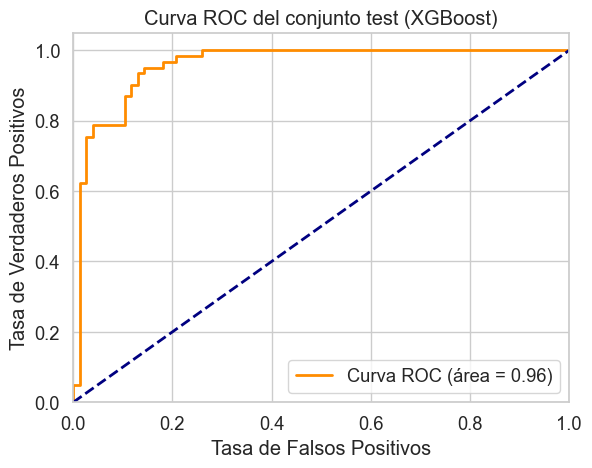

In [65]:
# Graficar la curva ROC para el test (usando el pipeline de XGBoost)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del conjunto test (XGBoost)')
plt.legend(loc="lower right")
plt.show()

* Ahora, miremos las variables predictoras más relevantes

In [67]:
# =========================================================================
# EXTRACCIÓN DE IMPORTANCIA DE LAS CARACTERÍSTICAS (FEATURE IMPORTANCE - XGBOOST)
# =========================================================================

# 1. Extraer el modelo XGBoost del pipeline ganador
# Usamos 'mejor_pipeline_xgb' que fue el objeto guardado por el GridSearchCV
modelo_entrenado_xgb = mejor_pipeline_xgb.named_steps['xgbclassifier']

# 2. Extraer los nombres reales de las columnas después del preprocesamiento
preprocesador_global_fit = mejor_pipeline_xgb.named_steps['columntransformer']
nombres_caracteristicas = preprocesador_global_fit.get_feature_names_out()

# 3. Limpiar los nombres de las columnas removiendo los prefijos 'cat__' y 'remainder__'
nombres_limpios = [
    nombre.replace('cat__', '').replace('remainder__', '')
    for nombre in nombres_caracteristicas
]

# 4. Construir el DataFrame con la importancia de los predictores
importancia_predictores_xgb = pd.DataFrame(
    {'predictor': nombres_limpios, 'importancia': modelo_entrenado_xgb.feature_importances_}
).sort_values('importancia', ascending=False)

# 5. Imprimir el reporte comparativo en la consola
print("Importancia de los predictores en el modelo (XGBoost)")
print("-----------------------------------------------------")
print(importancia_predictores_xgb.to_string(index=False))

Importancia de los predictores en el modelo (XGBoost)
-----------------------------------------------------
        predictor  importancia
  DeudaAnterior_t     0.536765
       Empleado_t     0.148925
          Ingreso     0.064983
PuntajeCrediticio     0.056795
         Casado_y     0.045453
            Deuda     0.038800
      AniosEmpleo     0.030046
             Edad     0.023551
           Sexo_b     0.023188
      Educacion_c     0.019043
      Educacion_q     0.012451
      Educacion_k     0.000000
      Educacion_m     0.000000
      Educacion_j     0.000000
      Educacion_w     0.000000
      Educacion_x     0.000000
      Educacion_i     0.000000
     Educacion_ff     0.000000
      Ciudadano_p     0.000000
      Ciudadano_s     0.000000
      Educacion_e     0.000000
      Educacion_d     0.000000
     Educacion_cc     0.000000


In [68]:
from sklearn.inspection import permutation_importance
from joblib import cpu_count

# Importancia de los predictores basada en permutación (XGBoost)
# ==============================================================================
importancia = permutation_importance(
                estimator    = mejor_pipeline_xgb,
                X            = X_train,
                y            = y_train,
                n_repeats    = 5,
                scoring      = 'roc_auc',
                n_jobs       = cpu_count() - 1,
                random_state = 123
             )

# Se almacenan los resultados (media y desviación) en un dataframe
df_importancia = pd.DataFrame(
                    {k: importancia[k] for k in ['importances_mean', 'importances_std']}
                 )
df_importancia['feature'] = X_train.columns
df_importancia.sort_values('importances_mean', ascending=False)

,importances_mean,importances_std,feature
6,0.282639,0.014128,DeudaAnterior
10,0.024010,0.003818,Ingreso
2,0.023977,0.003146,Deuda
5,0.012785,0.004358,AniosEmpleo
7,0.012665,0.001683,Empleado
1,0.005649,0.000345,Edad
3,0.002539,0.000315,Casado
8,0.001752,0.000597,PuntajeCrediticio
4,0.000436,0.000114,Educacion
0,0.000043,0.000105,Sexo


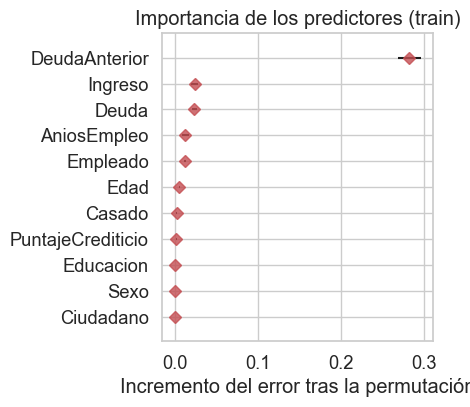

In [69]:
# Gráfico de la importancia de cada predictor
# ==============================================================================
fig, ax = plt.subplots(figsize=(3.5, 4))
df_importancia = df_importancia.sort_values('importances_mean', ascending=True)
ax.barh(
    df_importancia['feature'],
    df_importancia['importances_mean'],
    xerr=df_importancia['importances_std'],
    align='center',
    alpha=0
)
ax.plot(
    df_importancia['importances_mean'],
    df_importancia['feature'],
    marker="D",
    linestyle="",
    alpha=0.8,
    color="r"
)
ax.set_title('Importancia de los predictores (train)')
ax.set_xlabel('Incremento del error tras la permutación');

## **Comparación de los modelos**

En esta sección se realizará un análisis completo para escoger el mejor modelo.

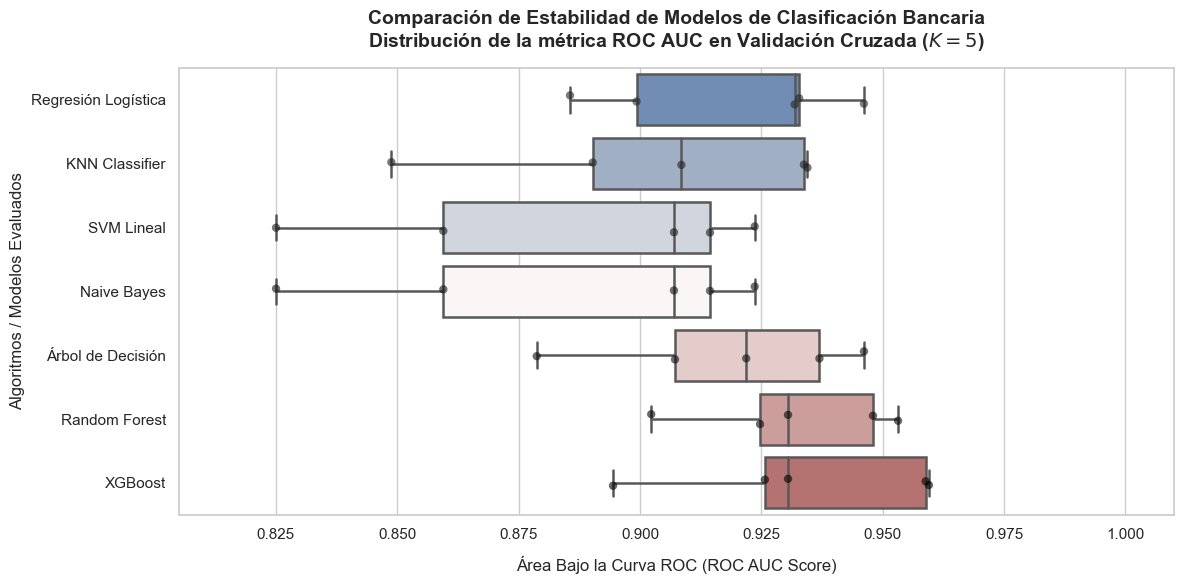

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# =========================================================================
# 1. RECOLECCIÓN DE LOS SCORES DE ROC AUC DE VALIDACIÓN CRUZADA (5 FOLDS)
# =========================================================================
# Extraemos los 5 scores de cada GridSearch usando el índice ganador (.best_index_)

# 1. Regresión Logística
idx_lr = grid_search_lr.best_index_
f_lr = [
    grid_search_lr.cv_results_[f'split{i}_test_score'][idx_lr] for i in range(5)
]

# 2. K-Nearest Neighbors (KNN)
# Nota: Si tu GridSearch de KNN se llamó 'grid_search' cámbialo aquí, asumimos el del bloque KNN
idx_knn = grid_search_knn.best_index_  # Ajustar a la variable de tu rejilla KNN si cambió
f_knn = [
    grid_search_knn.cv_results_[f'split{i}_test_score'][idx_knn] for i in range(5)
]

# 3. SVM Lineal (LinearSVC)
idx_svc = grid_search_kl.best_index_
f_svc = [
    grid_search_kl.cv_results_[f'split{i}_test_score'][idx_svc] for i in range(5)
]

# 4. Naive Bayes (GaussianNB)
idx_nb = grid_search_nb.best_index_
f_nb = [
    grid_search_nb.cv_results_[f'split{i}_test_score'][idx_nb] for i in range(5)
]

# 5. Árbol de Decisión
idx_dt = grid_search_dt.best_index_
f_dt = [
    grid_search_dt.cv_results_[f'split{i}_test_score'][idx_dt] for i in range(5)
]

# 6. Random Forest
idx_rf = grid_search_rf.best_index_
f_rf = [
    grid_search_rf.cv_results_[f'split{i}_test_score'][idx_rf] for i in range(5)
]

# 7. XGBoost
idx_xgb = grid_search_xgb.best_index_
f_xgb = [
    grid_search_xgb.cv_results_[f'split{i}_test_score'][idx_xgb] for i in range(5)
]

# =========================================================================
# 2. CONSTRUCCIÓN DEL DATAFRAME PARA SEABORN
# =========================================================================
data_grafico = {
    'Regresión Logística': f_lr,
    'KNN Classifier': f_knn,
    'SVM Lineal': f_svc,
    'Naive Bayes': f_nb,
    'Árbol de Decisión': f_dt,
    'Random Forest': f_rf,
    'XGBoost': f_xgb,
}

df_boxplot = pd.DataFrame(data_grafico)

# =========================================================================
# 3. DISEÑO Y RENDERIZADO DEL DIAGRAMA DE CAJAS
# =========================================================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Graficamos horizontalmente. Usamos una paleta secuencial/divergente atractiva
ax = sns.boxplot(
    data=df_boxplot,
    orient="h",
    palette="vlag",
    linewidth=1.8,
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6},
)

# Añadimos los puntos (stripplot) para ver el comportamiento de los 5 pliegues
sns.stripplot(
    data=df_boxplot, orient="h", color="black", alpha=0.6, size=6, jitter=0.08
)

# Títulos y formato del gráfico para clasificación
plt.title(
    'Comparación de Estabilidad de Modelos de Clasificación Bancaria\nDistribución de la métrica ROC AUC en Validación Cruzada ($K=5$)',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Área Bajo la Curva ROC (ROC AUC Score)', fontsize=12, labelpad=10)
plt.ylabel('Algoritmos / Modelos Evaluados', fontsize=12)

# Fijamos límites lógicos en el eje X para apreciar mejor las diferencias entre modelos
min_auc = df_boxplot.min().min() - 0.02
plt.xlim([max(0.0, min_auc), 1.01])

plt.tight_layout()
plt.show()

## **Obtención del mejor umbral para el modelo**

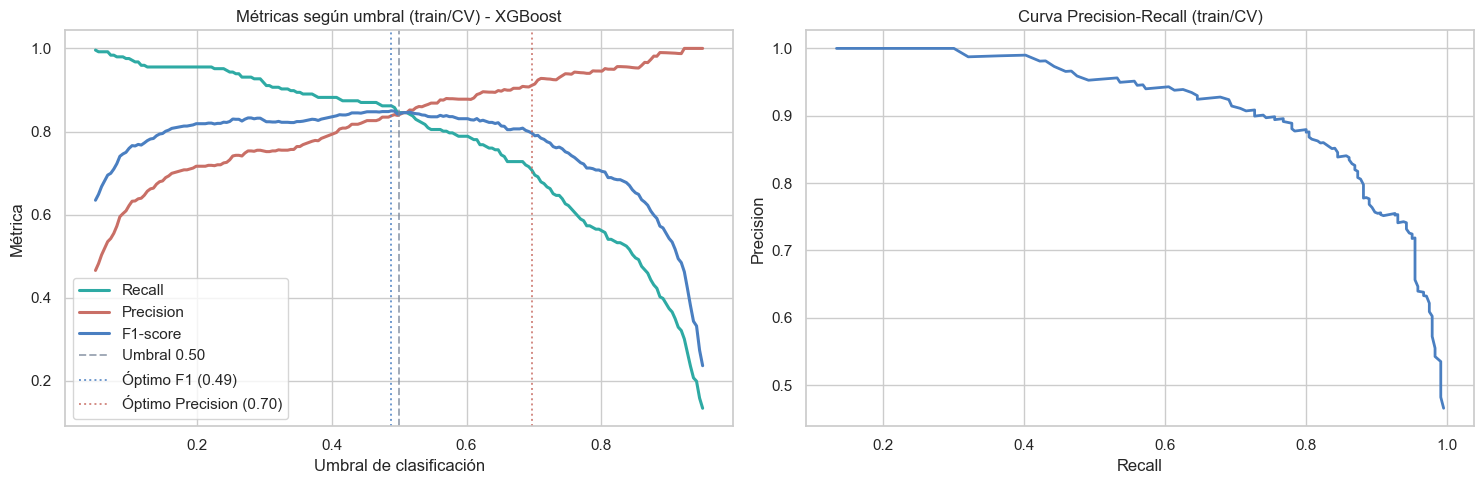

Umbral por defecto:                                  0.5000
Umbral óptimo (máx F1):                               0.4887
Umbral óptimo (máx Precision, Recall >= 0.70):     0.6967

Umbral final adoptado: 0.6967

Reporte de clasificación con umbral final (TEST):

               precision    recall  f1-score   support

Rechazado (-)       0.79      0.97      0.87        77
 Aprobado (+)       0.95      0.67      0.79        61

     accuracy                           0.84       138
    macro avg       0.87      0.82      0.83       138
 weighted avg       0.86      0.84      0.84       138

[[75  2]
 [20 41]]


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

# =========================================================================
# 1. PROBABILIDADES OOF SOBRE TRAIN (el modelo ya fue elegido por roc_auc
#    dentro de grid_search_xgb; aquí solo generamos scores honestos para
#    decidir el umbral, sin tocar test)
# =========================================================================
y_score_best = cross_val_predict(
    mejor_pipeline_xgb, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

# =========================================================================
# 2. RANGO DE UMBRALES A EVALUAR (igual que en el proyecto de referencia)
# =========================================================================
thresholds = np.linspace(0.05, 0.95, 200)

recalls, precisions, f1s = [], [], []
for thr in thresholds:
    y_pred_thr = (y_score_best >= thr).astype(int)
    recalls.append(recall_score(y_train, y_pred_thr, zero_division=0))
    precisions.append(precision_score(y_train, y_pred_thr, zero_division=0))
    f1s.append(f1_score(y_train, y_pred_thr, zero_division=0))

recalls = np.array(recalls)
precisions = np.array(precisions)
f1s = np.array(f1s)

# =========================================================================
# 3. TRES PUNTOS DE REFERENCIA (adaptados a un contexto de crédito)
# =========================================================================
thr_default = 0.50
thr_opt_f1 = thresholds[np.argmax(f1s)]

# En lugar de "maximizar recall con piso de precisión" (prioridad clínica),
# en crédito interesa lo contrario: maximizar PRECISION en "Aprobado"
# manteniendo un recall mínimo aceptable, para no aprobar clientes que
# luego caen en default. Ajusta este piso según tu tolerancia de riesgo.
recall_minimo = 0.70
mask_recall_ok = recalls >= recall_minimo
if mask_recall_ok.any():
    thr_opt_precision = thresholds[mask_recall_ok][np.argmax(precisions[mask_recall_ok])]
else:
    thr_opt_precision = thresholds[np.argmax(recalls)]

# =========================================================================
# 4. GRÁFICO (mismo estilo que el proyecto de referencia)
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresholds, recalls, label="Recall", color="#2EAAA4", linewidth=2.2)
axes[0].plot(thresholds, precisions, label="Precision", color="#C96F66", linewidth=2.2)
axes[0].plot(thresholds, f1s, label="F1-score", color="#4A7FC1", linewidth=2.2)
axes[0].axvline(thr_default, color="#7A869A", linestyle="--", linewidth=1.4, alpha=0.7, label="Umbral 0.50")
axes[0].axvline(thr_opt_f1, color="#4A7FC1", linestyle=":", linewidth=1.4, alpha=0.8, label=f"Óptimo F1 ({thr_opt_f1:.2f})")
axes[0].axvline(thr_opt_precision, color="#C96F66", linestyle=":", linewidth=1.4, alpha=0.8, label=f"Óptimo Precision ({thr_opt_precision:.2f})")
axes[0].set_xlabel("Umbral de clasificación")
axes[0].set_ylabel("Métrica")
axes[0].set_title("Métricas según umbral (train/CV) - XGBoost")
axes[0].legend()

axes[1].plot(recalls, precisions, color="#4A7FC1", linewidth=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall (train/CV)")

plt.tight_layout()
plt.show()

print(f"Umbral por defecto:                                  {thr_default:.4f}")
print(f"Umbral óptimo (máx F1):                               {thr_opt_f1:.4f}")
print(f"Umbral óptimo (máx Precision, Recall >= {recall_minimo:.2f}):     {thr_opt_precision:.4f}")

# =========================================================================
# 5. UMBRAL FINAL ADOPTADO Y EVALUACIÓN EN TEST
# =========================================================================
FINAL_THRESHOLD = thr_opt_precision  # o thr_opt_f1, según el criterio que prefieras justificar

y_pred_proba_xgb_test = mejor_pipeline_xgb.predict_proba(X_test)[:, 1]
y_pred_final_threshold = (y_pred_proba_xgb_test >= FINAL_THRESHOLD).astype(int)

print(f"\nUmbral final adoptado: {FINAL_THRESHOLD:.4f}")
print("\nReporte de clasificación con umbral final (TEST):\n")
print(
    classification_report(
        y_test, y_pred_final_threshold, target_names=["Rechazado (-)", "Aprobado (+)"]
    )
)
print(confusion_matrix(y_test, y_pred_final_threshold))

- Enlace de un modelo de clasificación

https://danielahernav2006.github.io/diabetes-dash-final/